In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore", category=Warning)

import sys
sys.path.append(f"./../")

from qiskit import transpile
from qiskit.quantum_info import Operator
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from src.core import MultiEdgeGraph, MatchingDecomposition, PauliDecomposition
from src.utils import get_exact_evolution_operator

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [3]:
# Global storage for gate count data
gate_count_data = []


def analyze_and_plot(edges, title, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    Compares matching-based and Pauli decomposition methods.

    Args:
        edges: Graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)

    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    n_steps_list = [1, 2, 5, 10, 20, 50, 100]

    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")

    # Create graph
    G = MultiEdgeGraph(edges)
    print(f"Number of qubits: {G.n_qubits}")

    # Display graph
    print("\nGraph:")
    try:
        display(G.draw())
    except:
        print("(Graph display not available)")

    # Create decomposition objects (now accept MultiEdgeGraph)
    matching_decomp = MatchingDecomposition(G)
    pauli_decomp = PauliDecomposition(G)

    print(f"\nMatchings: {matching_decomp.num_matchings()}")
    print(f"Matchings: {matching_decomp.get_matchings()}")

    print(f"Number of qubits: {G.n_qubits}")

    # Hamming cost analysis
    print(f"\nHamming Cost Analysis:")
    print(f"Total = {G.hamming_cost()}, Edges = {G.n_edges}, Per Edge = {G.avg_hamming_cost():.3f}")

    # Display sample circuits (with n_steps=1)
    sample_qc_matching = matching_decomp.build_circuit(1, delta_t)
    print("\nSample Circuit - Matching (n_steps=1):")
    try:
        display(sample_qc_matching.draw('mpl'))
    except:
        print(sample_qc_matching.draw('text'))

    # Get exact evolution operator
    exact_operator = get_exact_evolution_operator(delta_t, G.hamiltonian)

    # Storage for results
    matching_vs_exact_errors = []
    pauli_vs_exact_errors = []

    matching_cx_no_opt = []
    matching_cx_opt = []
    matching_u3_no_opt = []
    matching_u3_opt = []
    pauli_cx_no_opt = []
    pauli_cx_opt = []
    pauli_u3_no_opt = []
    pauli_u3_opt = []

    # Analyze each n_steps
    for n_steps in n_steps_list:
        # Build matching circuit using class
        matching_qc = matching_decomp.build_circuit(n_steps, delta_t)
        transpiled_matching_no_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_matching_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_operator = Operator(transpiled_matching_opt)

        matching_counts_no_opt = transpiled_matching_no_opt.count_ops()
        matching_counts_opt = transpiled_matching_opt.count_ops()

        matching_cx_no_opt.append(matching_counts_no_opt.get('cx', 0))
        matching_cx_opt.append(matching_counts_opt.get('cx', 0))
        matching_u3_no_opt.append(matching_counts_no_opt.get('u3', 0))
        matching_u3_opt.append(matching_counts_opt.get('u3', 0))

        # Build Pauli circuit using class
        pauli_qc = pauli_decomp.build_circuit(n_steps, delta_t)
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        # Extract operator BEFORE transpilation to show proper Trotter convergence
        pauli_operator = Operator(pauli_qc)

        pauli_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_counts_opt = transpiled_pauli_opt.count_ops()

        pauli_cx_no_opt.append(pauli_counts_no_opt.get('cx', 0))
        pauli_cx_opt.append(pauli_counts_opt.get('cx', 0))
        pauli_u3_no_opt.append(pauli_counts_no_opt.get('u3', 0))
        pauli_u3_opt.append(pauli_counts_opt.get('u3', 0))

        # Store gate count data
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_cx_no_opt[-1],
                'U3_gates': matching_u3_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_cx_opt[-1],
                'U3_gates': matching_u3_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': pauli_cx_no_opt[-1],
                'U3_gates': pauli_u3_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': pauli_cx_opt[-1],
                'U3_gates': pauli_u3_opt[-1]
            }
        ])

        # Calculate errors
        matching_vs_exact = np.linalg.norm(matching_operator - exact_operator, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator, ord=2)

        matching_vs_exact_errors.append(matching_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)

    # Print gate count summary
    print(f"\nGate Count Summary (U3/CX) for {title}:")
    print("="*110)

    # Create DataFrame for clean table display
    table_data = []
    for i, n_steps in enumerate(n_steps_list):
        table_data.append({
            "n_steps": n_steps,
            "Match (No Opt)": f"{matching_u3_no_opt[i]}/{matching_cx_no_opt[i]}",
            "Match (Opt)": f"{matching_u3_opt[i]}/{matching_cx_opt[i]}",
            "Pauli (No Opt)": f"{pauli_u3_no_opt[i]}/{pauli_cx_no_opt[i]}",
            "Pauli (Opt)": f"{pauli_u3_opt[i]}/{pauli_cx_opt[i]}"
        })

    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))

    print(f"\nHamming cost/edge: {G.avg_hamming_cost():.3f}")
    print("="*110)

    # Create error plot
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.loglog(n_steps_list, matching_vs_exact_errors, 'o-',
              label='Matching', linewidth=2.5, markersize=8,
              color='#1f77b4', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#1f77b4')
    ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-',
              label='Pauli', linewidth=2.5, markersize=8,
              color='#d62728', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#d62728')

    ax.set_xlabel('Number of Trotter steps', fontsize=14)
    ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)

    plot_title = title.split(":")[1].strip() if ":" in title else title
    ax.set_title(plot_title, fontsize=16, pad=20)

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Move legend outside the plot (below)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=True,
              fancybox=True, shadow=True, ncol=2)

    plt.tight_layout()

    # Save plot
    filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
        "(", "").replace(")", "").replace("-", "_")
    filename_base = "_".join([part for part in filename_base.split("_") if part])
    filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Error plot saved as: {filename}")

    plt.show()


def create_gate_count_summary_table():
    """Create comprehensive summary table of all gate counts."""
    global gate_count_data

    if not gate_count_data:
        print("No gate count data available.")
        return

    df = pd.DataFrame(gate_count_data)

    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)

    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]

        for method in ['Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX) | Optimized (U3/CX) | CX Reduction (%)")
                print("-" * 75)

                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) &
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) &
                                    (method_data['Optimization'] == 'Yes')]

                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]

                        reduction = (100 * (1 - opt_row['CX_gates'] /
                                           no_opt_row['CX_gates'])
                                    if no_opt_row['CX_gates'] > 0 else 0)

                        print(f"{n_steps:7d} | {no_opt_row['U3_gates']:3d}/{no_opt_row['CX_gates']:3d}       | "
                              f"{opt_row['U3_gates']:3d}/{opt_row['CX_gates']:3d}            | {reduction:16.1f}")

        print("-" * 80)


Cycle Graph C4
Original edges: {('00', '01'), ('10', '11'), ('01', '11'), ('00', '10')}
Number of qubits: 2

Graph:


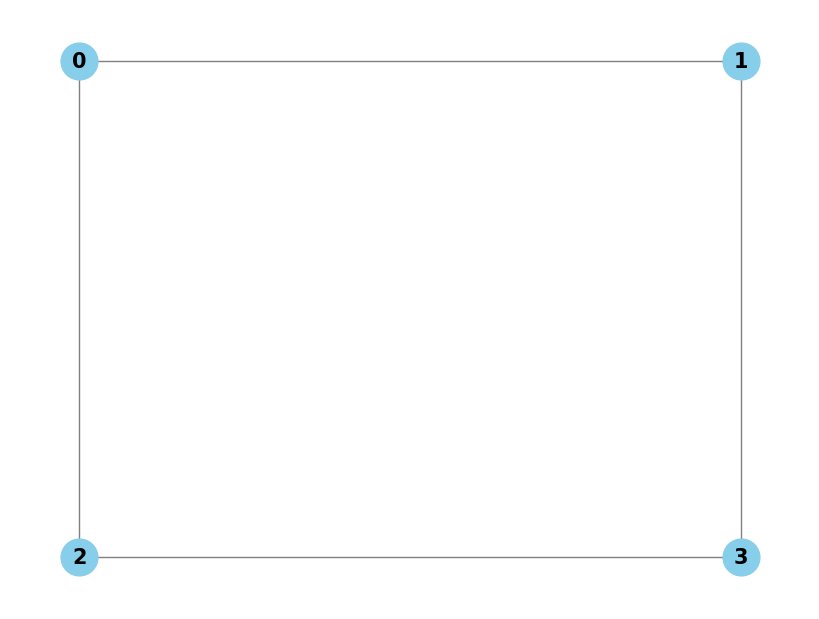

None


Matchings: 2
Matchings: [{('00', '01'), ('10', '11')}, {('01', '11'), ('00', '10')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 4, Per Edge = 1.000

Sample Circuit - Matching (n_steps=1):


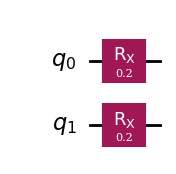


Gate Count Summary (U3/CX) for Cycle Graph C4:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            2/0         2/0            2/0         2/0
       2            4/0         2/0            4/0         2/0
       5           10/0         2/0           10/0         2/0
      10           20/0         2/0           20/0         2/0
      20           40/0         2/0           40/0         2/0
      50          100/0         2/0          100/0         2/0
     100          200/0         2/0          200/0         2/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cycle_graph_c4_error_analysis.pdf


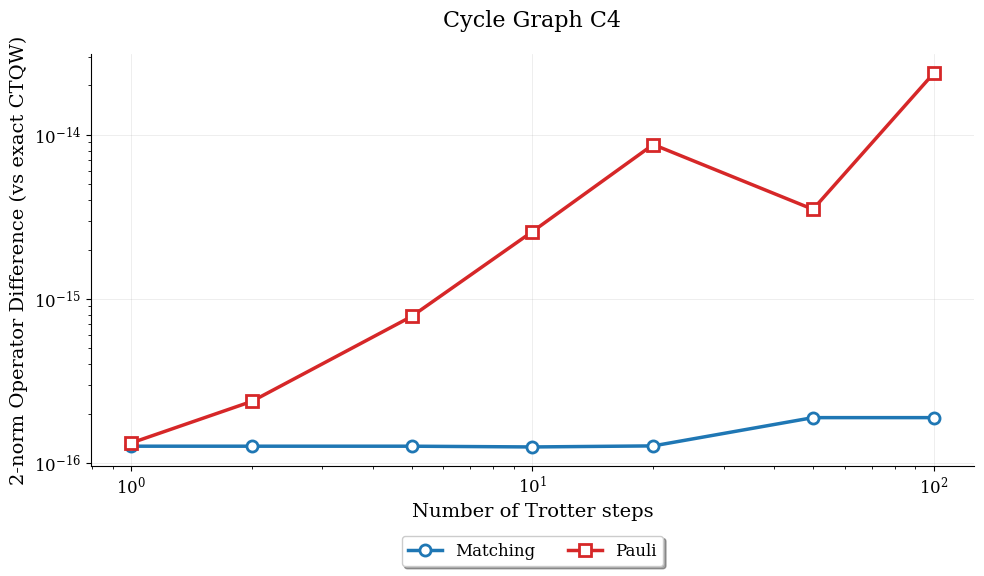

In [4]:
edges = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
analyze_and_plot(edges, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '10'), ('00', '11'), ('00', '01'), ('00', '10'), ('01', '11')}
Number of qubits: 2

Graph:


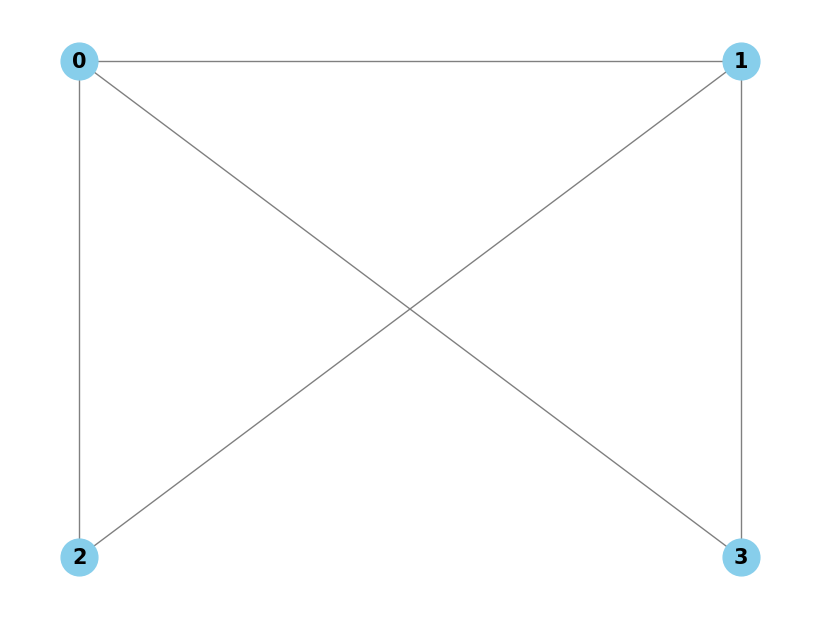

None


Matchings: 3
Matchings: [{('01', '10'), ('00', '11')}, {('00', '01')}, {('01', '11'), ('00', '10')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 7, Edges = 5, Per Edge = 1.400

Sample Circuit - Matching (n_steps=1):


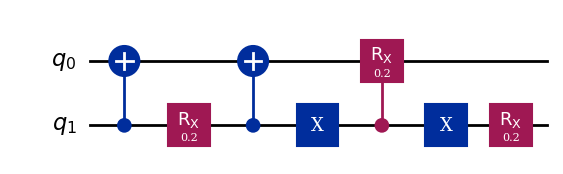


Gate Count Summary (U3/CX) for Complete Graph K4 - C2:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            7/4         6/2           10/4         6/2
       2           14/8         6/2           20/8         6/2
       5          35/20         6/2          50/20         6/2
      10          70/40         6/2         100/40         6/2
      20         140/80         6/2         200/80         6/2
      50        350/200         6/2        500/200         6/2
     100        700/400         6/2       1000/400         6/2

Hamming cost/edge: 1.400
Error plot saved as: trotterization_plots/complete_graph_k4_c2_error_analysis.pdf


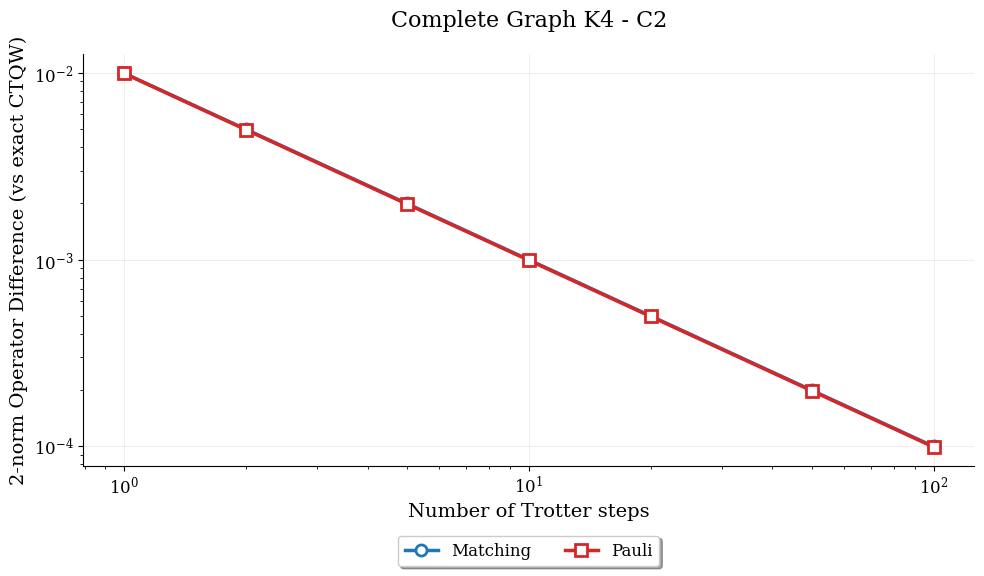

In [5]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
analyze_and_plot(edges, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('01', '10'), ('00', '01'), ('10', '11')}
Number of qubits: 2

Graph:


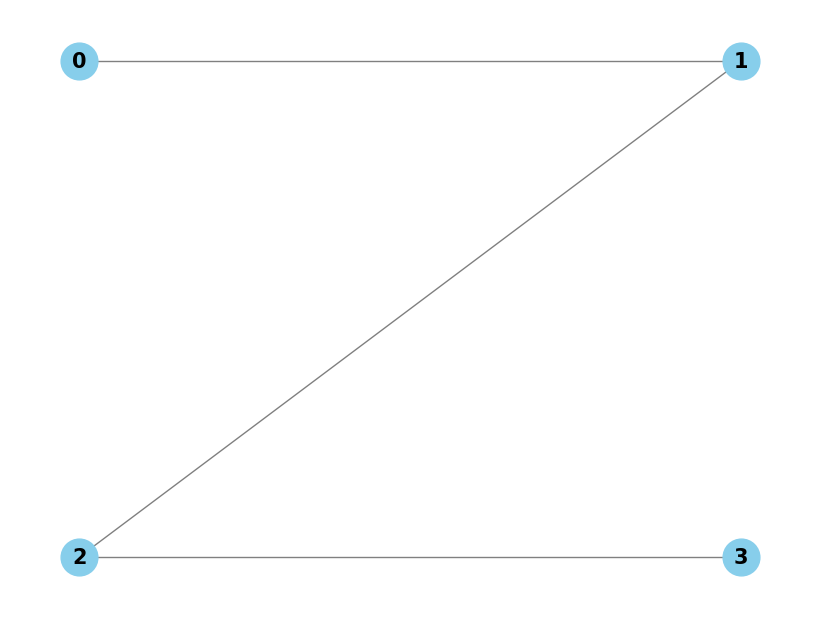

None


Matchings: 2
Matchings: [{('01', '10')}, {('00', '01'), ('10', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 3, Per Edge = 1.333

Sample Circuit - Matching (n_steps=1):


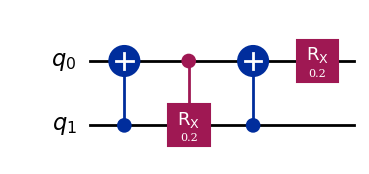


Gate Count Summary (U3/CX) for Path Graph P3:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            4/4         6/2           11/4         6/2
       2            8/8         6/2           22/8         6/2
       5          20/20         6/2          55/20         6/2
      10          40/40         6/2         110/40         6/2
      20          80/80         6/2         220/80         6/2
      50        200/200         6/2        550/200         6/2
     100        400/400         6/2       1100/400         6/2

Hamming cost/edge: 1.333
Error plot saved as: trotterization_plots/path_graph_p3_error_analysis.pdf


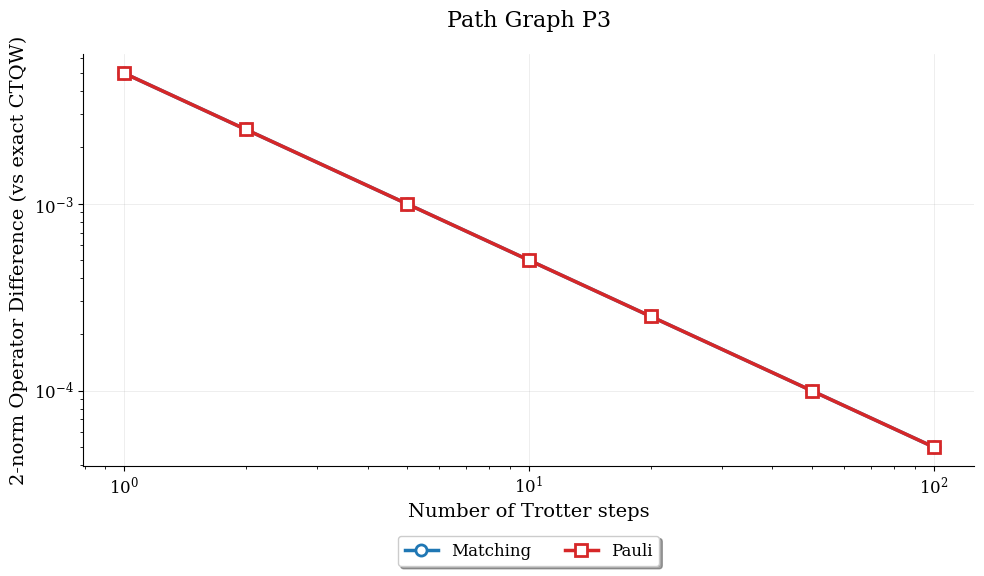

In [6]:
edges = {('00', '01'), ('01', '10'), ('10', '11')}
analyze_and_plot(edges, "Path Graph P3")


Tree Graph (2 qubits)
Original edges: {('00', '11'), ('00', '01'), ('00', '10')}
Number of qubits: 2

Graph:


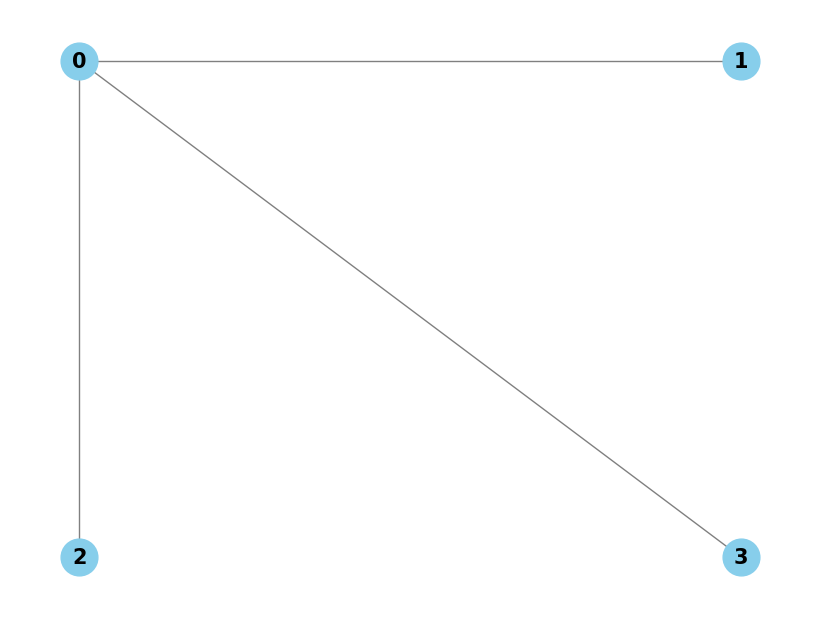

None


Matchings: 3
Matchings: [{('00', '11')}, {('00', '01')}, {('00', '10')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 3, Per Edge = 1.333

Sample Circuit - Matching (n_steps=1):


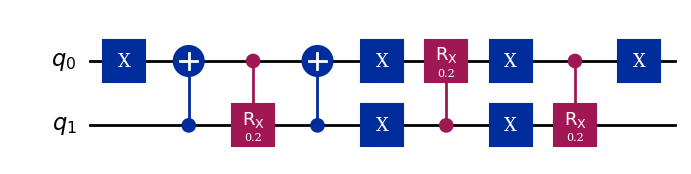


Gate Count Summary (U3/CX) for Tree Graph (2 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1           15/8         8/3           18/8         8/3
       2          30/16         8/3          36/16         8/3
       5          75/40         8/3          90/40         8/3
      10         150/80         8/3         180/80         8/3
      20        300/160         8/3        360/160         8/3
      50        750/400         8/3        900/400         8/3
     100       1500/800         8/3       1800/800         8/3

Hamming cost/edge: 1.333
Error plot saved as: trotterization_plots/tree_graph_2_qubits_error_analysis.pdf


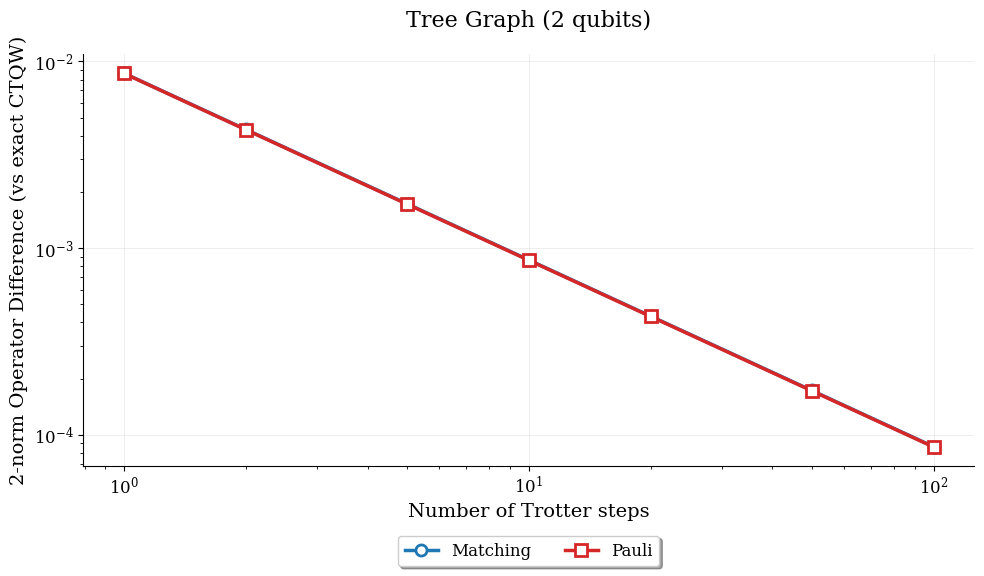

In [7]:
edges = {('00','01'), ('00','10'), ('00','11')}
analyze_and_plot(edges, "Tree Graph (2 qubits)")


Tree Graph (3 qubits)
Original edges: {('000', '110'), ('000', '101'), ('000', '001'), ('000', '011'), ('000', '010'), ('000', '100'), ('000', '111')}
Number of qubits: 3

Graph:


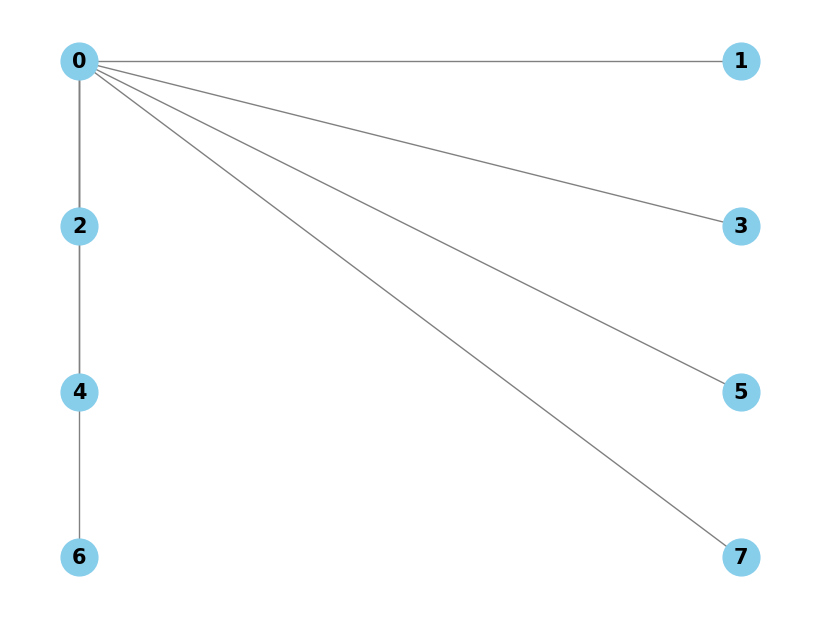

None


Matchings: 7
Matchings: [{('000', '110')}, {('000', '101')}, {('000', '011')}, {('000', '111')}, {('000', '001')}, {('000', '010')}, {('000', '100')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 12, Edges = 7, Per Edge = 1.714

Sample Circuit - Matching (n_steps=1):


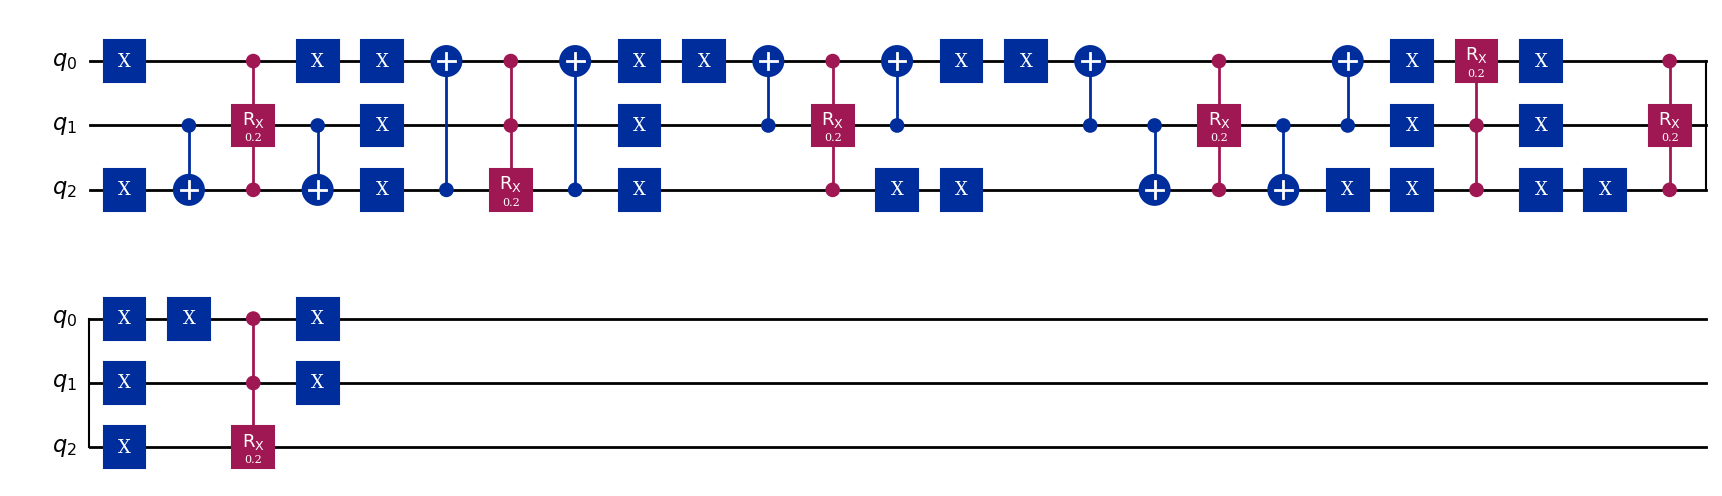


Gate Count Summary (U3/CX) for Tree Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         133/66       64/61         118/76       55/30
       2        266/132     124/122        236/152      109/60
       5        665/330     304/305        590/380     271/150
      10       1330/660     604/610       1180/760     541/300
      20      2660/1320   1204/1220      2360/1520    1081/600
      50      6650/3300   3004/3050      5900/3800   2651/1500
     100     13300/6600   6004/6100     11800/7600   5401/3000

Hamming cost/edge: 1.714
Error plot saved as: trotterization_plots/tree_graph_3_qubits_error_analysis.pdf


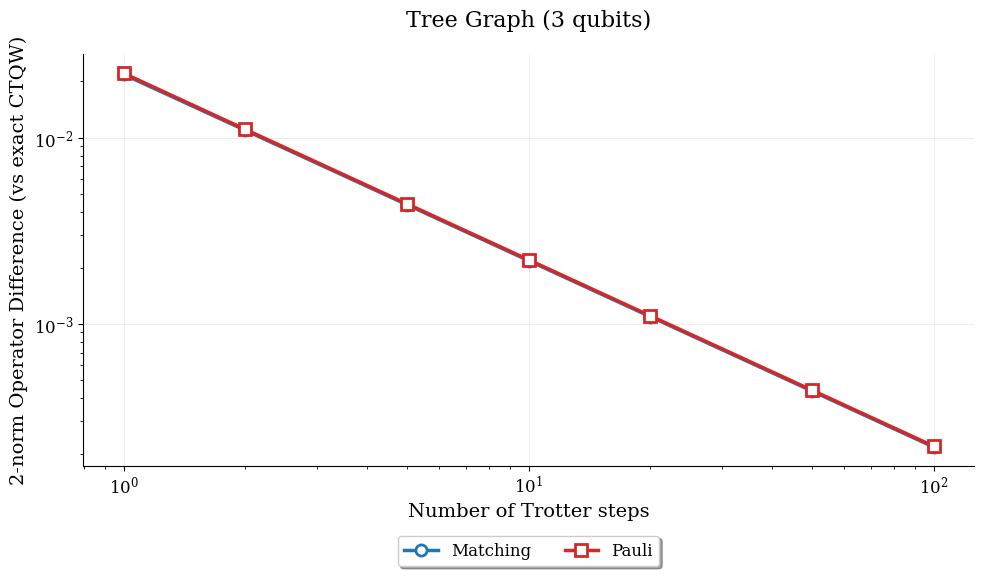

In [8]:
edges = {('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'), ('000','111')}
analyze_and_plot(edges, "Tree Graph (3 qubits)")


Dense Non-Bipartite Graph (3 qubits)
Original edges: {('100', '110'), ('000', '001'), ('010', '100'), ('000', '100'), ('101', '111'), ('011', '100'), ('001', '111'), ('001', '010'), ('010', '011'), ('100', '111'), ('000', '011'), ('100', '101'), ('010', '110'), ('001', '101'), ('000', '110'), ('010', '111'), ('000', '010'), ('011', '111'), ('110', '111'), ('001', '100'), ('011', '101'), ('000', '101'), ('001', '011'), ('101', '110')}
Number of qubits: 3

Graph:


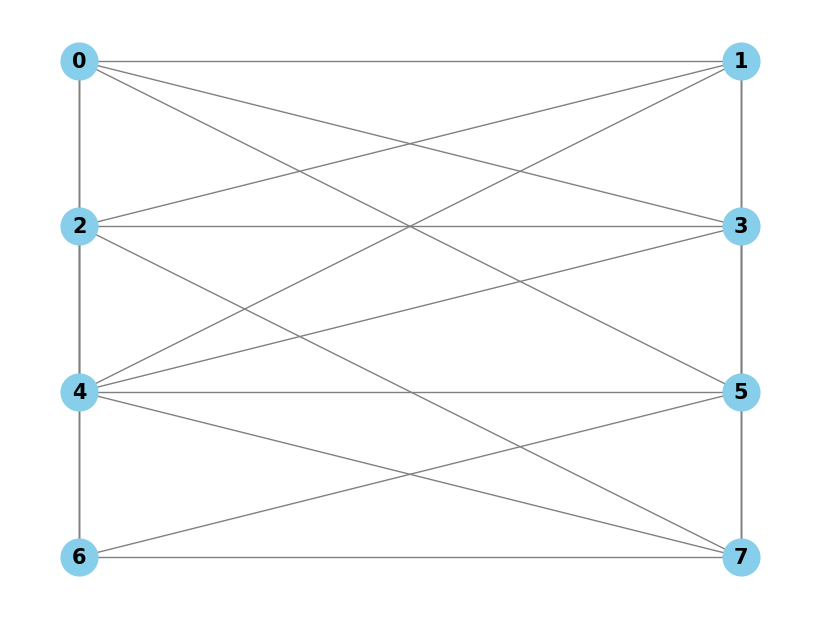

None


Matchings: 7
Matchings: [{('100', '110'), ('101', '111'), ('001', '011'), ('000', '010')}, {('100', '101'), ('000', '001'), ('110', '111'), ('010', '011')}, {('101', '110'), ('000', '011'), ('010', '100'), ('001', '111')}, {('000', '110'), ('011', '100'), ('001', '010')}, {('100', '111'), ('011', '101')}, {('000', '101'), ('010', '111'), ('001', '100')}, {('001', '101'), ('011', '111'), ('010', '110'), ('000', '100')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 37, Edges = 24, Per Edge = 1.542

Sample Circuit - Matching (n_steps=1):


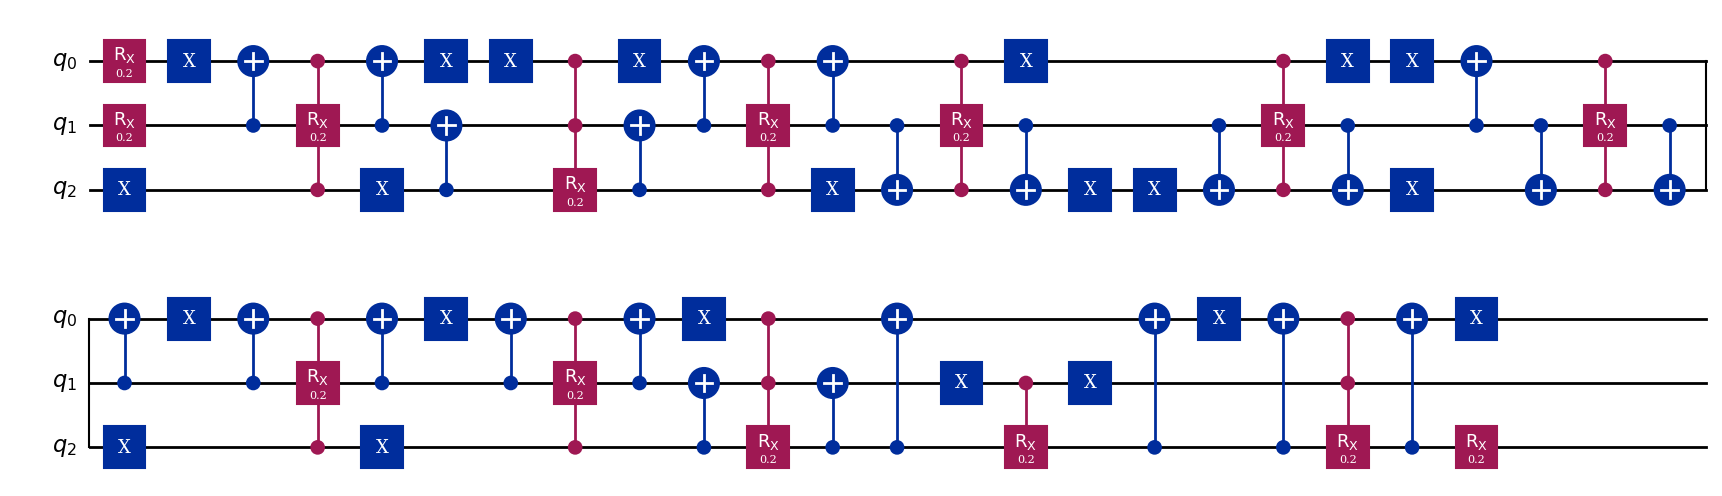


Gate Count Summary (U3/CX) for Dense Non-Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        178/106      103/85          61/32       32/20
       2        356/212     204/170         122/64       60/40
       5        890/530     507/425        305/160     147/100
      10      1780/1060    1012/850        610/320     292/200
      20      3560/2120   2022/1700       1220/640     582/400
      50      8900/5300   5052/4250      3050/1600   1502/1000
     100    17800/10600  10102/8500      6100/3200   3002/2000

Hamming cost/edge: 1.542
Error plot saved as: trotterization_plots/dense_non_bipartite_graph_3_qubits_error_analysis.pdf


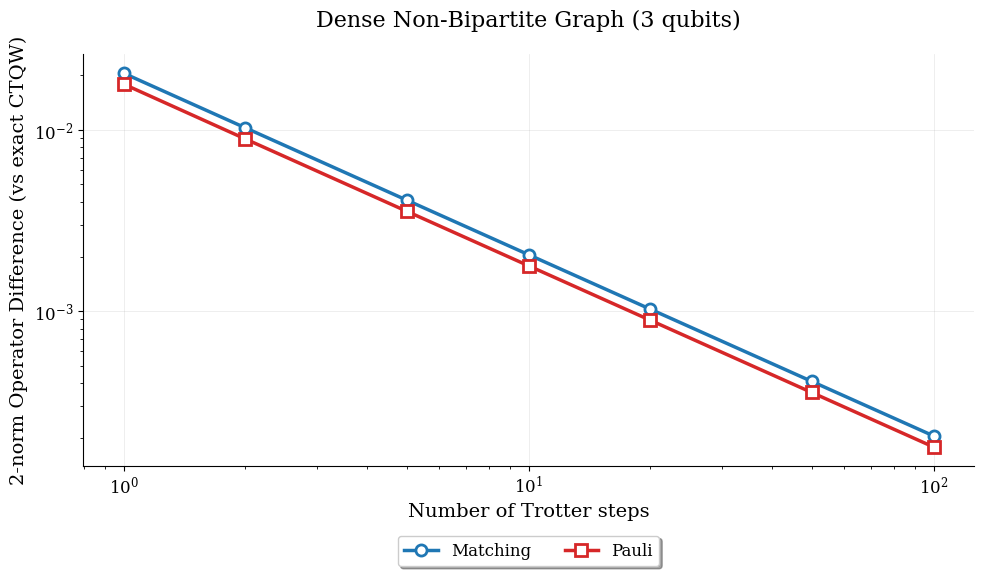

In [9]:
dense_nonbipartite_8 = {
    ('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'),
    ('001','010'), ('001','011'), ('001','100'), ('001','101'), ('001','111'),
    ('010','011'), ('010','100'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','111'),
    ('100','101'), ('100','110'), ('100','111'),
    ('101','110'), ('101','111'),
    ('110','111')
}

analyze_and_plot(dense_nonbipartite_8, "Dense Non-Bipartite Graph (3 qubits)")


Dense Bipartite Graph (3 qubits)
Original edges: {('010', '100'), ('000', '100'), ('011', '100'), ('001', '111'), ('010', '110'), ('001', '101'), ('011', '110'), ('000', '110'), ('010', '111'), ('011', '111'), ('001', '100'), ('000', '111'), ('010', '101'), ('011', '101'), ('000', '101'), ('001', '110')}
Number of qubits: 3

Graph:


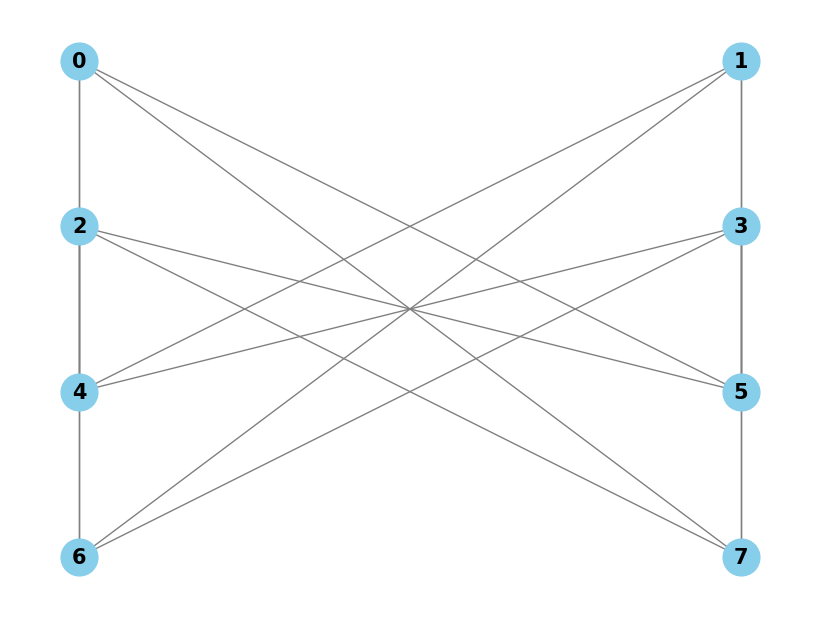

None


Matchings: 4
Matchings: [{('001', '101'), ('011', '111'), ('010', '110'), ('100', '000')}, {('000', '101'), ('100', '001'), ('011', '110'), ('010', '111')}, {('000', '110'), ('010', '100'), ('001', '111'), ('011', '101')}, {('010', '101'), ('100', '011'), ('000', '111'), ('001', '110')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 32, Edges = 16, Per Edge = 2.000

Sample Circuit - Matching (n_steps=1):


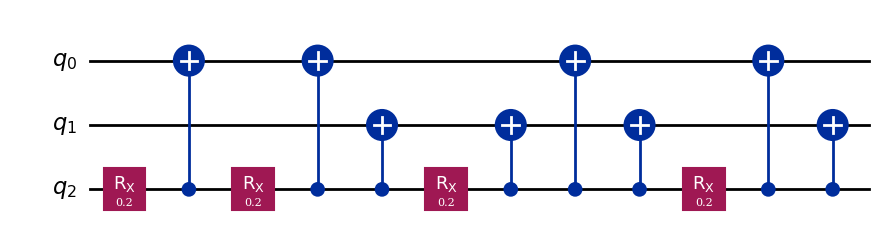


Gate Count Summary (U3/CX) for Dense Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            4/8         4/6           18/8        11/6
       2           8/16        8/12          36/16       17/12
       5          20/40       20/30          90/40       38/30
      10          40/80       40/60         180/80       73/60
      20         80/160      80/120        360/160     143/120
      50        200/400     200/300        900/400     354/300
     100        400/800     400/600       1800/800     704/600

Hamming cost/edge: 2.000
Error plot saved as: trotterization_plots/dense_bipartite_graph_3_qubits_error_analysis.pdf


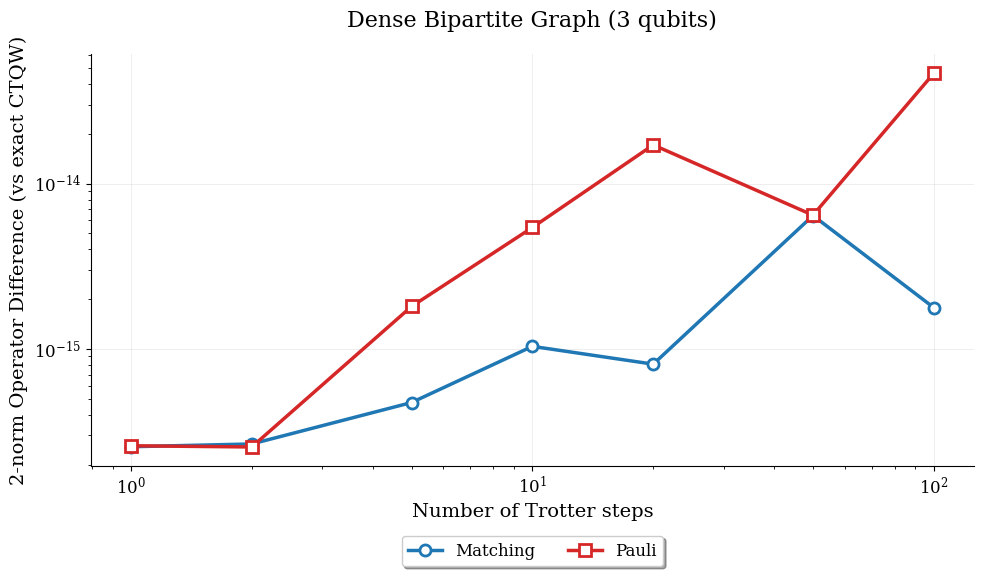

In [10]:
dense_bipartite_8 = {
    ('000','100'), ('000','101'), ('000','110'), ('000','111'),
    ('001','100'), ('001','101'), ('001','110'), ('001','111'),
    ('010','100'), ('010','101'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','110'), ('011','111')  
}
analyze_and_plot(dense_bipartite_8, "Dense Bipartite Graph (3 qubits)")


Sparse Non-Bipartite Graph (3 qubits)
Original edges: {('110', '101'), ('100', '011'), ('000', '001'), ('100', '101'), ('110', '111'), ('010', '011')}
Number of qubits: 3

Graph:


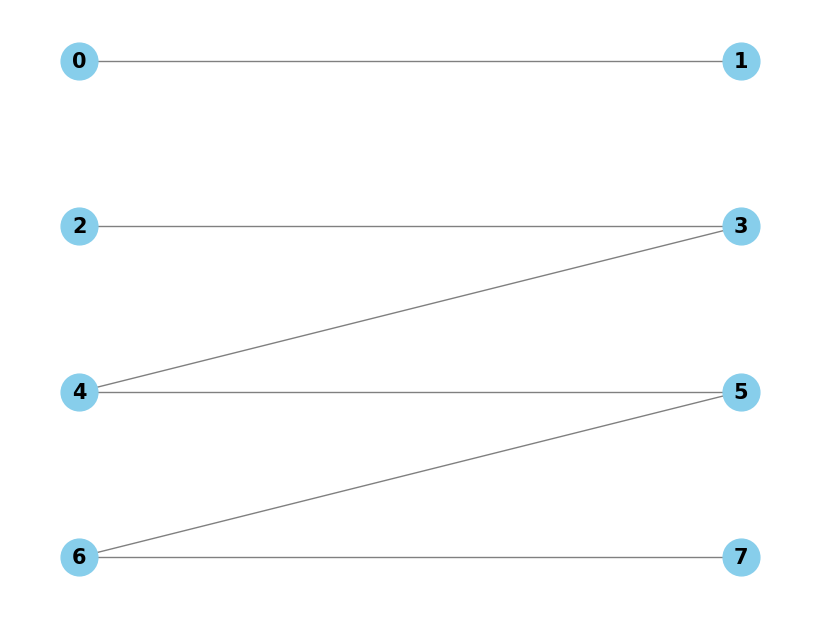

None


Matchings: 2
Matchings: [{('110', '101'), ('100', '011')}, {('100', '101'), ('000', '001'), ('110', '111'), ('010', '011')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 9, Edges = 6, Per Edge = 1.500

Sample Circuit - Matching (n_steps=1):


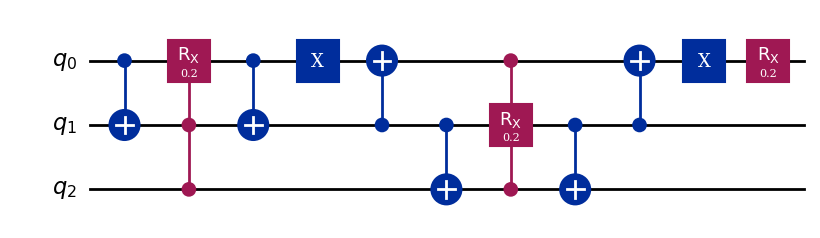


Gate Count Summary (U3/CX) for Sparse Non-Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          33/22       22/20          49/28       34/23
       2          66/44       44/40          98/56       66/46
       5        165/110     110/100        245/140     162/115
      10        330/220     220/200        490/280     322/230
      20        660/440     440/400        980/560     642/460
      50      1650/1100   1100/1000      2450/1400   1602/1150
     100      3300/2200   2200/2000      4900/2800   3202/2300

Hamming cost/edge: 1.500
Error plot saved as: trotterization_plots/sparse_non_bipartite_graph_3_qubits_error_analysis.pdf


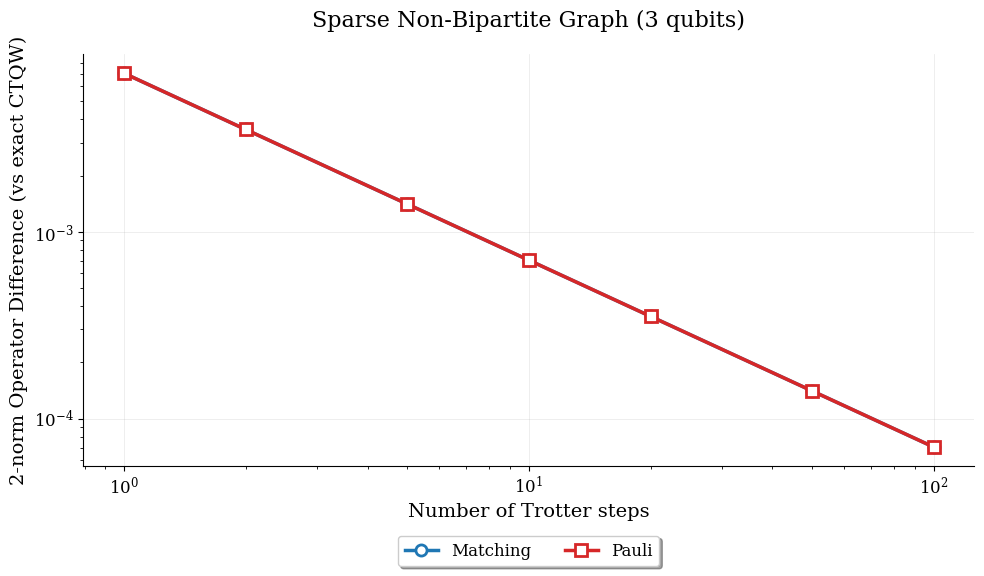

In [11]:
sparse_nonbipartite_8 = {
    ('000','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}
analyze_and_plot(sparse_nonbipartite_8, "Sparse Non-Bipartite Graph (3 qubits)")


Sparse Bipartite Graph (3 qubits)
Original edges: {('110', '101'), ('100', '011'), ('000', '001'), ('100', '101'), ('110', '111'), ('010', '011'), ('010', '001')}
Number of qubits: 3

Graph:


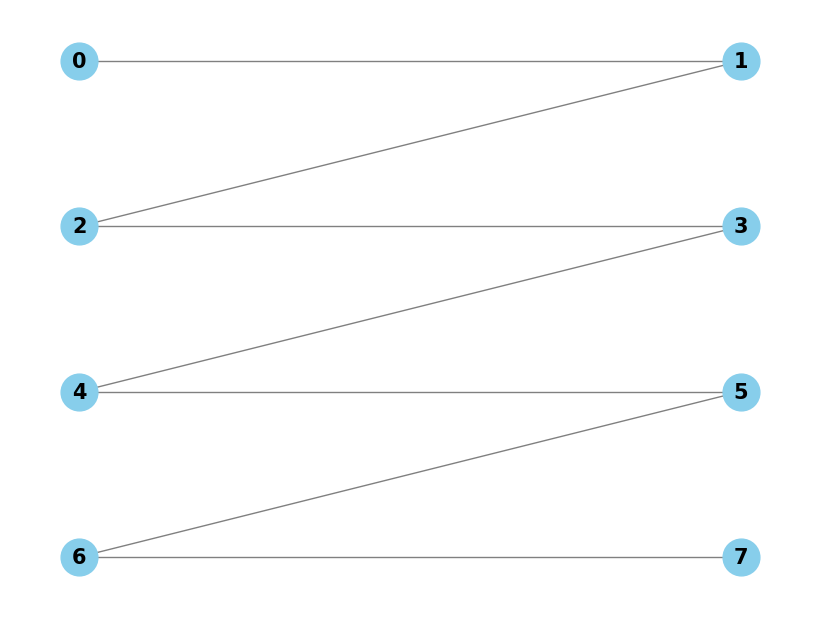

None


Matchings: 2
Matchings: [{('110', '101'), ('100', '011'), ('010', '001')}, {('100', '101'), ('000', '001'), ('110', '111'), ('010', '011')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 11, Edges = 7, Per Edge = 1.571

Sample Circuit - Matching (n_steps=1):


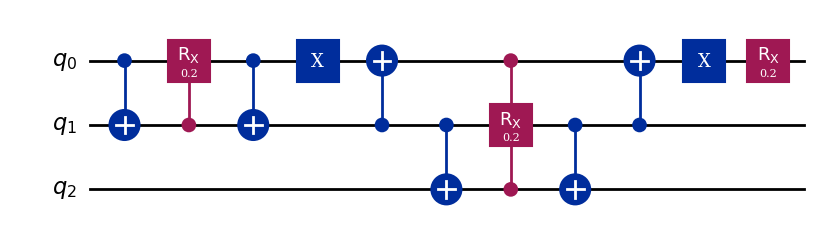


Gate Count Summary (U3/CX) for Sparse Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          21/16       16/12          39/20       26/16
       2          42/32       31/23          78/40       49/32
       5         105/80       76/56        195/100      118/80
      10        210/160     151/111        390/200     233/160
      20        420/320     301/221        780/400     463/320
      50       1050/800     751/551      1950/1000    1153/800
     100      2100/1600   1501/1101      3900/2000   2303/1600

Hamming cost/edge: 1.571
Error plot saved as: trotterization_plots/sparse_bipartite_graph_3_qubits_error_analysis.pdf


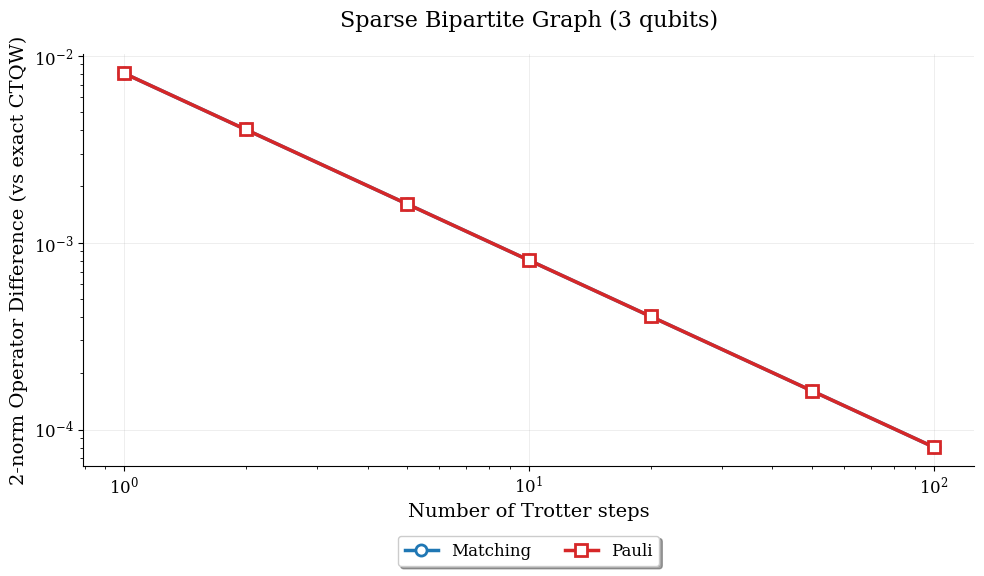

In [12]:
sparse_bipartite_8 = {
    ('000','001'), ('010','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}

analyze_and_plot(sparse_bipartite_8, "Sparse Bipartite Graph (3 qubits)")


Dense Non-Bipartite Graph (4 qubits)
Original edges: {('0001', '0011'), ('0111', '1111'), ('0101', '0110'), ('0000', '0011'), ('0100', '1010'), ('1110', '1111'), ('0011', '0111'), ('1011', '1101'), ('1001', '1110'), ('1011', '1100'), ('0110', '1010'), ('0101', '0111'), ('0001', '1001'), ('0010', '0110'), ('0100', '1100'), ('0011', '0101'), ('0001', '0010'), ('0101', '1011'), ('0111', '1011'), ('0000', '0010'), ('0000', '0111'), ('1010', '1100'), ('0010', '1000'), ('0011', '0100'), ('0110', '1100'), ('1011', '1111'), ('1000', '1011'), ('1001', '1011'), ('1100', '1101'), ('0000', '0110'), ('0011', '1011'), ('0010', '0100'), ('0001', '0101'), ('0100', '0110'), ('1010', '1111'), ('0000', '0101'), ('0001', '1000'), ('1010', '1110'), ('0110', '0111'), ('0100', '0101'), ('0001', '0100'), ('0100', '1000'), ('0000', '0100'), ('0110', '1110'), ('1101', '1110'), ('1101', '1111'), ('1000', '1010'), ('1100', '1110'), ('1100', '1111'), ('1001', '1010'), ('0000', '0001'), ('0101', '1101'), ('0111', 

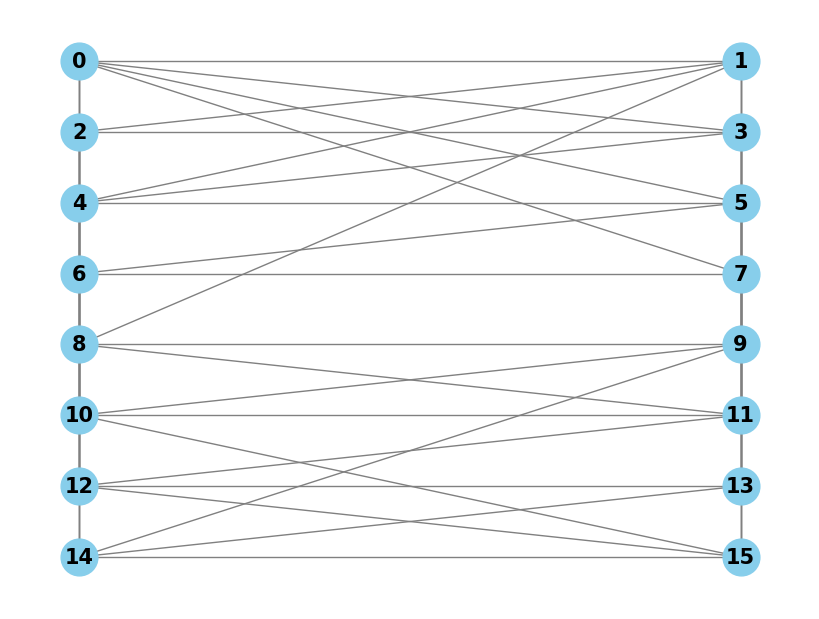

None


Matchings: 10
Matchings: [{('0001', '0011'), ('0100', '0110'), ('0000', '0010'), ('1000', '1010'), ('1101', '1111'), ('1001', '1011'), ('1100', '1110'), ('0101', '0111')}, {('0101', '1101'), ('0111', '1111'), ('0100', '1100'), ('0010', '1010'), ('0110', '1110'), ('0011', '1011'), ('0001', '1001')}, {('0101', '0110'), ('0000', '0011'), ('0001', '0010'), ('0100', '1010'), ('1011', '1101'), ('1001', '1110'), ('1100', '1111')}, {('0011', '0101'), ('0000', '0111'), ('0001', '0100'), ('0010', '1000'), ('1101', '1110'), ('1011', '1100'), ('0110', '1010')}, {('0111', '1101'), ('0001', '1000'), ('0101', '1011'), ('1010', '1100'), ('0011', '0100'), ('0000', '0110')}, {('1010', '1111'), ('0000', '0101'), ('0111', '1011'), ('0110', '1100'), ('0011', '1001'), ('0010', '0100')}, {('1001', '1010'), ('1000', '1011')}, {('0100', '1000'), ('0101', '1001')}, {('1110', '1111'), ('0010', '0011'), ('0110', '0111'), ('0100', '0101'), ('1010', '1011'), ('1100', '1101'), ('1000', '1001'), ('0000', '0001')}, {

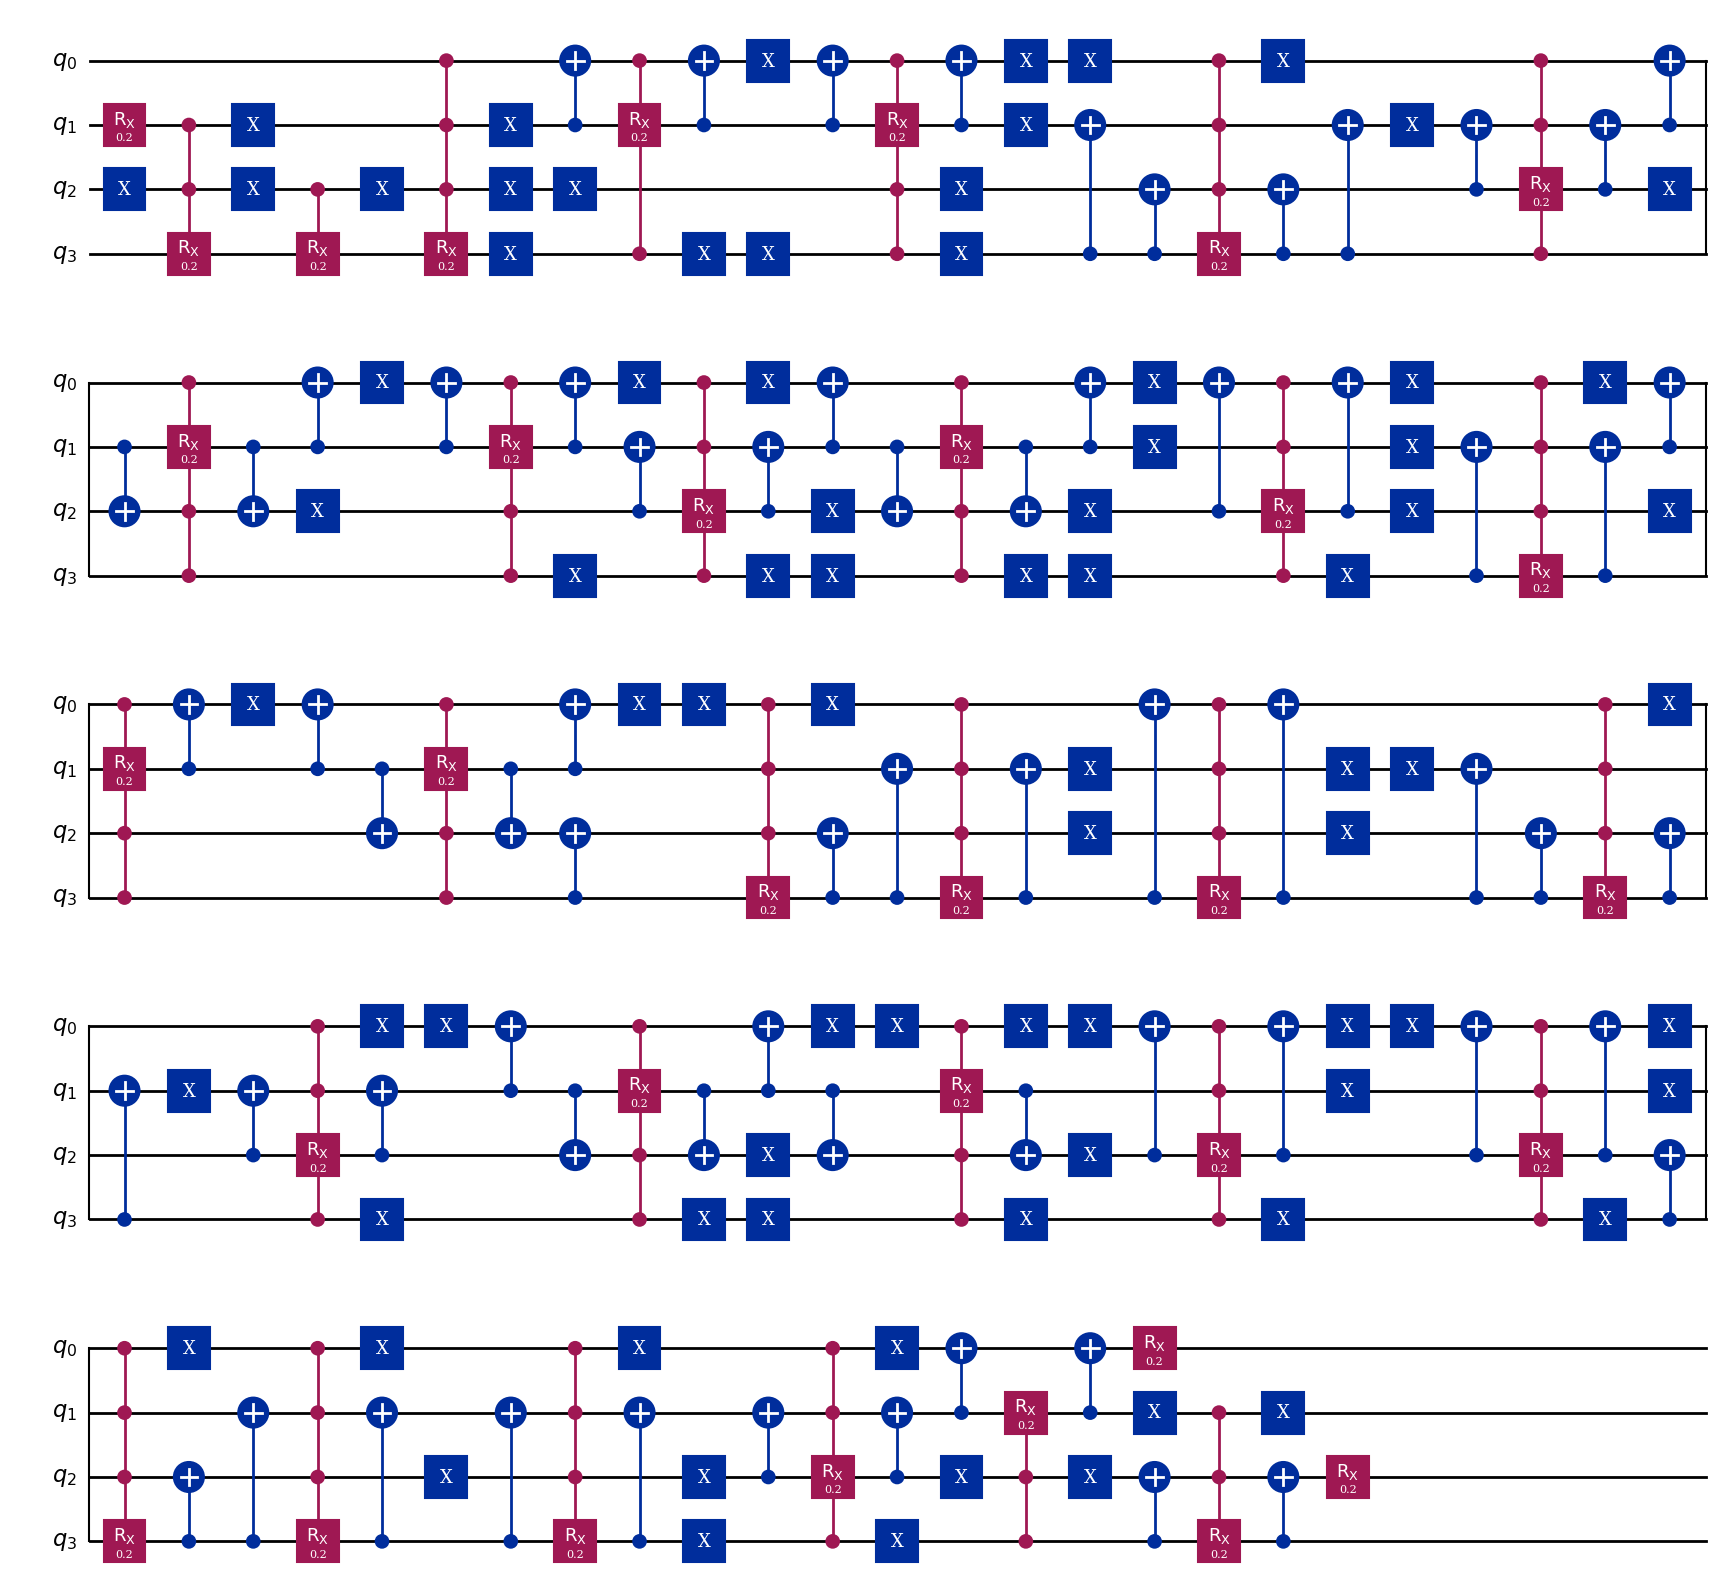


Gate Count Summary (U3/CX) for Dense Non-Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1       1021/600     479/575        268/200     155/101
       2      2042/1200    957/1149        536/400     310/202
       5      5105/3000   2391/2871      1340/1000     763/505
      10     10210/6000   4781/5741      2680/2000   1532/1010
      20    20420/12000  9561/11481      5360/4000   3062/2020
      50    51050/30000 23901/28701    13400/10000   7653/5050
     100   102100/60000 47801/57401    26800/20000 15203/10100

Hamming cost/edge: 1.590
Error plot saved as: trotterization_plots/dense_non_bipartite_graph_4_qubits_error_analysis.pdf


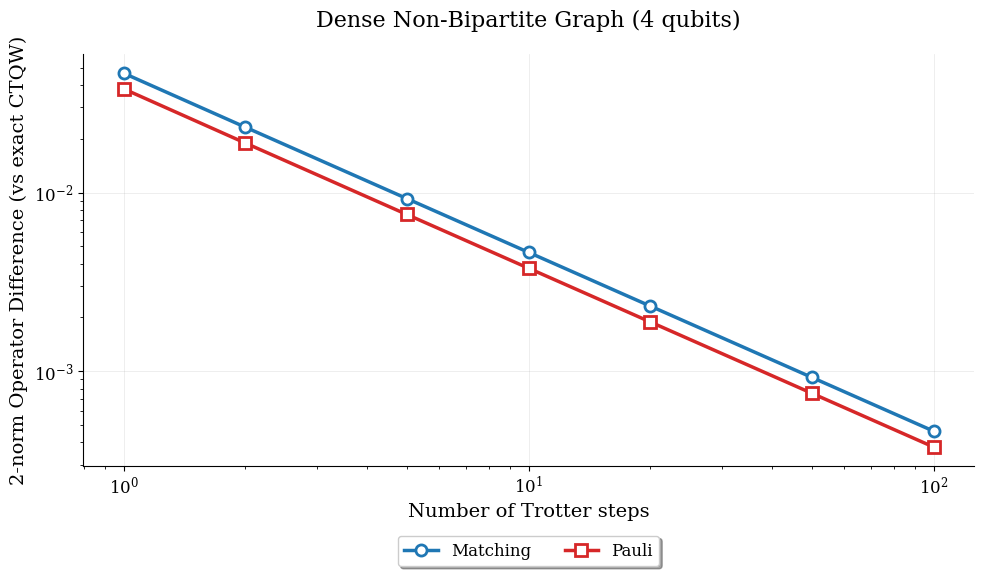

In [13]:
dense_nonbipartite_16 = {
    ('0000','0001'), ('0000','0010'), ('0000','0011'), ('0000','0100'), ('0000','0101'), ('0000','0110'), ('0000','0111'),
    ('0001','0010'), ('0001','0011'), ('0001','0100'), ('0001','0101'), ('0001','1000'), ('0001','1001'),
    ('0010','0011'), ('0010','0100'), ('0010','0110'), ('0010','1000'), ('0010','1010'),
    ('0011','0100'), ('0011','0101'), ('0011','0111'), ('0011','1001'), ('0011','1011'),
    ('0100','0101'), ('0100','0110'), ('0100','1000'), ('0100','1010'), ('0100','1100'),
    ('0101','0110'), ('0101','0111'), ('0101','1001'), ('0101','1011'), ('0101','1101'),
    ('0110','0111'), ('0110','1010'), ('0110','1100'), ('0110','1110'),
    ('0111','1011'), ('0111','1101'), ('0111','1111'),
    ('1000','1001'), ('1000','1010'), ('1000','1011'), ('1000','1100'),
    ('1001','1010'), ('1001','1011'), ('1001','1101'), ('1001','1110'),
    ('1010','1011'), ('1010','1100'), ('1010','1110'), ('1010','1111'),
    ('1011','1100'), ('1011','1101'), ('1011','1111'),
    ('1100','1101'), ('1100','1110'), ('1100','1111'),
    ('1101','1110'), ('1101','1111'),
    ('1110','1111')
}
analyze_and_plot(dense_nonbipartite_16, "Dense Non-Bipartite Graph (4 qubits)")


Dense Bipartite Graph (4 qubits)
Original edges: {('0111', '1111'), ('0111', '1110'), ('0010', '1001'), ('0011', '1111'), ('0000', '1101'), ('0011', '1110'), ('0001', '1001'), ('0100', '1100'), ('0011', '1000'), ('0100', '1001'), ('0110', '1100'), ('0110', '1001'), ('0011', '1011'), ('0000', '1000'), ('0101', '1010'), ('0111', '1010'), ('0110', '1111'), ('0110', '1110'), ('0000', '1011'), ('0011', '1010'), ('0101', '1101'), ('0111', '1101'), ('0010', '1010'), ('0011', '1101'), ('0101', '1111'), ('0101', '1110'), ('0001', '1010'), ('0010', '1101'), ('0100', '1010'), ('0001', '1100'), ('0101', '1000'), ('0000', '1100'), ('0001', '1101'), ('0010', '1111'), ('0010', '1110'), ('0110', '1010'), ('0111', '1000'), ('0000', '1001'), ('0100', '1101'), ('0101', '1011'), ('0111', '1011'), ('0001', '1111'), ('0001', '1110'), ('0010', '1000'), ('0110', '1101'), ('0000', '1111'), ('0000', '1110'), ('0100', '1111'), ('0100', '1110'), ('0010', '1011'), ('0001', '1000'), ('0100', '1000'), ('0001', '101

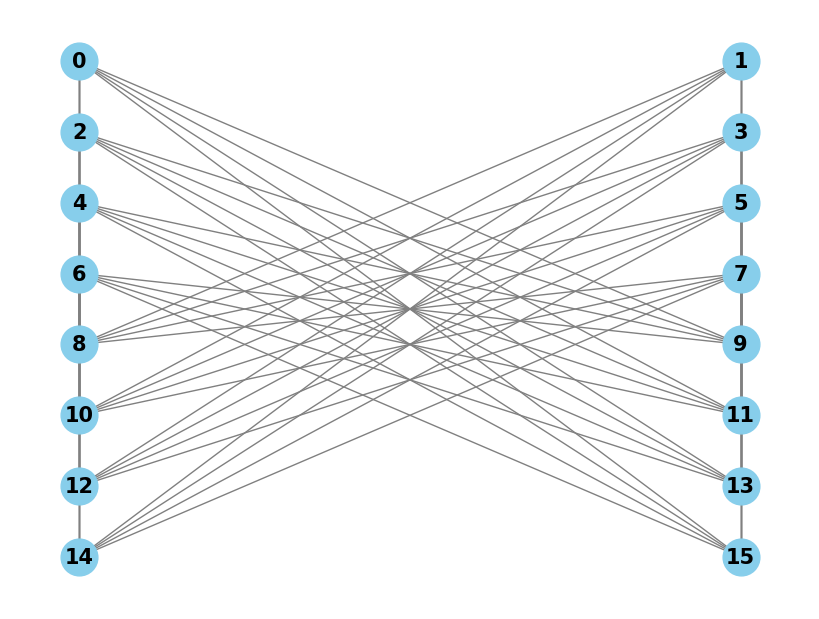

None


Matchings: 8
Matchings: [{('0100', '1100'), ('0000', '1000'), ('0111', '1111'), ('0010', '1010'), ('1101', '0101'), ('1001', '0001'), ('1110', '0110'), ('0011', '1011')}, {('1001', '0000'), ('0010', '1011'), ('0111', '1110'), ('0001', '1000'), ('1100', '0101'), ('1101', '0100'), ('0011', '1010'), ('1111', '0110')}, {('0111', '1101'), ('1100', '0110'), ('1110', '0100'), ('1001', '0011'), ('1111', '0101'), ('0010', '1000'), ('0001', '1011'), ('0000', '1010')}, {('0111', '1100'), ('0010', '1001'), ('0011', '1000'), ('1111', '0100'), ('0000', '1011'), ('1110', '0101'), ('0001', '1010'), ('1101', '0110')}, {('1101', '0001'), ('0111', '1011'), ('1111', '0011'), ('1001', '0101'), ('0100', '1000'), ('0000', '1100'), ('0110', '1010'), ('1110', '0010')}, {('1000', '0101'), ('0111', '1010'), ('1111', '0010'), ('0001', '1100'), ('0000', '1101'), ('1001', '0100'), ('0110', '1011'), ('1110', '0011')}, {('0100', '1010'), ('1111', '0001'), ('1011', '0101'), ('0111', '1001'), ('1110', '0000'), ('0011'

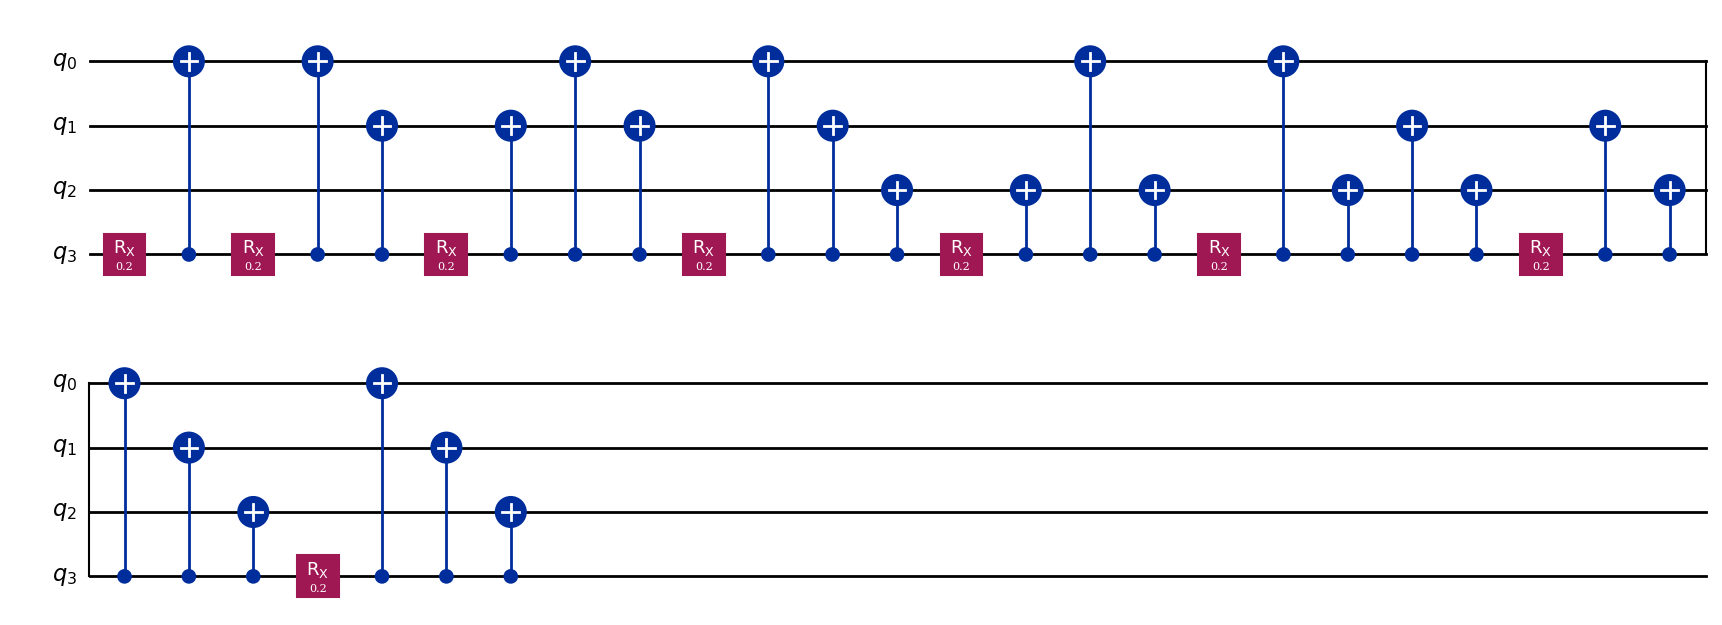


Gate Count Summary (U3/CX) for Dense Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1           8/24        8/14          46/24       22/14
       2          16/48       16/28          92/48       37/28
       5         40/120       40/70        230/120       88/70
      10         80/240      80/140        460/240     173/140
      20        160/480     160/280        920/480     343/280
      50       400/1200     400/700      2300/1200     855/700
     100       800/2400    800/1400      4600/2400   1705/1400

Hamming cost/edge: 2.500
Error plot saved as: trotterization_plots/dense_bipartite_graph_4_qubits_error_analysis.pdf


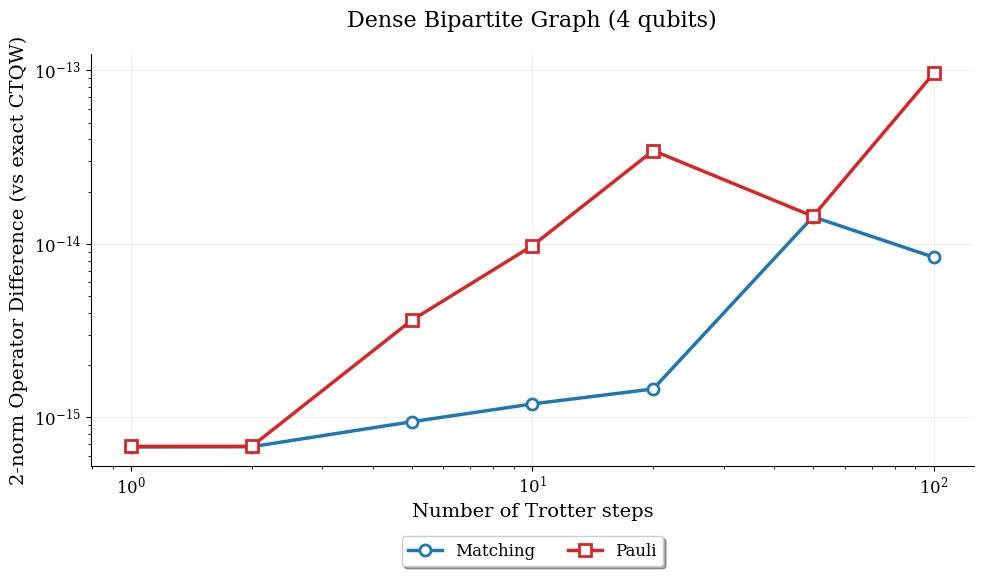

In [14]:
dense_bipartite_16 = {
    ('0000','1000'), ('0000','1001'), ('0000','1010'), ('0000','1011'), ('0000','1100'), ('0000','1101'), ('0000','1110'), ('0000','1111'),
    ('0001','1000'), ('0001','1001'), ('0001','1010'), ('0001','1011'), ('0001','1100'), ('0001','1101'), ('0001','1110'), ('0001','1111'),
    ('0010','1000'), ('0010','1001'), ('0010','1010'), ('0010','1011'), ('0010','1100'), ('0010','1101'), ('0010','1110'), ('0010','1111'),
    ('0011','1000'), ('0011','1001'), ('0011','1010'), ('0011','1011'), ('0011','1100'), ('0011','1101'), ('0011','1110'), ('0011','1111'),
    ('0100','1000'), ('0100','1001'), ('0100','1010'), ('0100','1011'), ('0100','1100'), ('0100','1101'), ('0100','1110'), ('0100','1111'),
    ('0101','1000'), ('0101','1001'), ('0101','1010'), ('0101','1011'), ('0101','1100'), ('0101','1101'), ('0101','1110'), ('0101','1111'),
    ('0110','1000'), ('0110','1001'), ('0110','1010'), ('0110','1011'), ('0110','1100'), ('0110','1101'), ('0110','1110'), ('0110','1111'),
    ('0111','1000'), ('0111','1001'), ('0111','1010'), ('0111','1011'), ('0111','1100'), ('0111','1101'), ('0111','1110'), ('0111','1111')
}

analyze_and_plot(dense_bipartite_16, "Dense Bipartite Graph (4 qubits)")


Sparse Non-Bipartite Graph (4 qubits)
Original edges: {('0001', '0011'), ('0000', '0100'), ('1010', '0101'), ('0010', '0011'), ('0111', '0110'), ('0001', '0100'), ('0010', '0110')}
Number of qubits: 4

Graph:


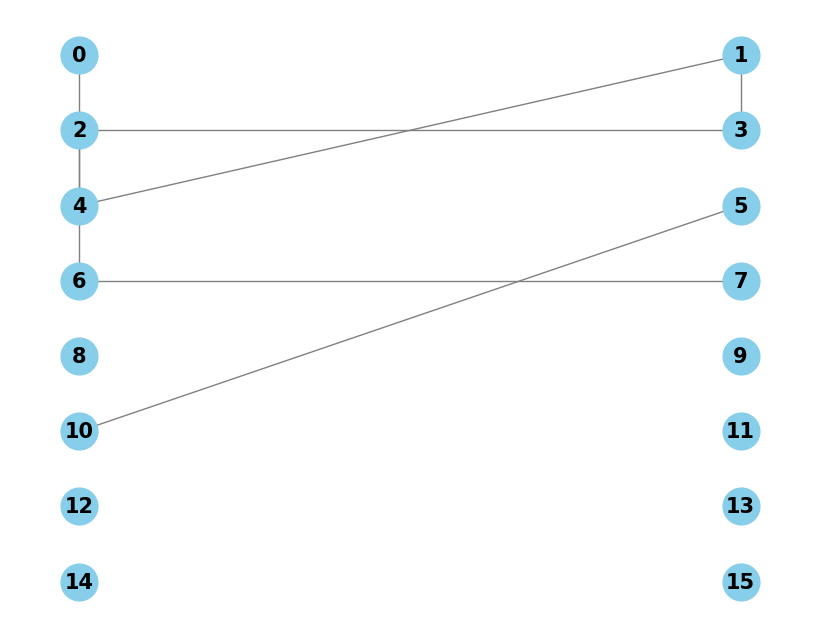

None


Matchings: 4
Matchings: [{('0001', '0011'), ('1010', '0101')}, {('0000', '0100'), ('0010', '0110')}, {('0001', '0100')}, {('0010', '0011'), ('0111', '0110')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 11, Edges = 7, Per Edge = 1.571

Sample Circuit - Matching (n_steps=1):


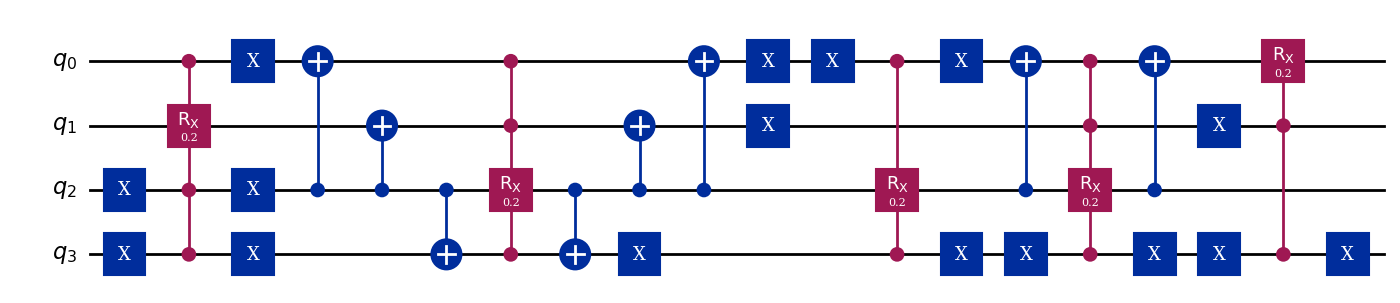


Gate Count Summary (U3/CX) for Sparse Non-Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         151/84       74/81        154/120      104/80
       2        302/168     145/162        308/240     205/160
       5        755/420     358/405        770/600     511/400
      10       1510/840     713/810      1540/1200    1031/800
      20      3020/1680   1423/1620      3080/2400   2061/1600
      50      7550/4200   3553/4050      7700/6000   5201/4000
     100     15100/8400   7103/8100    15400/12000  10201/8000

Hamming cost/edge: 1.571
Error plot saved as: trotterization_plots/sparse_non_bipartite_graph_4_qubits_error_analysis.pdf


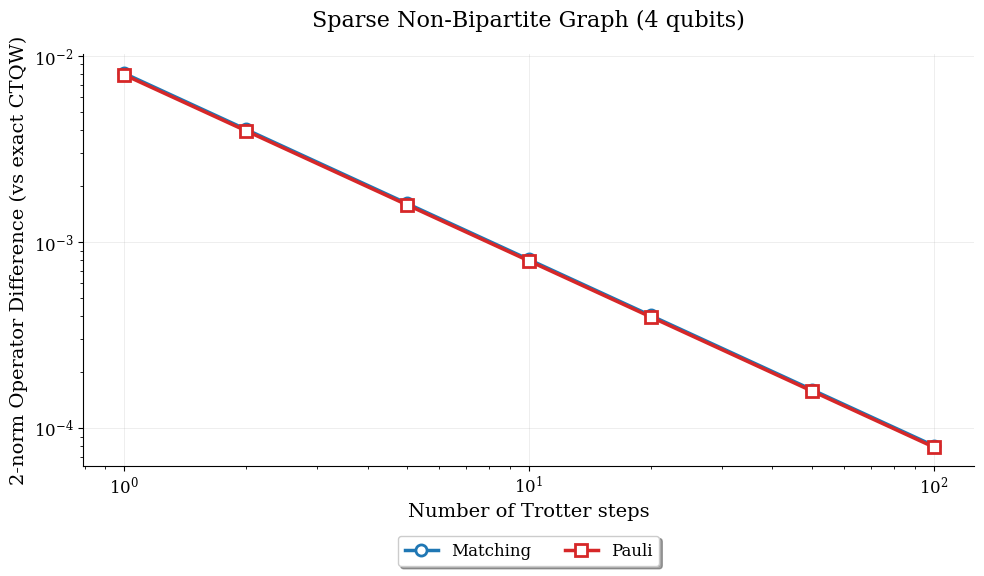

In [15]:
sparse_nonbipartite_16 = {
    ('0000','0100'),  # H=1, start cluster in 0xxx
    ('0001','0100'),  # H=2, degree-2 at 0100
    ('0001','0011'),  # H=1, degree-2 at 0001
    ('0010','0011'),  # H=1, degree-2 at 0011
    ('0010','0110'),  # H=1, degree-2 at 0010
    ('0111','0110'),  # H=1, degree-2 at 0110
    ('1010','0101'),  # H=3, high-Hamming bridge to 1xxx
}

analyze_and_plot(sparse_nonbipartite_16, "Sparse Non-Bipartite Graph (4 qubits)")


Sparse Bipartite Graph (4 qubits)
Original edges: {('0000', '0001'), ('0110', '0101'), ('0000', '0011'), ('1110', '1101'), ('0010', '0001'), ('0010', '0101'), ('0100', '0011'), ('1000', '0111'), ('1010', '1101'), ('1000', '1011'), ('1010', '1001'), ('1100', '1111'), ('0100', '0111'), ('0110', '1001'), ('1100', '1011')}
Number of qubits: 4

Graph:


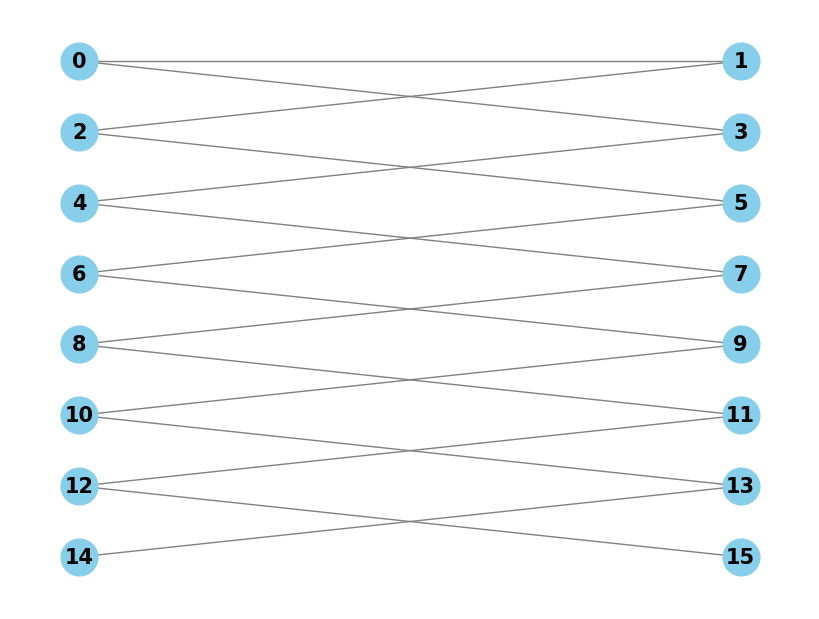

None


Matchings: 3
Matchings: [{('0110', '0101'), ('1110', '1101'), ('0100', '0011'), ('1000', '0111'), ('1010', '1001'), ('1100', '1111'), ('0000', '0001')}, {('0000', '0011'), ('0010', '0001'), ('1010', '1101'), ('1000', '1011'), ('0100', '0111'), ('0110', '1001')}, {('0010', '0101'), ('1100', '1011')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 37, Edges = 15, Per Edge = 2.467

Sample Circuit - Matching (n_steps=1):


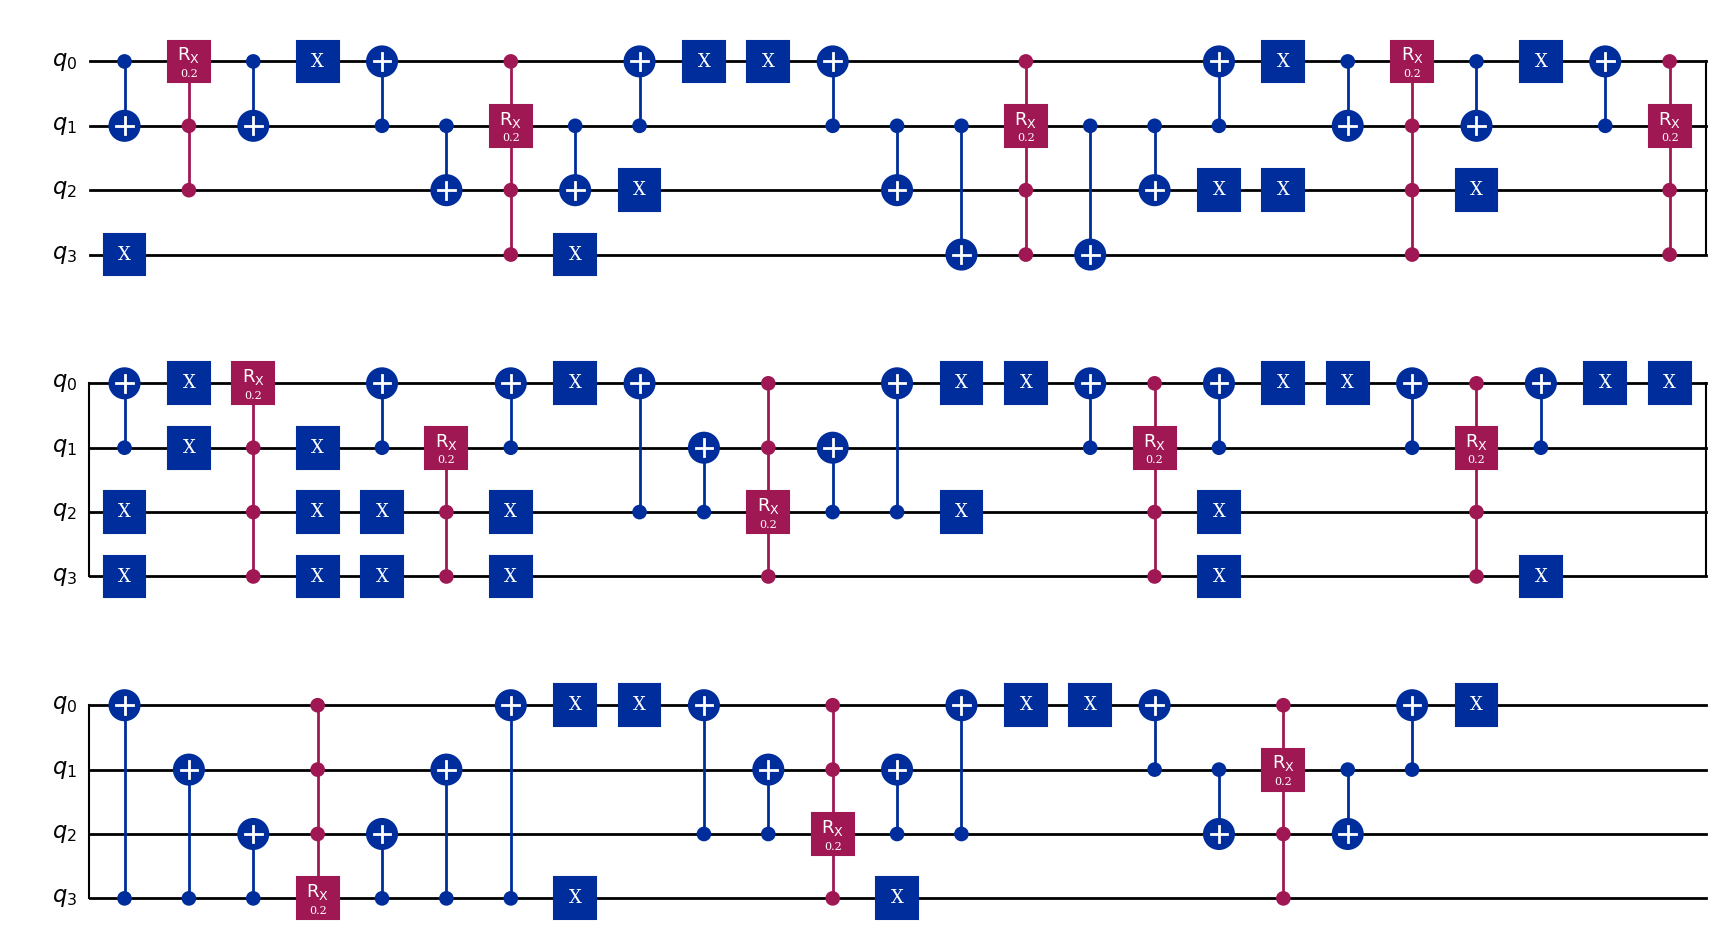


Gate Count Summary (U3/CX) for Sparse Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        455/276     215/263          77/58       42/52
       2        910/552     430/526        154/116      83/104
       5      2275/1380   1075/1315        385/290     206/260
      10      4550/2760   2150/2630        770/580     411/520
      20      9100/5520   4300/5260      1540/1160    821/1040
      50    22750/13800 10750/13150      3850/2900   2051/2600
     100    45500/27600 21500/26300      7700/5800   4101/5200

Hamming cost/edge: 2.467
Error plot saved as: trotterization_plots/sparse_bipartite_graph_4_qubits_error_analysis.pdf


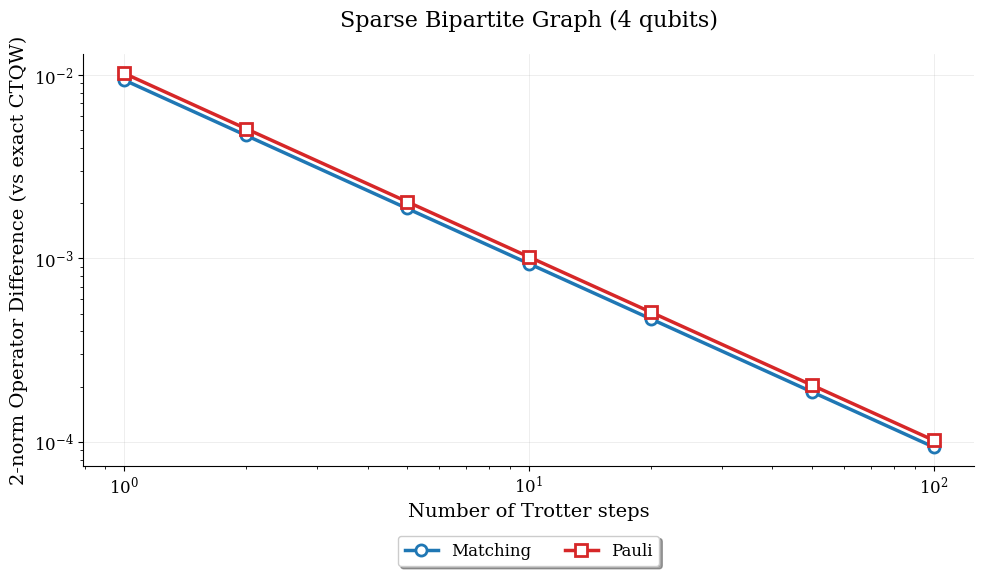

In [16]:
sparse_bipartite_16 = {
    ('0000','0001'), ('0000','0011'),
    ('0010','0001'), ('0010','0101'),
    ('0100','0011'), ('0100','0111'),
    ('0110','0101'), ('0110','1001'),
    ('1000','0111'), ('1000','1011'),
    ('1010','1001'), ('1010','1101'),
    ('1100','1011'), ('1100','1111'),
    ('1110','1101')
}

analyze_and_plot(sparse_bipartite_16, "Sparse Bipartite Graph (4 qubits)")


Sparse Non Bipartite Graph (5 qubits)
Original edges: {('00100', '00101'), ('00110', '00101'), ('01000', '00111'), ('00010', '00011'), ('00010', '00001'), ('10000', '01111'), ('01001', '01011'), ('00000', '00001'), ('00100', '00011')}
Number of qubits: 5

Graph:


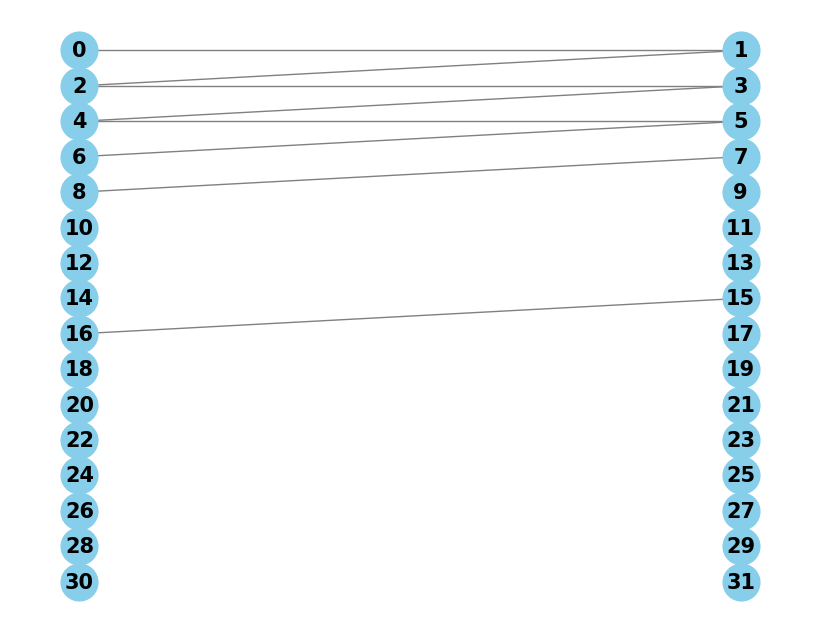

None


Matchings: 3
Matchings: [{('00100', '00101'), ('01000', '00111'), ('00010', '00011'), ('10000', '01111'), ('00000', '00001')}, {('00010', '00001'), ('00110', '00101'), ('00100', '00011')}, {('01001', '01011')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 20, Edges = 9, Per Edge = 2.222

Sample Circuit - Matching (n_steps=1):


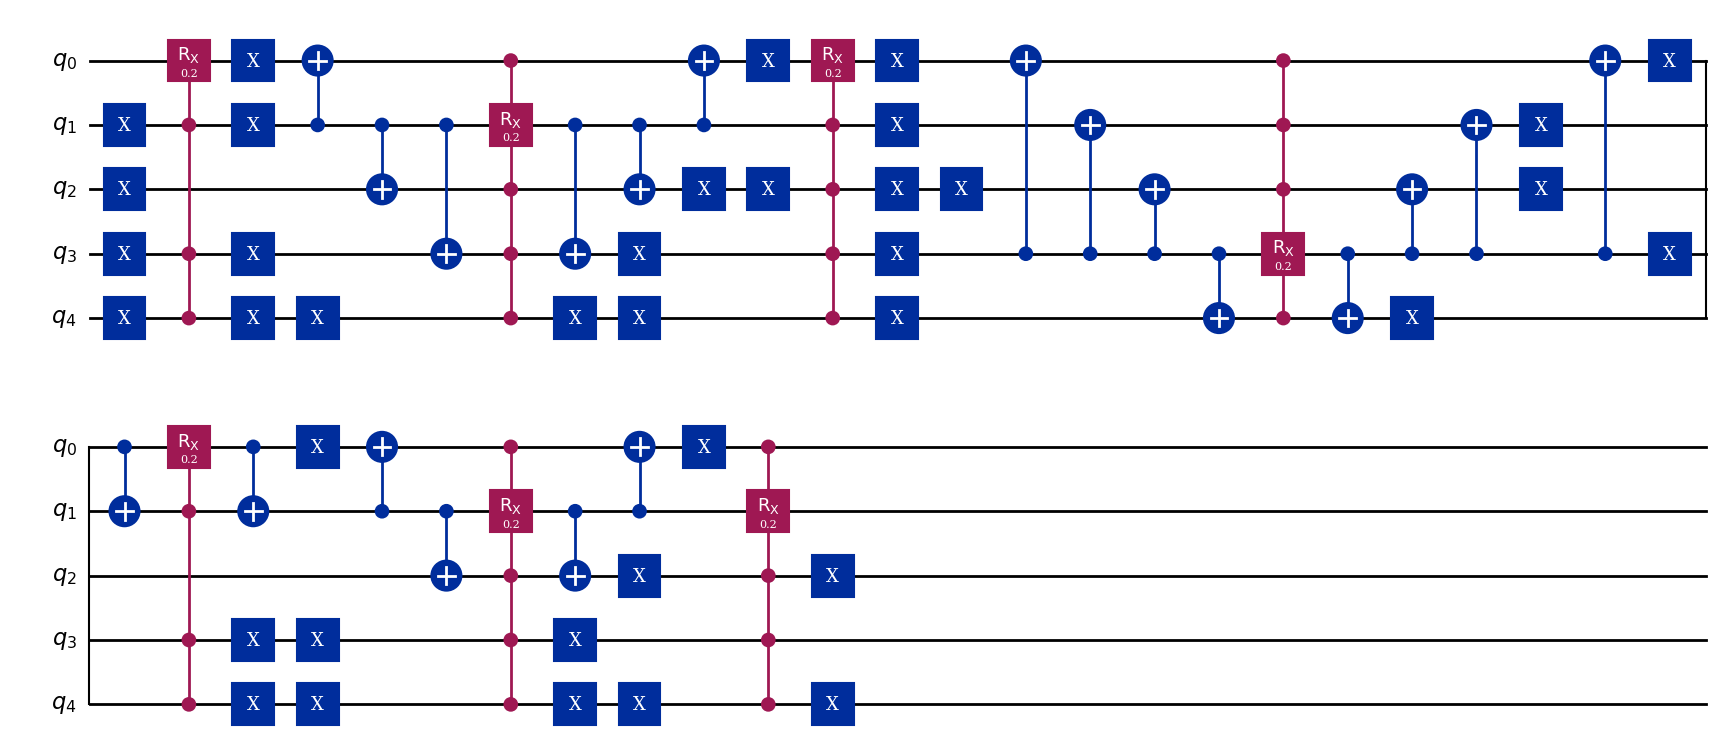


Gate Count Summary (U3/CX) for Sparse Non Bipartite Graph (5 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        318/180     188/178        564/496     380/276
       2        636/360     371/356       1128/992     763/552
       5       1590/900     920/890      2820/2480   1891/1380
      10      3180/1800   1835/1780      5640/4960   3811/2760
      20      6360/3600   3665/3560     11280/9920   7601/5520
      50     15900/9000   9155/8900    28200/24800 19001/13800
     100    31800/18000 18305/17800    56400/49600 37901/27600

Hamming cost/edge: 2.222
Error plot saved as: trotterization_plots/sparse_non_bipartite_graph_5_qubits_error_analysis.pdf


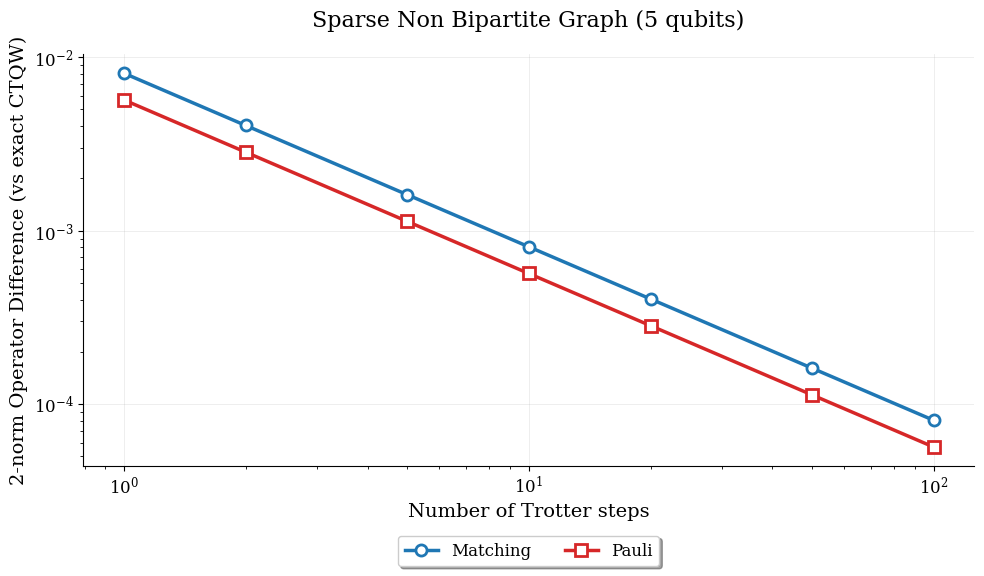

In [17]:
sparse_nonbipartite_32 = {
    # Cluster in 0xxxx region
    ('00000','00001'),  # H=1
    ('00010','00001'),  # H=2, degree-2 at 00001
    ('00010','00011'),  # H=1, degree-2 at 00010
    ('00100','00011'),  # H=2, degree-2 at 00011
    ('00100','00101'),  # H=1, degree-2 at 00100
    ('00110','00101'),  # H=2, degree-2 at 00101
    ('01000','00111'),  # H=3, bridge
    ('01001','01011'),  # H=1, small cluster in 01xxx
    ('10000','01111'),  # H=4, high-Hamming bridge to 1xxxx
}

analyze_and_plot(sparse_nonbipartite_32, "Sparse Non Bipartite Graph (5 qubits)" )


Cayley Graph of Z2 x Z2 x Z2 (3 qubits)
Original edges: {('100', '110'), ('000', '001'), ('000', '010'), ('000', '100'), ('001', '101'), ('011', '111'), ('101', '111'), ('110', '111'), ('010', '011'), ('100', '101'), ('010', '110'), ('001', '011')}
Number of qubits: 3

Graph:


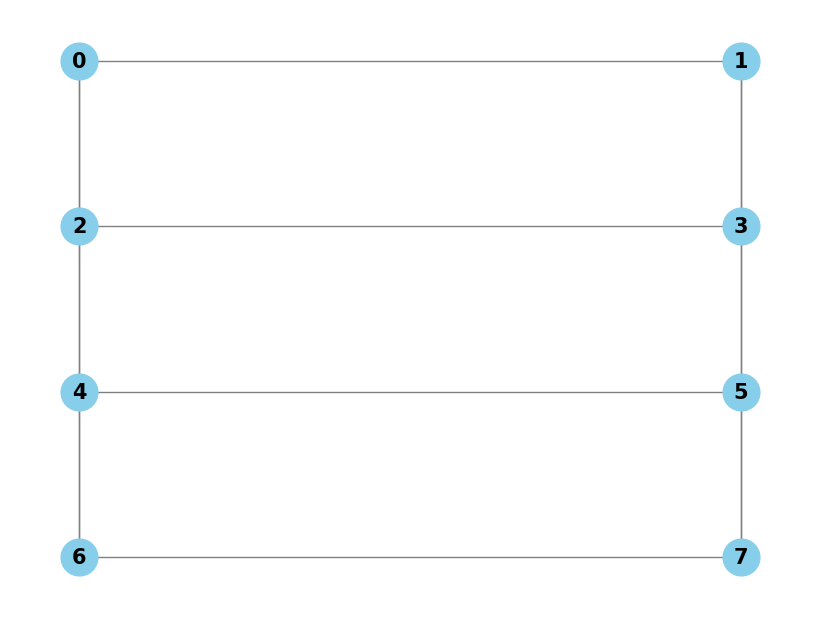

None


Matchings: 3
Matchings: [{('100', '110'), ('101', '111'), ('001', '011'), ('000', '010')}, {('100', '101'), ('000', '001'), ('110', '111'), ('010', '011')}, {('001', '101'), ('011', '111'), ('010', '110'), ('000', '100')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 12, Edges = 12, Per Edge = 1.000

Sample Circuit - Matching (n_steps=1):


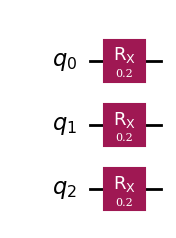


Gate Count Summary (U3/CX) for Cayley Graph of Z2 x Z2 x Z2 (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            3/0         3/0            3/0         3/0
       2            6/0         3/0            6/0         3/0
       5           15/0         3/0           15/0         3/0
      10           30/0         3/0           30/0         3/0
      20           60/0         3/0           60/0         3/0
      50          150/0         3/0          150/0         3/0
     100          300/0         3/0          300/0         3/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cayley_graph_of_z2_x_z2_x_z2_3_qubits_error_analysis.pdf


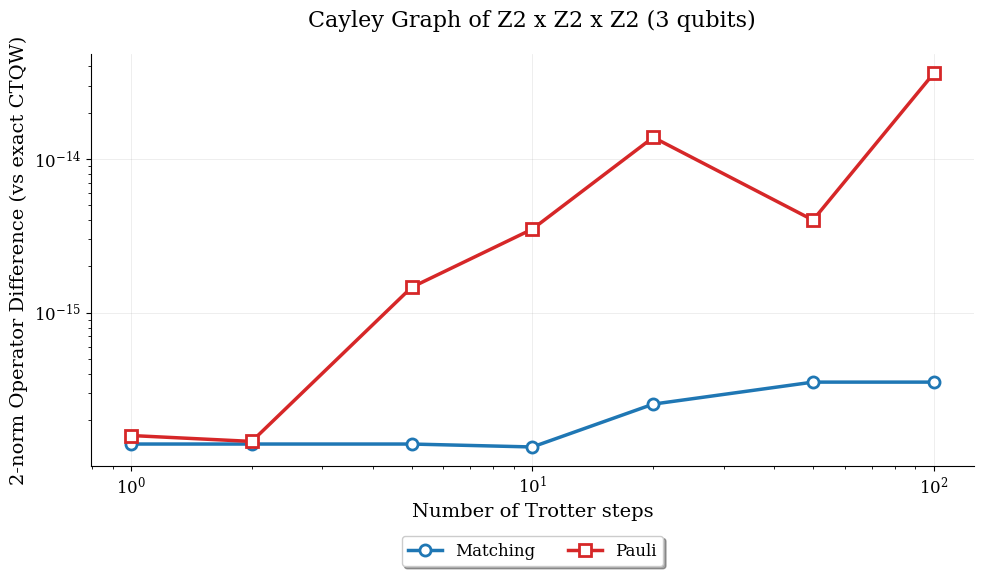

In [18]:
cayley_8 = set()
vertices_8 = [format(i, '03b') for i in range(8)]
generators_8 = ['001', '010', '100']
for v in vertices_8:
    v_int = int(v, 2)
    for g in generators_8:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '03b')
        if v < neighbor:  # Avoid duplicates
            cayley_8.add((v, neighbor))

analyze_and_plot(cayley_8, "Cayley Graph of Z2 x Z2 x Z2 (3 qubits)")


Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)
Original edges: {('0001', '0011'), ('0111', '1111'), ('1110', '1111'), ('1000', '1001'), ('0011', '0111'), ('0001', '1001'), ('0010', '0110'), ('0100', '1100'), ('0000', '0010'), ('1011', '1111'), ('1001', '1011'), ('1100', '1101'), ('0011', '1011'), ('0001', '0101'), ('0100', '0110'), ('0000', '1000'), ('1010', '1110'), ('0110', '0111'), ('0100', '0101'), ('0110', '1110'), ('0000', '0100'), ('1101', '1111'), ('1000', '1010'), ('1100', '1110'), ('0000', '0001'), ('0101', '1101'), ('0010', '1010'), ('0010', '0011'), ('1010', '1011'), ('1000', '1100'), ('1001', '1101'), ('0101', '0111')}
Number of qubits: 4

Graph:


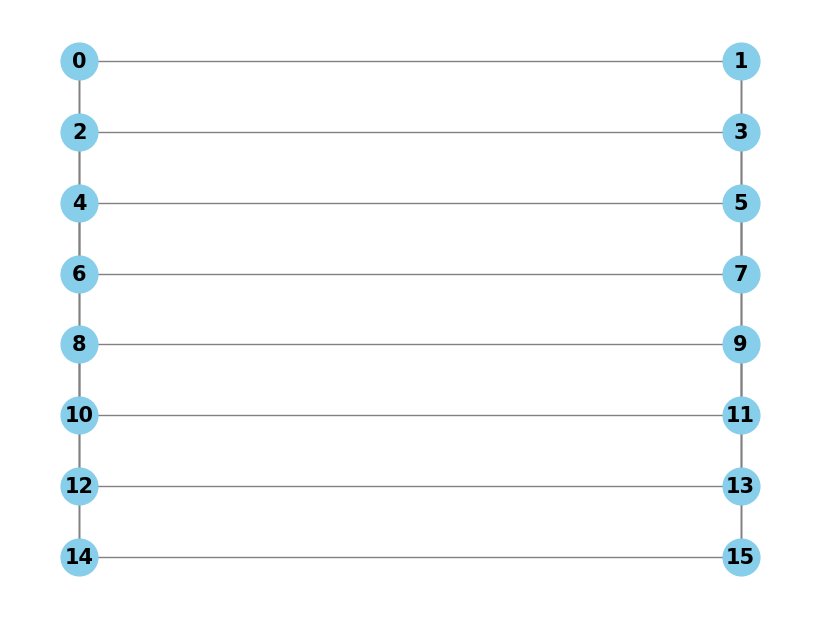

None


Matchings: 4
Matchings: [{('0001', '0011'), ('0100', '0110'), ('0000', '0010'), ('1000', '1010'), ('1101', '1111'), ('1001', '1011'), ('1100', '1110'), ('0101', '0111')}, {('0101', '1101'), ('0111', '1111'), ('0000', '1000'), ('0100', '1100'), ('0010', '1010'), ('0110', '1110'), ('0011', '1011'), ('0001', '1001')}, {('1110', '1111'), ('0010', '0011'), ('0110', '0111'), ('0100', '0101'), ('1010', '1011'), ('1100', '1101'), ('1000', '1001'), ('0000', '0001')}, {('0001', '0101'), ('1010', '1110'), ('0011', '0111'), ('1011', '1111'), ('0000', '0100'), ('1000', '1100'), ('1001', '1101'), ('0010', '0110')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 32, Edges = 32, Per Edge = 1.000

Sample Circuit - Matching (n_steps=1):


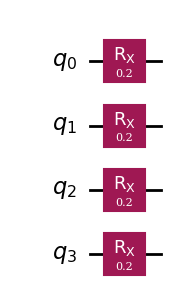


Gate Count Summary (U3/CX) for Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            4/0         4/0            4/0         4/0
       2            8/0         4/0            8/0         4/0
       5           20/0         4/0           20/0         4/0
      10           40/0         4/0           40/0         4/0
      20           80/0         4/0           80/0         4/0
      50          200/0         4/0          200/0         4/0
     100          400/0         4/0          400/0         4/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cayley_graph_of_z2_x_z2_x_z2_x_z2_4_qubits_error_analysis.pdf


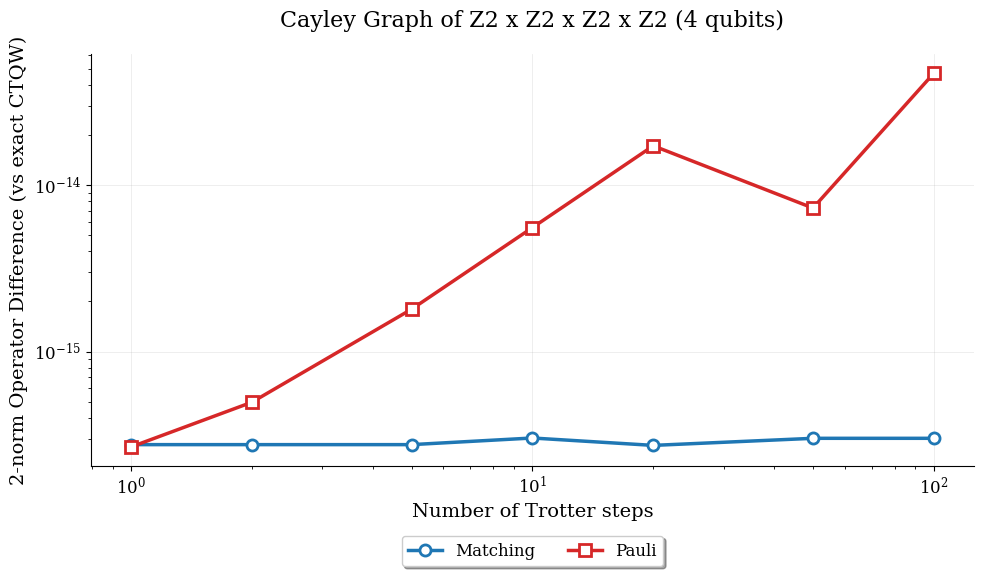

In [19]:
cayley_16 = set()
vertices_16 = [format(i, '04b') for i in range(16)]
generators_16 = ['0001', '0010', '0100', '1000']
for v in vertices_16:
    v_int = int(v, 2)
    for g in generators_16:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '04b')
        if v < neighbor:  # Avoid duplicates
            cayley_16.add((v, neighbor))
analyze_and_plot(cayley_16, "Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)")


Circulant Graph C8(1,2) (3 qubits)
Original edges: {('100', '110'), ('000', '001'), ('010', '100'), ('000', '010'), ('011', '100'), ('001', '010'), ('101', '111'), ('010', '011'), ('011', '101'), ('110', '111'), ('100', '101'), ('001', '011'), ('101', '110')}
Number of qubits: 3

Graph:


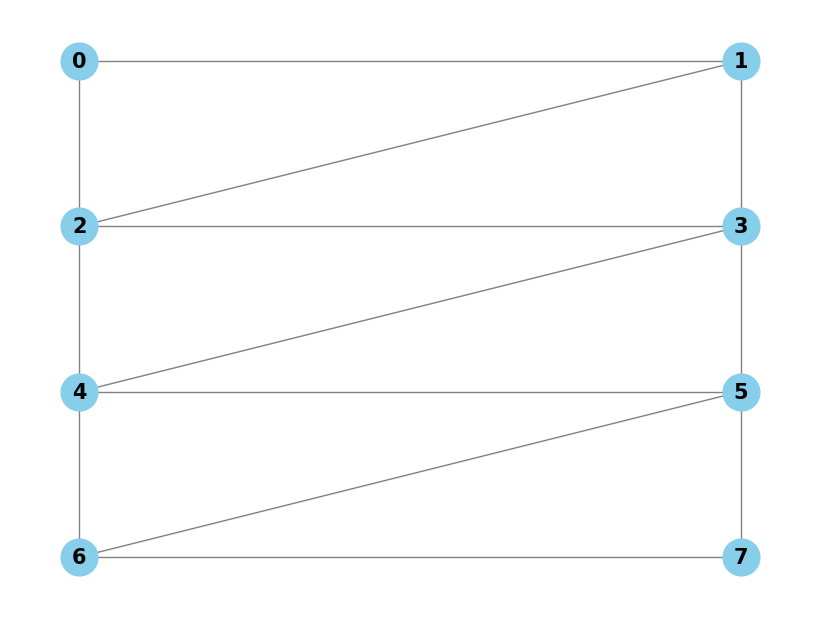

None


Matchings: 4
Matchings: [{('100', '110'), ('101', '111'), ('001', '011'), ('000', '010')}, {('100', '101'), ('000', '001'), ('110', '111'), ('010', '011')}, {('010', '100'), ('011', '101')}, {('011', '100'), ('001', '010'), ('101', '110')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 19, Edges = 13, Per Edge = 1.462

Sample Circuit - Matching (n_steps=1):


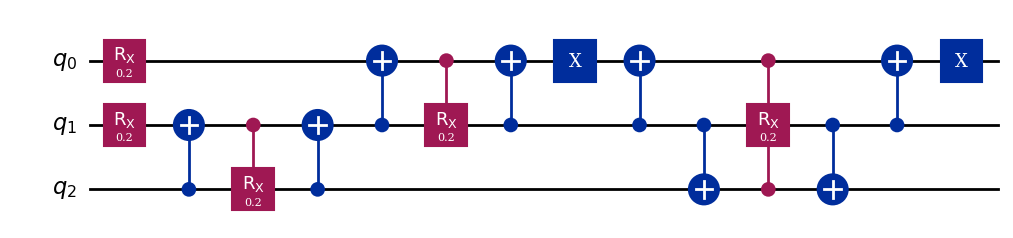


Gate Count Summary (U3/CX) for Circulant Graph C8(1,2) (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          25/20       20/14          50/24       27/16
       2          50/40       39/28         100/48       51/32
       5        125/100       96/70        250/120      119/80
      10        250/200     191/140        500/240     234/160
      20        500/400     381/280       1000/480     464/320
      50      1250/1000     951/700      2500/1200    1203/800
     100      2500/2000   1901/1400      5000/2400   2304/1600

Hamming cost/edge: 1.462
Error plot saved as: trotterization_plots/circulant_graph_c81,2_3_qubits_error_analysis.pdf


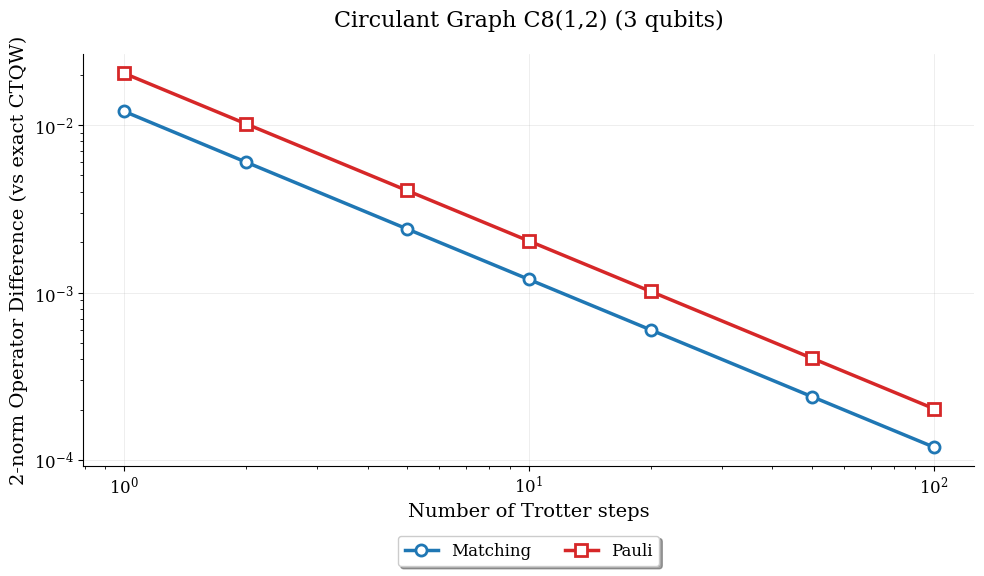

In [20]:
circulant_8 = set()
n = 8
offsets_8 = [1, 2]
for i in range(n):
    v = format(i, '03b')
    for offset in offsets_8:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '03b')
        if v < neighbor:  # Avoid duplicates
            circulant_8.add((v, neighbor))
analyze_and_plot(circulant_8, "Circulant Graph C8(1,2) (3 qubits)")


Circulant Graph C16(1,3,5) (4 qubits)
Original edges: {('0101', '0110'), ('0000', '0011'), ('1110', '1111'), ('0101', '1000'), ('0111', '1000'), ('1001', '1110'), ('1011', '1100'), ('0010', '0111'), ('0011', '0110'), ('0001', '0010'), ('0011', '1000'), ('0010', '0101'), ('0100', '1001'), ('1010', '1101'), ('0011', '0100'), ('1011', '1110'), ('1000', '1011'), ('0001', '0110'), ('1100', '1101'), ('0100', '0111'), ('0110', '1001'), ('1010', '1111'), ('0000', '0101'), ('0101', '1010'), ('0111', '1010'), ('0110', '0111'), ('0100', '0101'), ('0001', '0100'), ('1101', '1110'), ('1100', '1111'), ('1001', '1010'), ('0000', '0001'), ('0111', '1100'), ('0010', '0011'), ('1010', '1011'), ('1000', '1101'), ('0110', '1011'), ('1001', '1100'), ('1000', '1001')}
Number of qubits: 4

Graph:


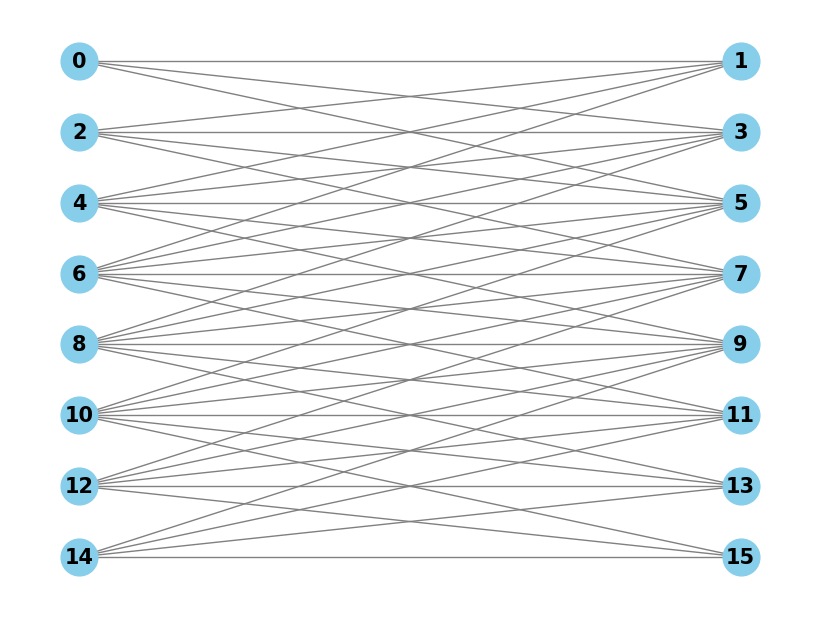

None


Matchings: 7
Matchings: [{('0101', '0110'), ('0000', '0011'), ('0001', '0010'), ('1010', '1101'), ('0111', '1000'), ('1001', '1110'), ('1011', '1100')}, {('1010', '1111'), ('0100', '1001'), ('0101', '1000'), ('1011', '1110'), ('0010', '0111'), ('0011', '0110')}, {('0011', '1000'), ('0010', '0101'), ('1101', '1110'), ('0001', '0110'), ('1100', '1111'), ('0100', '0111'), ('1001', '1010')}, {('0000', '0101'), ('0111', '1010'), ('0011', '0100'), ('1000', '1011'), ('0110', '1001')}, {('0111', '1100'), ('0101', '1010'), ('0001', '0100'), ('1000', '1101'), ('0110', '1011')}, {('1001', '1100')}, {('1110', '1111'), ('0010', '0011'), ('0110', '0111'), ('0100', '0101'), ('1010', '1011'), ('1100', '1101'), ('1000', '1001'), ('0000', '0001')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 88, Edges = 39, Per Edge = 2.256

Sample Circuit - Matching (n_steps=1):


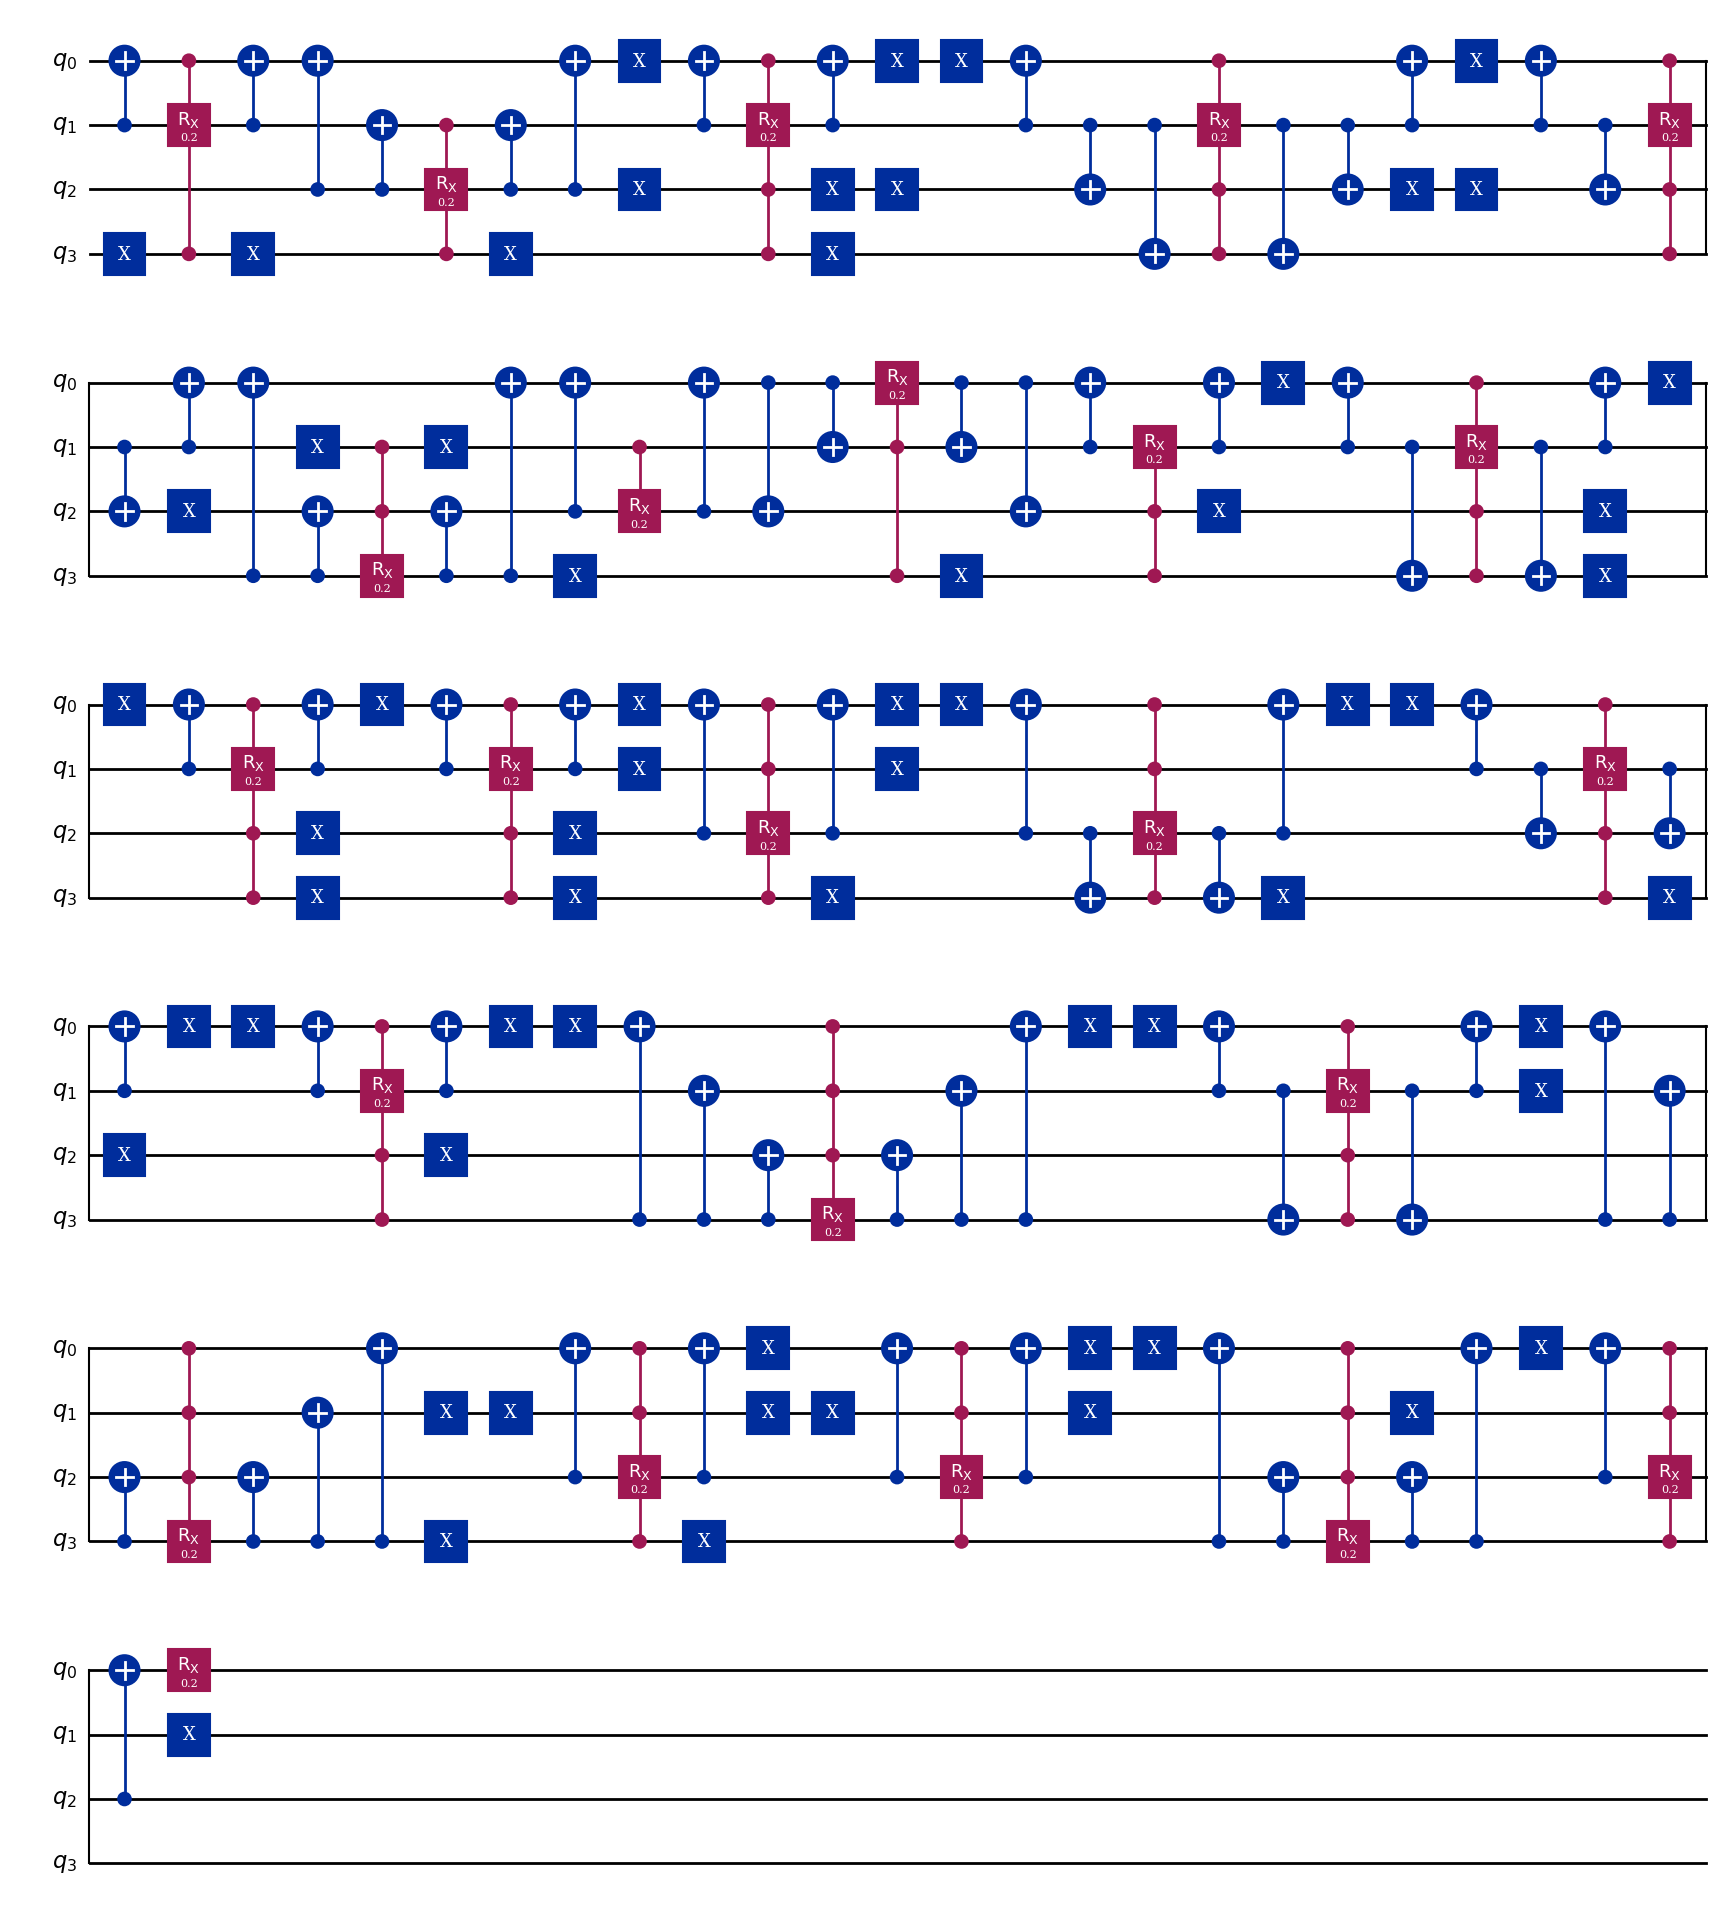


Gate Count Summary (U3/CX) for Circulant Graph C16(1,3,5) (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        736/458     368/423         153/92       90/70
       2       1472/916     736/846        306/184     176/140
       5      3680/2290   1840/2115        765/460     434/350
      10      7360/4580   3680/4230       1530/920     864/700
      20     14720/9160   7360/8460      3060/1840   1724/1400
      50    36800/22900 18400/21150      7650/4600   4304/3500
     100    73600/45800 36800/42300     15300/9200   8604/7000

Hamming cost/edge: 2.256
Error plot saved as: trotterization_plots/circulant_graph_c161,3,5_4_qubits_error_analysis.pdf


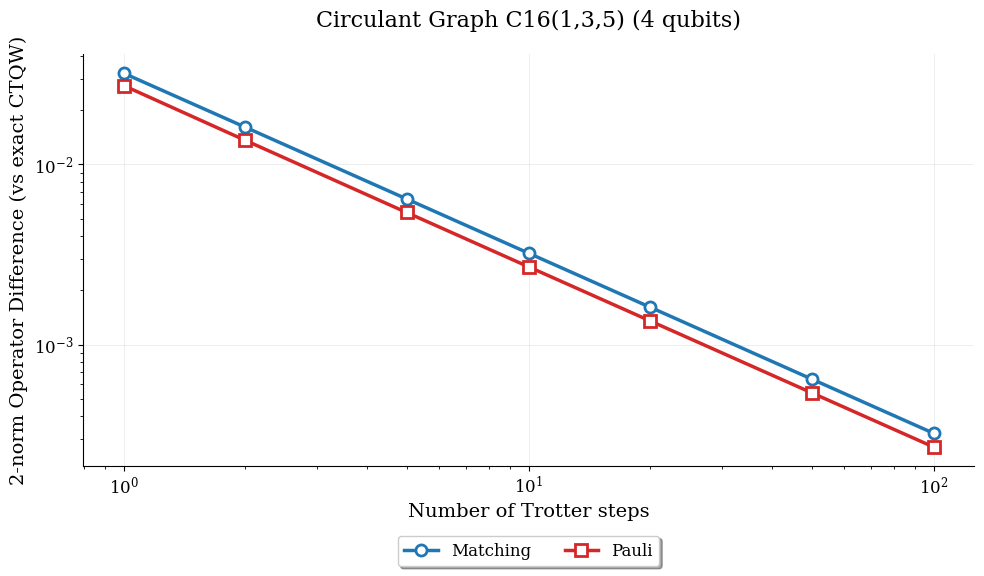

In [21]:
circulant_16 = set()
n = 16
offsets_16 = [1, 3, 5]
for i in range(n):
    v = format(i, '04b')
    for offset in offsets_16:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '04b')
        if v < neighbor:  # Avoid duplicates
            circulant_16.add((v, neighbor))
analyze_and_plot(circulant_16, "Circulant Graph C16(1,3,5) (4 qubits)")


Cayley Z2^5
Original edges: {('00111', '10111'), ('01010', '01011'), ('00110', '10110'), ('11001', '11101'), ('01001', '11001'), ('01010', '01110'), ('00011', '10011'), ('10001', '10011'), ('01001', '01101'), ('00000', '01000'), ('00000', '00100'), ('00110', '00111'), ('10110', '10111'), ('11000', '11001'), ('00011', '01011'), ('10111', '11111'), ('11010', '11011'), ('10100', '10110'), ('11000', '11100'), ('00001', '00101'), ('00100', '00110'), ('11010', '11110'), ('11100', '11110'), ('10011', '11011'), ('10000', '11000'), ('00101', '00111'), ('01011', '01111'), ('00100', '01100'), ('00100', '00101'), ('11001', '11011'), ('01111', '11111'), ('00100', '10100'), ('01100', '11100'), ('00111', '01111'), ('10000', '10010'), ('10100', '11100'), ('01110', '01111'), ('10101', '10111'), ('10100', '10101'), ('10001', '10101'), ('00001', '00011'), ('11000', '11010'), ('00010', '00011'), ('00101', '10101'), ('01101', '01111'), ('10010', '11010'), ('01001', '01011'), ('00011', '00111'), ('00000', 

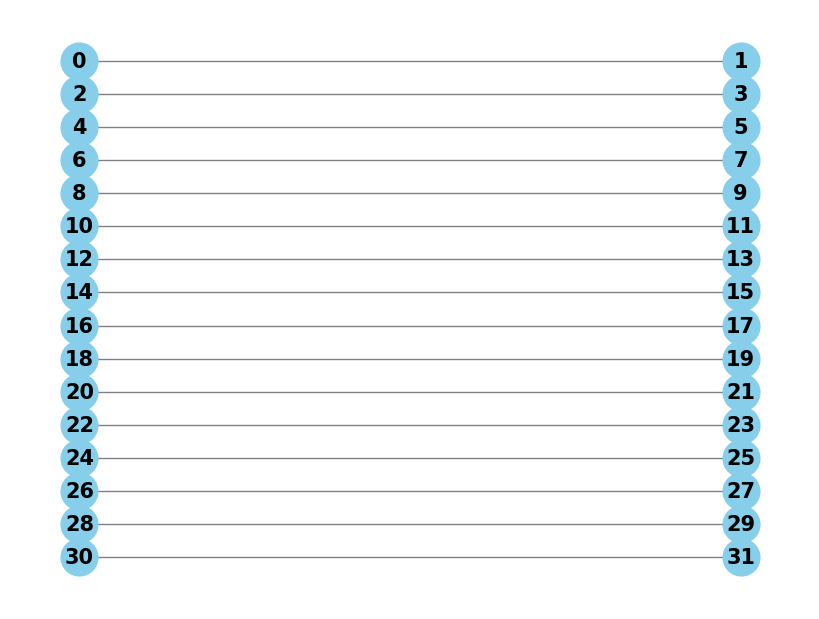

None


Matchings: 5
Matchings: [{('00111', '10111'), ('01001', '11001'), ('00001', '10001'), ('01111', '11111'), ('01000', '11000'), ('00010', '10010'), ('00101', '10101'), ('01101', '11101'), ('00100', '10100'), ('00110', '10110'), ('00011', '10011'), ('01100', '11100'), ('01010', '11010'), ('00000', '10000'), ('01110', '11110'), ('01011', '11011')}, {('00100', '00101'), ('11010', '11011'), ('01100', '01101'), ('10110', '10111'), ('00110', '00111'), ('01000', '01001'), ('11110', '11111'), ('01010', '01011'), ('01110', '01111'), ('00010', '00011'), ('10000', '10001'), ('10100', '10101'), ('00000', '00001'), ('11000', '11001'), ('11100', '11101'), ('10010', '10011')}, {('00011', '00111'), ('00000', '00100'), ('10011', '10111'), ('11000', '11100'), ('01010', '01110'), ('11010', '11110'), ('11011', '11111'), ('10000', '10100'), ('01001', '01101'), ('10001', '10101'), ('01000', '01100'), ('01011', '01111'), ('10010', '10110'), ('11001', '11101'), ('00010', '00110'), ('00001', '00101')}, {('01100

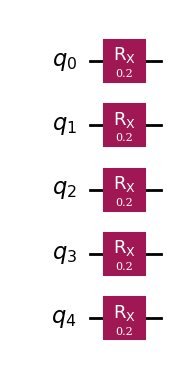


Gate Count Summary (U3/CX) for Cayley Z2^5:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            5/0         5/0            5/0         5/0
       2           10/0         5/0           10/0         5/0
       5           25/0         5/0           25/0         5/0
      10           50/0         5/0           50/0         5/0
      20          100/0         5/0          100/0         5/0
      50          250/0         5/0          250/0         5/0
     100          500/0         5/0          500/0         5/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cayley_z2^5_error_analysis.pdf


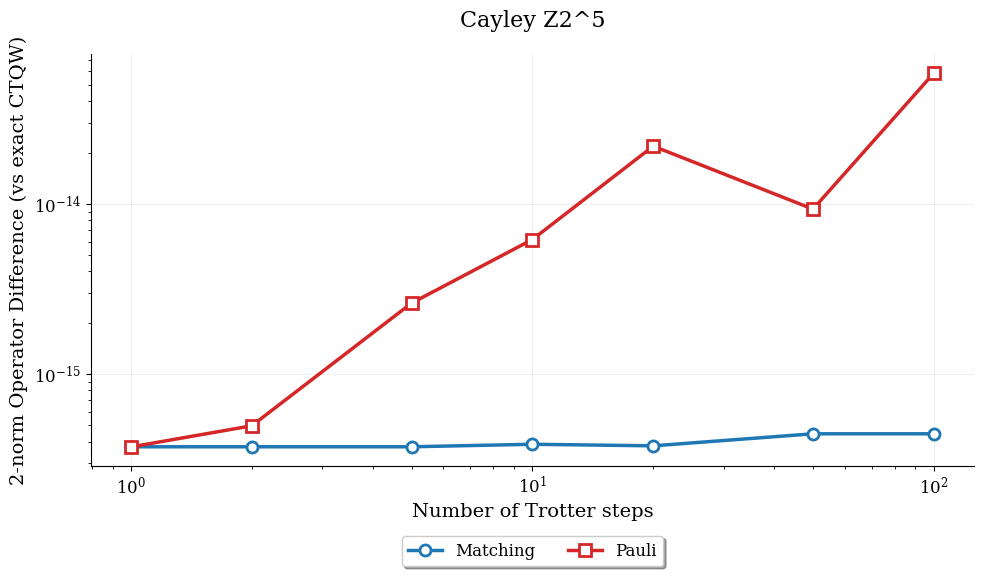

In [22]:
# 5 qubits: Cayley graph of Z2^5 with standard generators (bit flips)
cayley_edges = set()
for i in range(32):
    node_i = format(i, '05b')
    for bit_pos in range(5):
        j = i ^ (1 << bit_pos)  # XOR to flip bit
        node_j = format(j, '05b')
        if i < j:  # Avoid duplicates
            cayley_edges.add((node_i, node_j))

analyze_and_plot(cayley_edges, "Cayley Z2^5")


Circulant C32(1,2,5)
Original edges: {('01010', '01011'), ('00110', '01011'), ('10011', '11000'), ('01010', '01111'), ('11001', '11010'), ('10001', '10011'), ('00110', '00111'), ('10110', '10111'), ('10101', '10110'), ('01011', '01101'), ('01010', '01100'), ('11000', '11001'), ('11010', '11011'), ('10100', '10110'), ('00100', '01001'), ('00001', '00010'), ('01100', '10001'), ('01000', '01101'), ('00110', '01000'), ('00100', '00110'), ('11100', '11110'), ('00101', '00110'), ('00000', '00101'), ('10010', '10111'), ('11011', '11100'), ('11010', '11100'), ('01110', '10011'), ('00101', '00111'), ('01001', '01110'), ('10011', '10100'), ('00100', '00101'), ('11001', '11011'), ('11010', '11111'), ('10110', '11000'), ('10001', '10010'), ('10000', '10010'), ('01011', '10000'), ('10111', '11000'), ('10101', '10111'), ('01110', '01111'), ('10011', '10101'), ('10001', '10110'), ('11001', '11110'), ('10100', '10101'), ('00001', '00011'), ('11000', '11101'), ('01011', '01100'), ('11000', '11010'), (

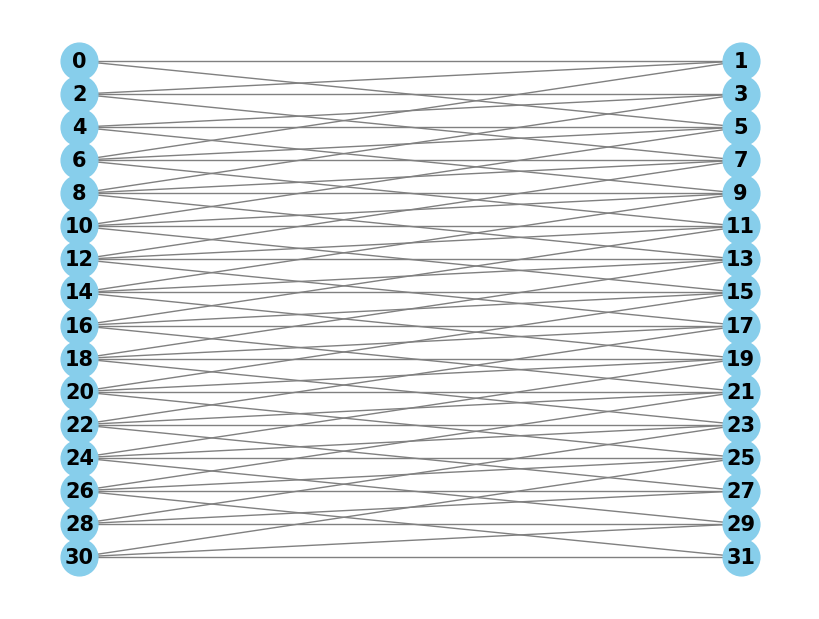

None


Matchings: 7
Matchings: [{('00100', '00101'), ('11010', '11011'), ('01100', '01101'), ('10110', '10111'), ('00110', '00111'), ('01000', '01001'), ('11110', '11111'), ('01010', '01011'), ('01110', '01111'), ('00010', '00011'), ('10000', '10001'), ('10100', '10101'), ('00000', '00001'), ('11000', '11001'), ('11100', '11101'), ('10010', '10011')}, {('11011', '11100'), ('11001', '11010'), ('00001', '00010'), ('01100', '10001'), ('10101', '10110'), ('00100', '01001'), ('01000', '01101'), ('00110', '01011'), ('01110', '10000'), ('10011', '11000'), ('01010', '01111'), ('00000', '00101'), ('11101', '11110'), ('10010', '10111')}, {('11010', '11100'), ('00110', '01000'), ('01111', '10100'), ('01011', '01101'), ('01110', '10011'), ('10110', '11000'), ('11001', '11110'), ('00111', '01001'), ('01010', '01100'), ('10001', '10010'), ('00011', '00101'), ('11011', '11101'), ('00010', '00100'), ('10000', '10101')}, {('10111', '11000'), ('00111', '01100'), ('00011', '01000'), ('11010', '11111'), ('10001

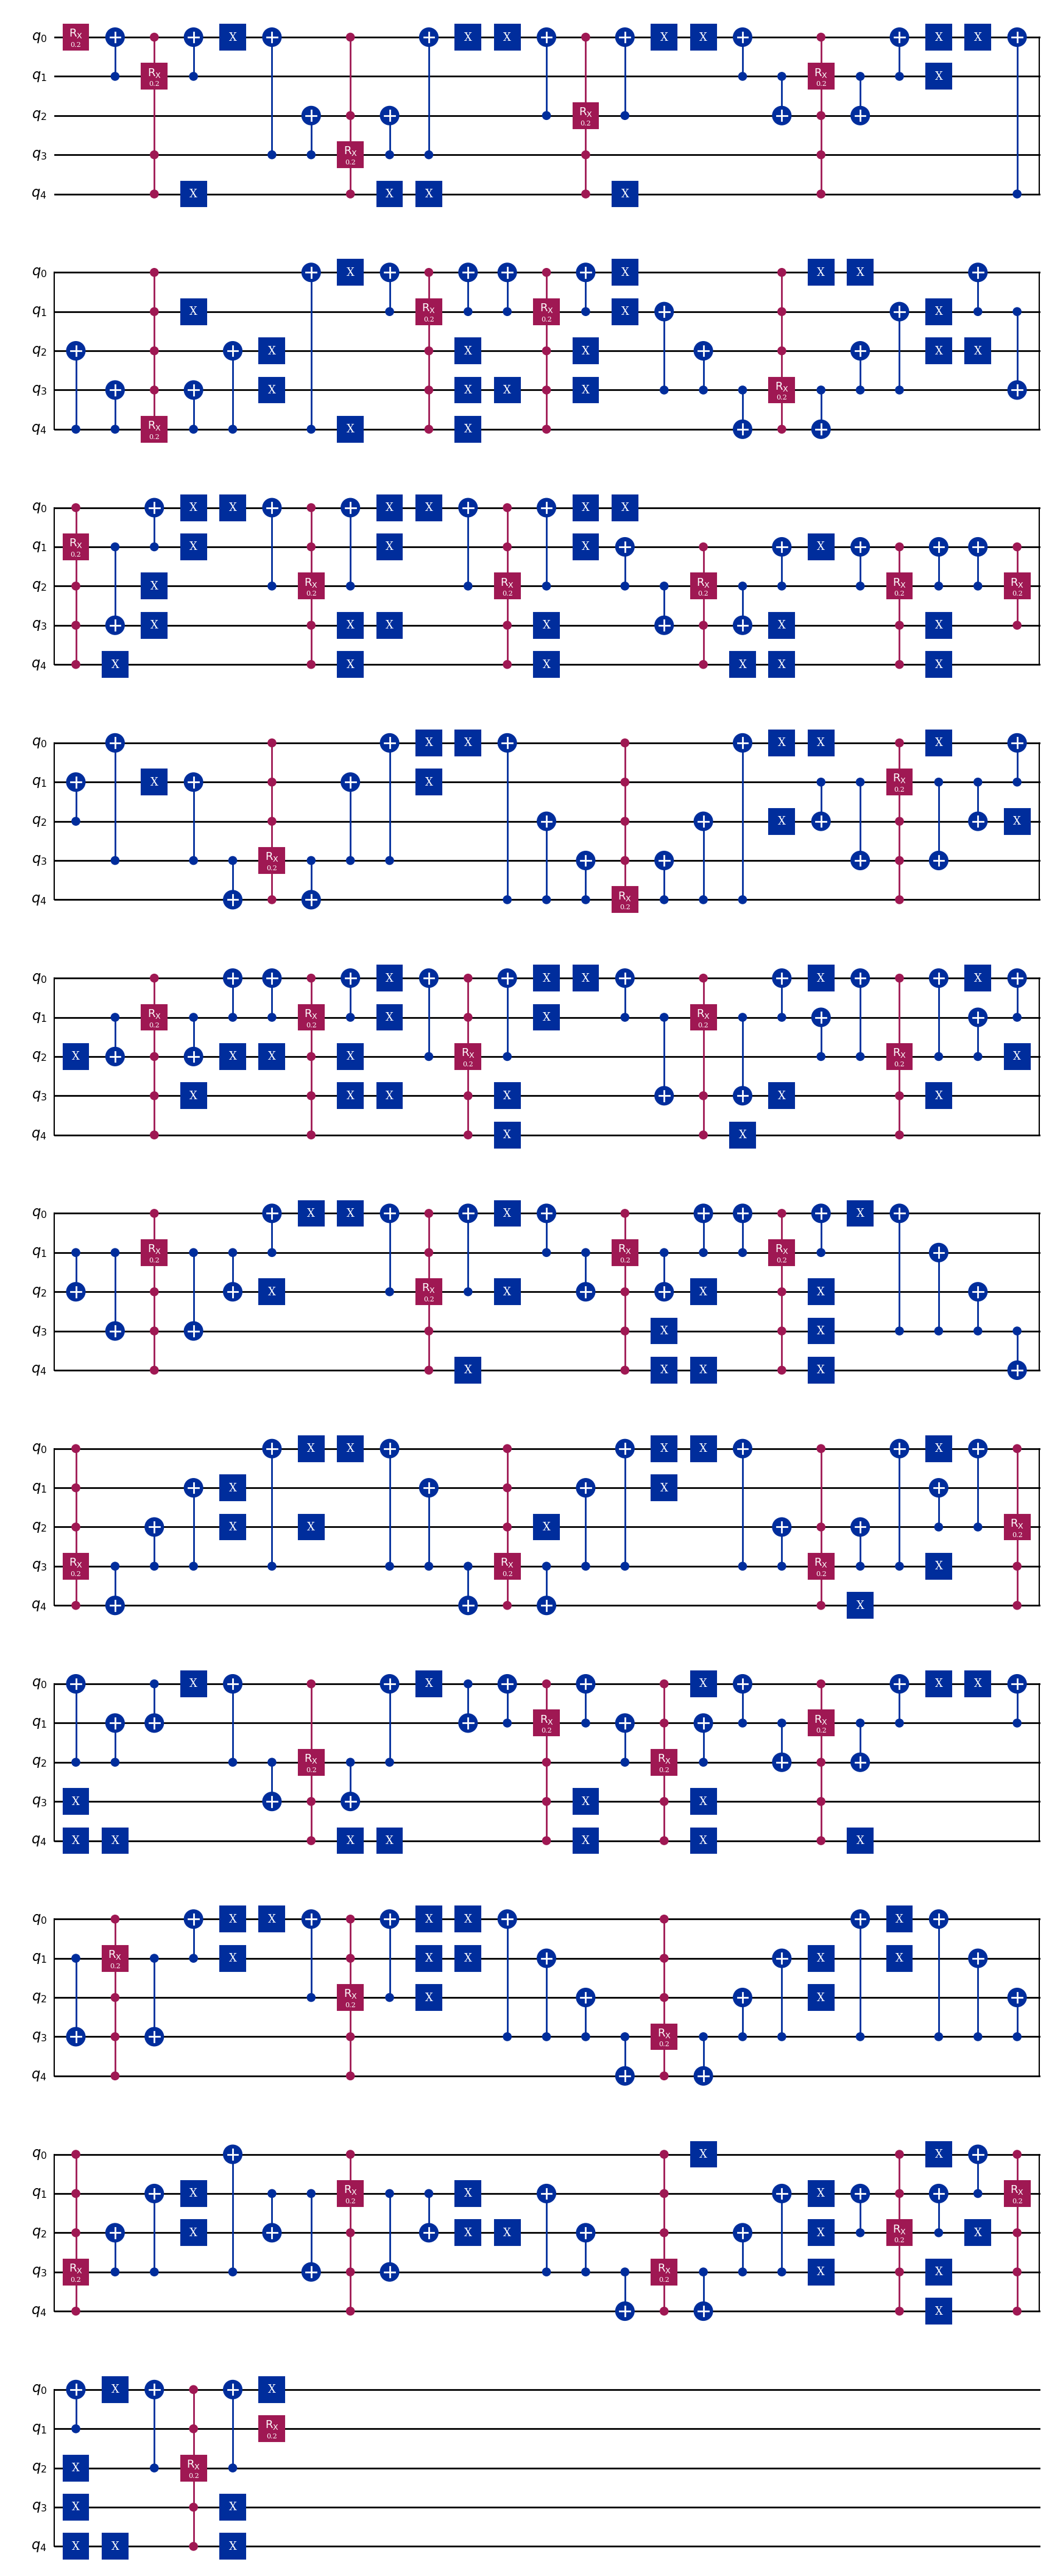


Gate Count Summary (U3/CX) for Circulant C32(1,2,5):
 n_steps Match (No Opt)   Match (Opt) Pauli (No Opt) Pauli (Opt)
       1      1867/1138     1086/1101        470/300     192/152
       2      3734/2276     2171/2202        940/600     379/304
       5      9335/5690     5426/5505      2350/1500     940/760
      10    18670/11380   10851/11010      4700/3000   1875/1520
      20    37340/22760   21701/22020      9400/6000   3745/3040
      50    93350/56900   54251/55050    23500/15000   9355/7600
     100  186700/113800 108501/110100    47000/30000 18705/15200

Hamming cost/edge: 2.159
Error plot saved as: trotterization_plots/circulant_c321,2,5_error_analysis.pdf


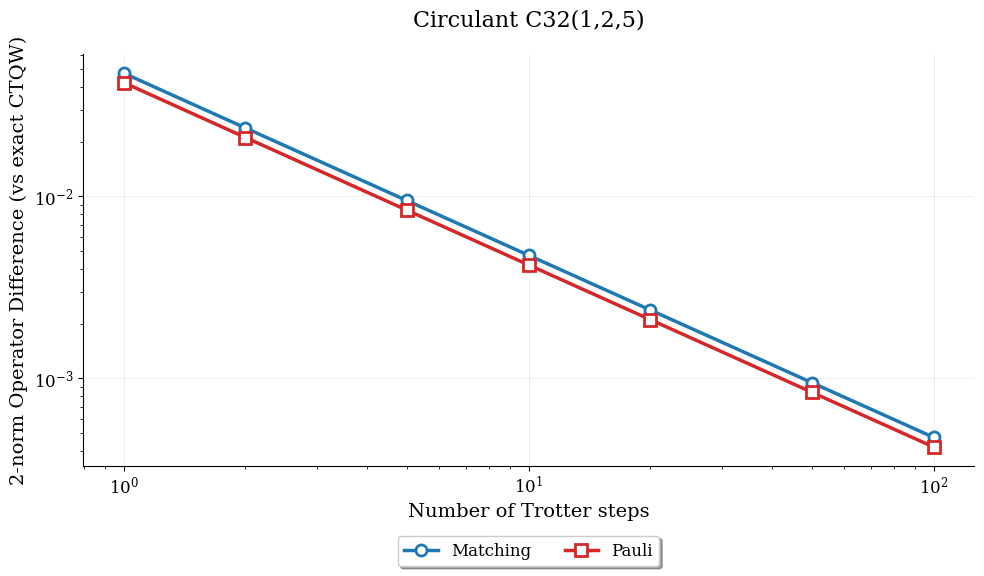

In [23]:
# 5 qubits: Circulant graph C32(1,2,5)
circ_edges = set()
offsets = [1, 2, 5]
for i in range(32):
    node_i = format(i, '05b')
    for offset in offsets:
        j = (i + offset) % 32
        node_j = format(j, '05b')
        if i < j:  # Avoid duplicates (circulant is symmetric)
            circ_edges.add((node_i, node_j))

analyze_and_plot(circ_edges, "Circulant C32(1,2,5)")


Path P32
Original edges: {('00001', '00010'), ('01010', '01011'), ('00010', '00011'), ('00101', '00110'), ('00000', '00001'), ('11011', '11100'), ('11001', '11010'), ('01101', '01110'), ('10000', '10001'), ('10011', '10100'), ('01111', '10000'), ('11101', '11110'), ('11100', '11101'), ('10010', '10011'), ('00100', '00101'), ('00110', '00111'), ('10110', '10111'), ('10101', '10110'), ('11110', '11111'), ('01001', '01010'), ('10001', '10010'), ('00111', '01000'), ('11000', '11001'), ('10111', '11000'), ('11010', '11011'), ('01100', '01101'), ('01000', '01001'), ('00011', '00100'), ('01110', '01111'), ('10100', '10101'), ('01011', '01100')}
Number of qubits: 5

Graph:


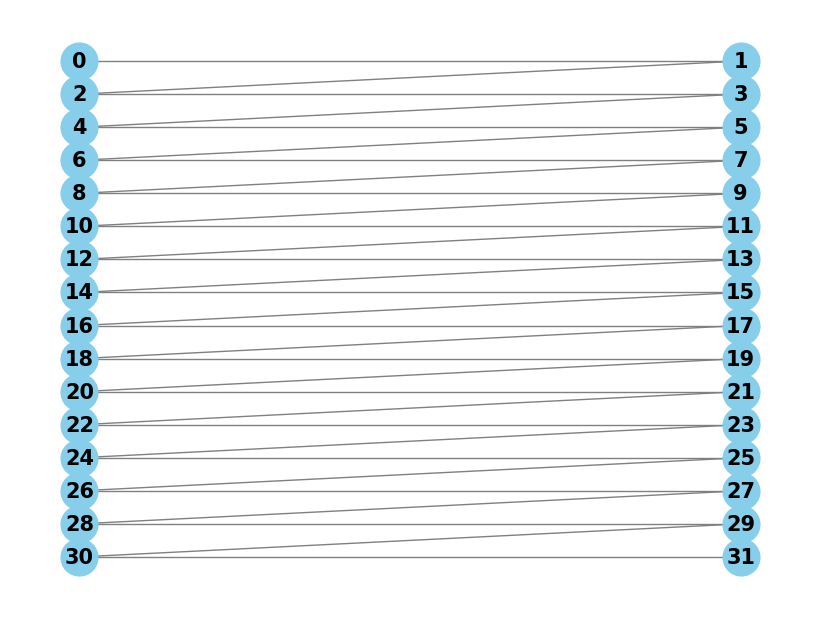

None


Matchings: 2
Matchings: [{('11011', '11100'), ('10111', '11000'), ('11001', '11010'), ('11101', '11110'), ('01101', '01110'), ('00001', '00010'), ('10101', '10110'), ('00011', '00100'), ('01001', '01010'), ('01011', '01100'), ('10011', '10100'), ('00101', '00110'), ('10001', '10010'), ('01111', '10000'), ('00111', '01000')}, {('00100', '00101'), ('11010', '11011'), ('01100', '01101'), ('00110', '00111'), ('10110', '10111'), ('11110', '11111'), ('01000', '01001'), ('01010', '01011'), ('01110', '01111'), ('00010', '00011'), ('10000', '10001'), ('10100', '10101'), ('00000', '00001'), ('11000', '11001'), ('11100', '11101'), ('10010', '10011')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 57, Edges = 31, Per Edge = 1.839

Sample Circuit - Matching (n_steps=1):


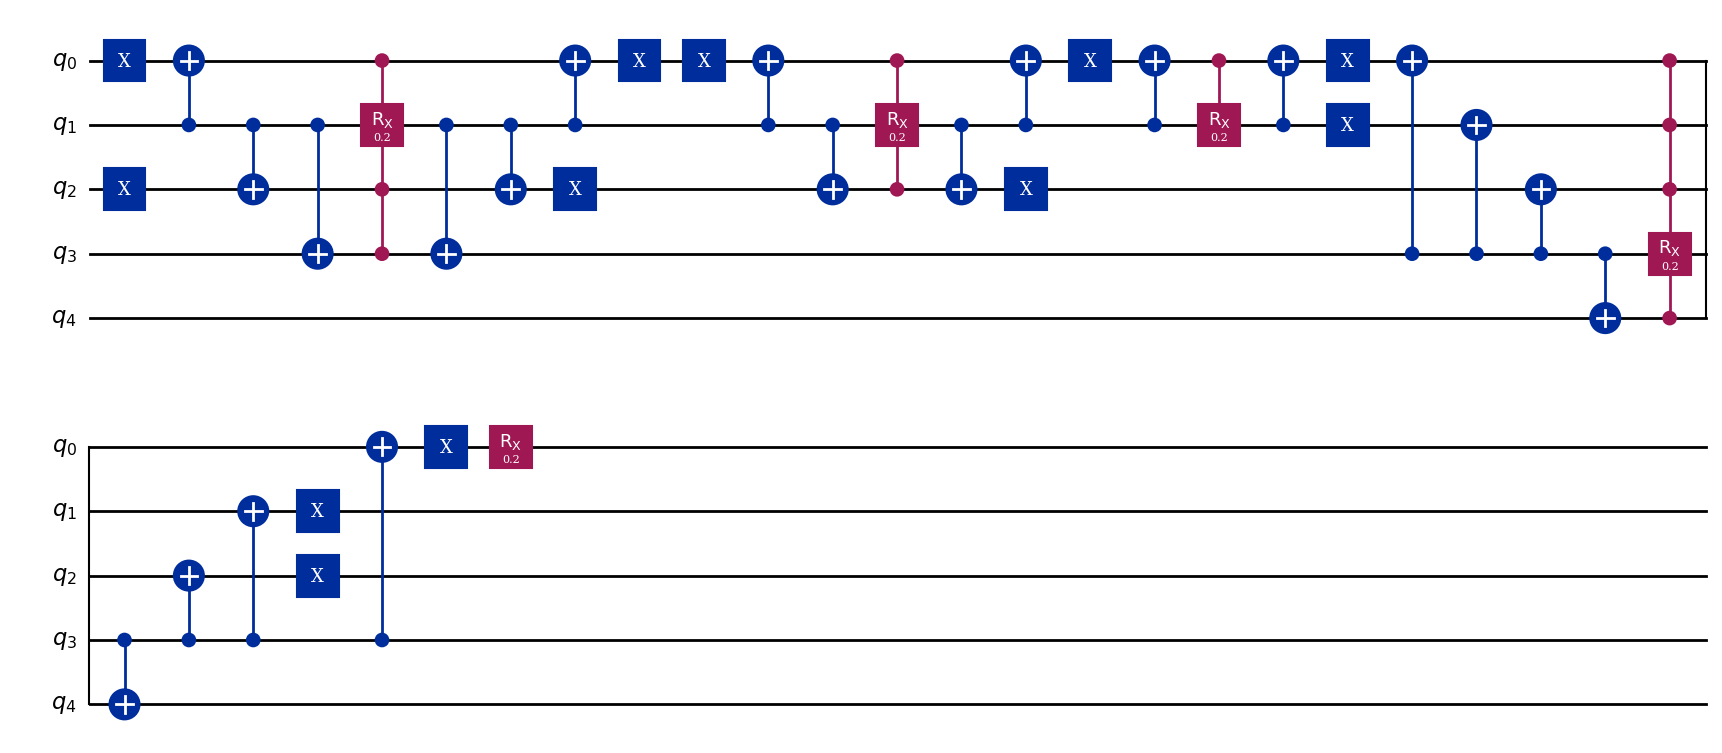


Gate Count Summary (U3/CX) for Path P32:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         108/74       64/66        287/196     172/124
       2        216/148     125/132        574/392     339/248
       5        540/370     308/330       1435/980     840/620
      10       1080/740     613/660      2870/1960   1675/1240
      20      2160/1480   1223/1320      5740/3920   3345/2480
      50      5400/3700   3053/3300     14350/9800   8355/6200
     100     10800/7400   6103/6600    28700/19600 16705/12400

Hamming cost/edge: 1.839
Error plot saved as: trotterization_plots/path_p32_error_analysis.pdf


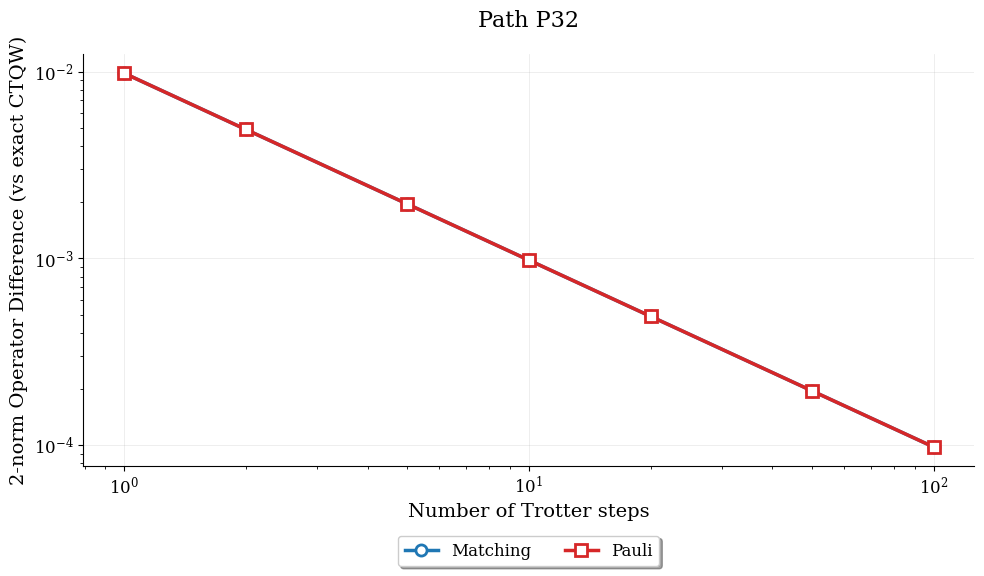

In [24]:
# 5 qubits: Path graph P32
path_edges = set()
for i in range(31):
    node_i = format(i, '05b')
    node_j = format(i+1, '05b')
    path_edges.add((node_i, node_j))

analyze_and_plot(path_edges, "Path P32")


Cycle C32
Original edges: {('00001', '00010'), ('01010', '01011'), ('00010', '00011'), ('00101', '00110'), ('00000', '00001'), ('11011', '11100'), ('11001', '11010'), ('01101', '01110'), ('10000', '10001'), ('11111', '00000'), ('10011', '10100'), ('01111', '10000'), ('11101', '11110'), ('11100', '11101'), ('10010', '10011'), ('00100', '00101'), ('00110', '00111'), ('10110', '10111'), ('10101', '10110'), ('11110', '11111'), ('01001', '01010'), ('10001', '10010'), ('00111', '01000'), ('11000', '11001'), ('10111', '11000'), ('11010', '11011'), ('01100', '01101'), ('01000', '01001'), ('00011', '00100'), ('01110', '01111'), ('10100', '10101'), ('01011', '01100')}
Number of qubits: 5

Graph:


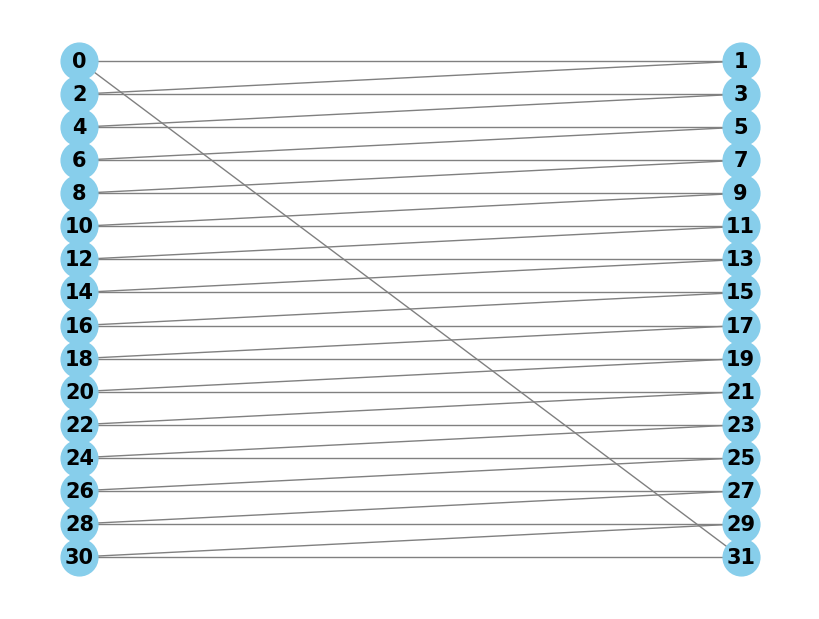

None


Matchings: 2
Matchings: [{('11011', '11100'), ('10111', '11000'), ('11001', '11010'), ('11101', '11110'), ('01101', '01110'), ('00001', '00010'), ('10101', '10110'), ('00011', '00100'), ('01001', '01010'), ('01011', '01100'), ('11111', '00000'), ('10011', '10100'), ('00101', '00110'), ('10001', '10010'), ('01111', '10000'), ('00111', '01000')}, {('00100', '00101'), ('11010', '11011'), ('01100', '01101'), ('00110', '00111'), ('10110', '10111'), ('11110', '11111'), ('01000', '01001'), ('01010', '01011'), ('01110', '01111'), ('00010', '00011'), ('10000', '10001'), ('10100', '10101'), ('00000', '00001'), ('11000', '11001'), ('11100', '11101'), ('10010', '10011')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 62, Edges = 32, Per Edge = 1.938

Sample Circuit - Matching (n_steps=1):


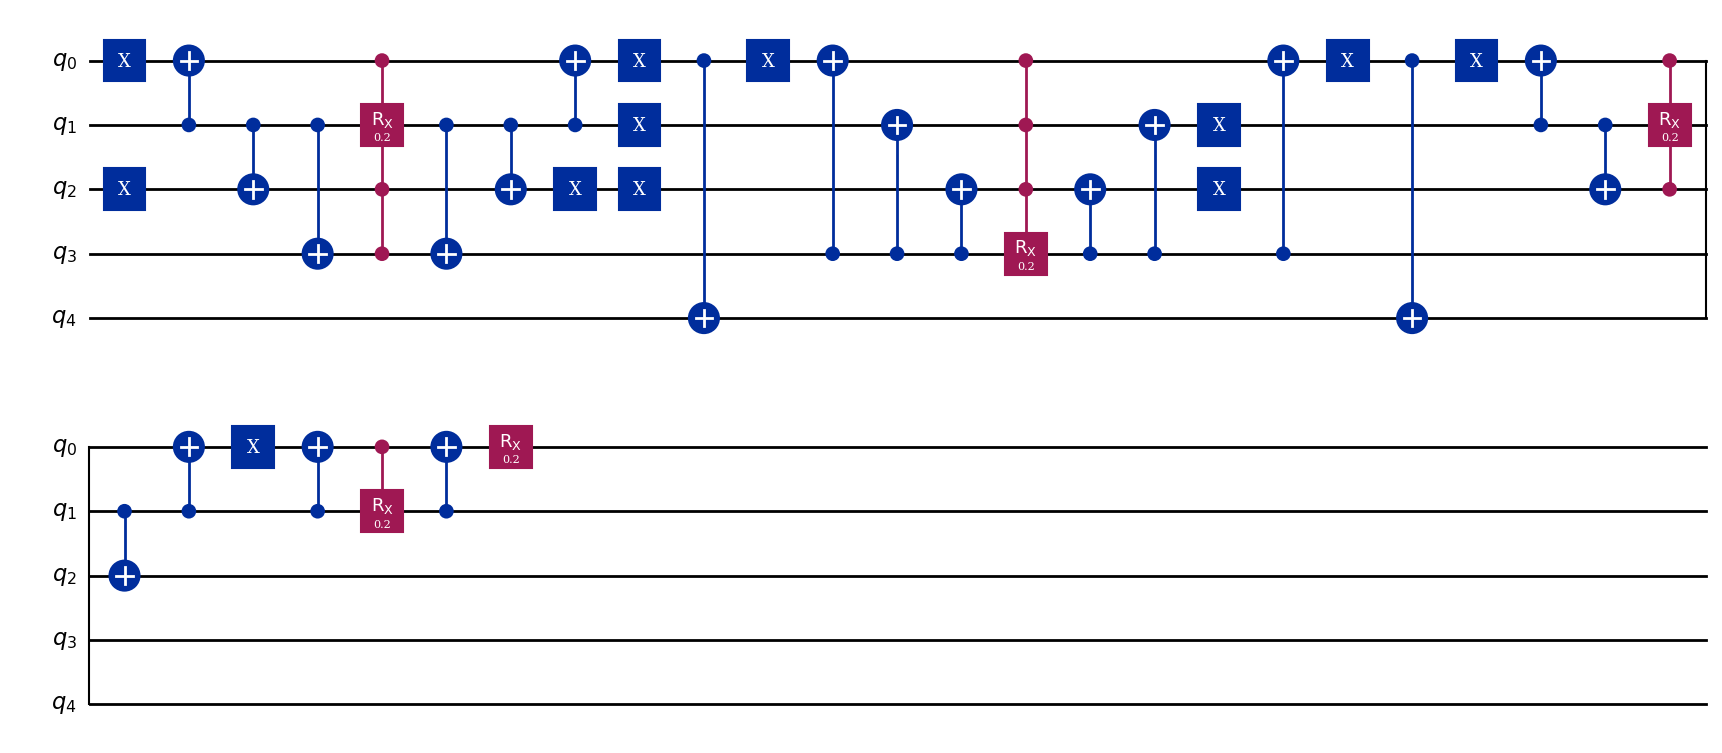


Gate Count Summary (U3/CX) for Cycle C32:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         101/70       60/64        199/132      123/87
       2        202/140     118/127        398/264     240/174
       5        505/350     292/316        995/660     591/435
      10       1010/700     582/631      1990/1320    1176/870
      20      2020/1400   1162/1261      3980/2640   2346/1740
      50      5050/3500   2902/3151      9950/6600   5856/4350
     100     10100/7000   5802/6301    19900/13200  11706/8700

Hamming cost/edge: 1.938
Error plot saved as: trotterization_plots/cycle_c32_error_analysis.pdf


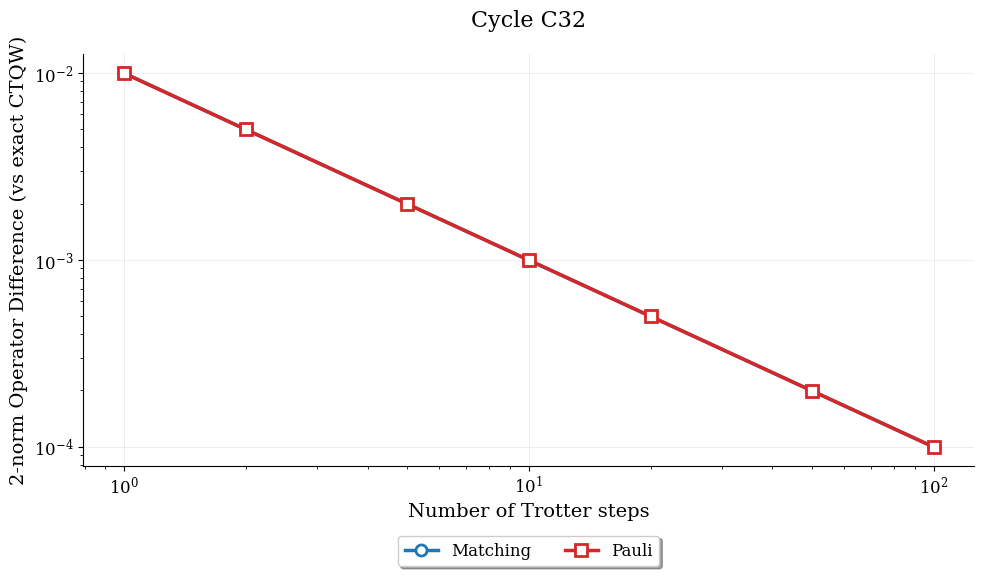

In [25]:
# 5 qubits: Cycle graph C32
cycle_edges = set()
for i in range(32):
    node_i = format(i, '05b')
    j = (i + 1) % 32
    node_j = format(j, '05b')
    if i < j or (i == 31 and j == 0):  # Handle wraparound
        cycle_edges.add((node_i, node_j))

analyze_and_plot(cycle_edges, "Cycle C32")


Star S32
Original edges: {('00000', '01100'), ('00000', '10011'), ('00000', '11011'), ('00000', '00011'), ('00000', '00101'), ('00000', '00001'), ('00000', '10100'), ('00000', '00010'), ('00000', '10010'), ('00000', '11110'), ('00000', '01011'), ('00000', '01001'), ('00000', '01000'), ('00000', '00100'), ('00000', '11001'), ('00000', '01111'), ('00000', '10110'), ('00000', '11100'), ('00000', '10101'), ('00000', '01101'), ('00000', '00110'), ('00000', '01110'), ('00000', '11101'), ('00000', '11010'), ('00000', '10111'), ('00000', '10000'), ('00000', '01010'), ('00000', '00111'), ('00000', '11111'), ('00000', '11000'), ('00000', '10001')}
Number of qubits: 5

Graph:


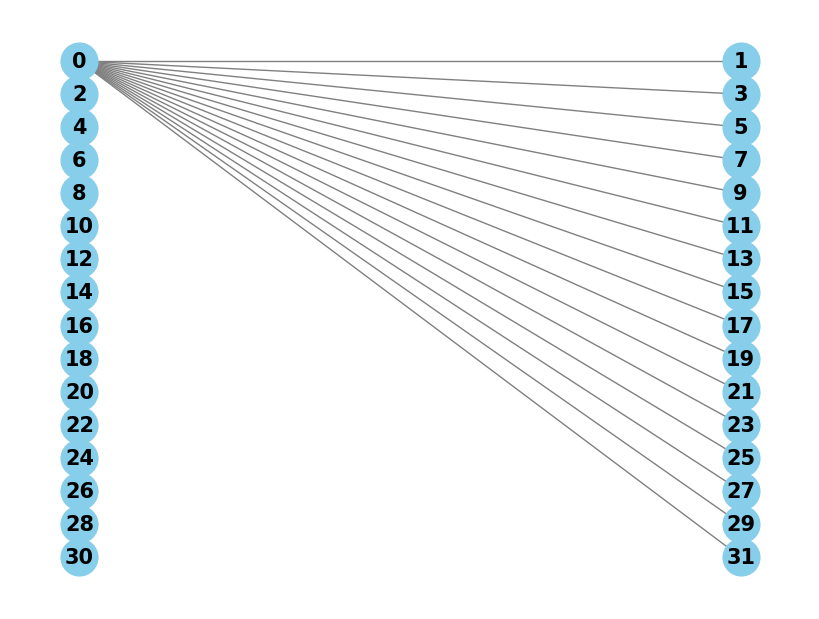

None


Matchings: 31
Matchings: [{('00000', '01100')}, {('00000', '10011')}, {('00000', '11011')}, {('00000', '00011')}, {('00000', '00101')}, {('00000', '10100')}, {('00000', '10010')}, {('00000', '11110')}, {('00000', '01011')}, {('00000', '01001')}, {('00000', '11001')}, {('00000', '01111')}, {('00000', '10110')}, {('00000', '11100')}, {('00000', '10101')}, {('00000', '01101')}, {('00000', '00110')}, {('00000', '01110')}, {('00000', '11101')}, {('00000', '11010')}, {('00000', '10111')}, {('00000', '01010')}, {('00000', '00111')}, {('00000', '11111')}, {('00000', '11000')}, {('00000', '10001')}, {('00000', '00001')}, {('00000', '00010')}, {('00000', '01000')}, {('00000', '00100')}, {('00000', '10000')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 80, Edges = 31, Per Edge = 2.581

Sample Circuit - Matching (n_steps=1):


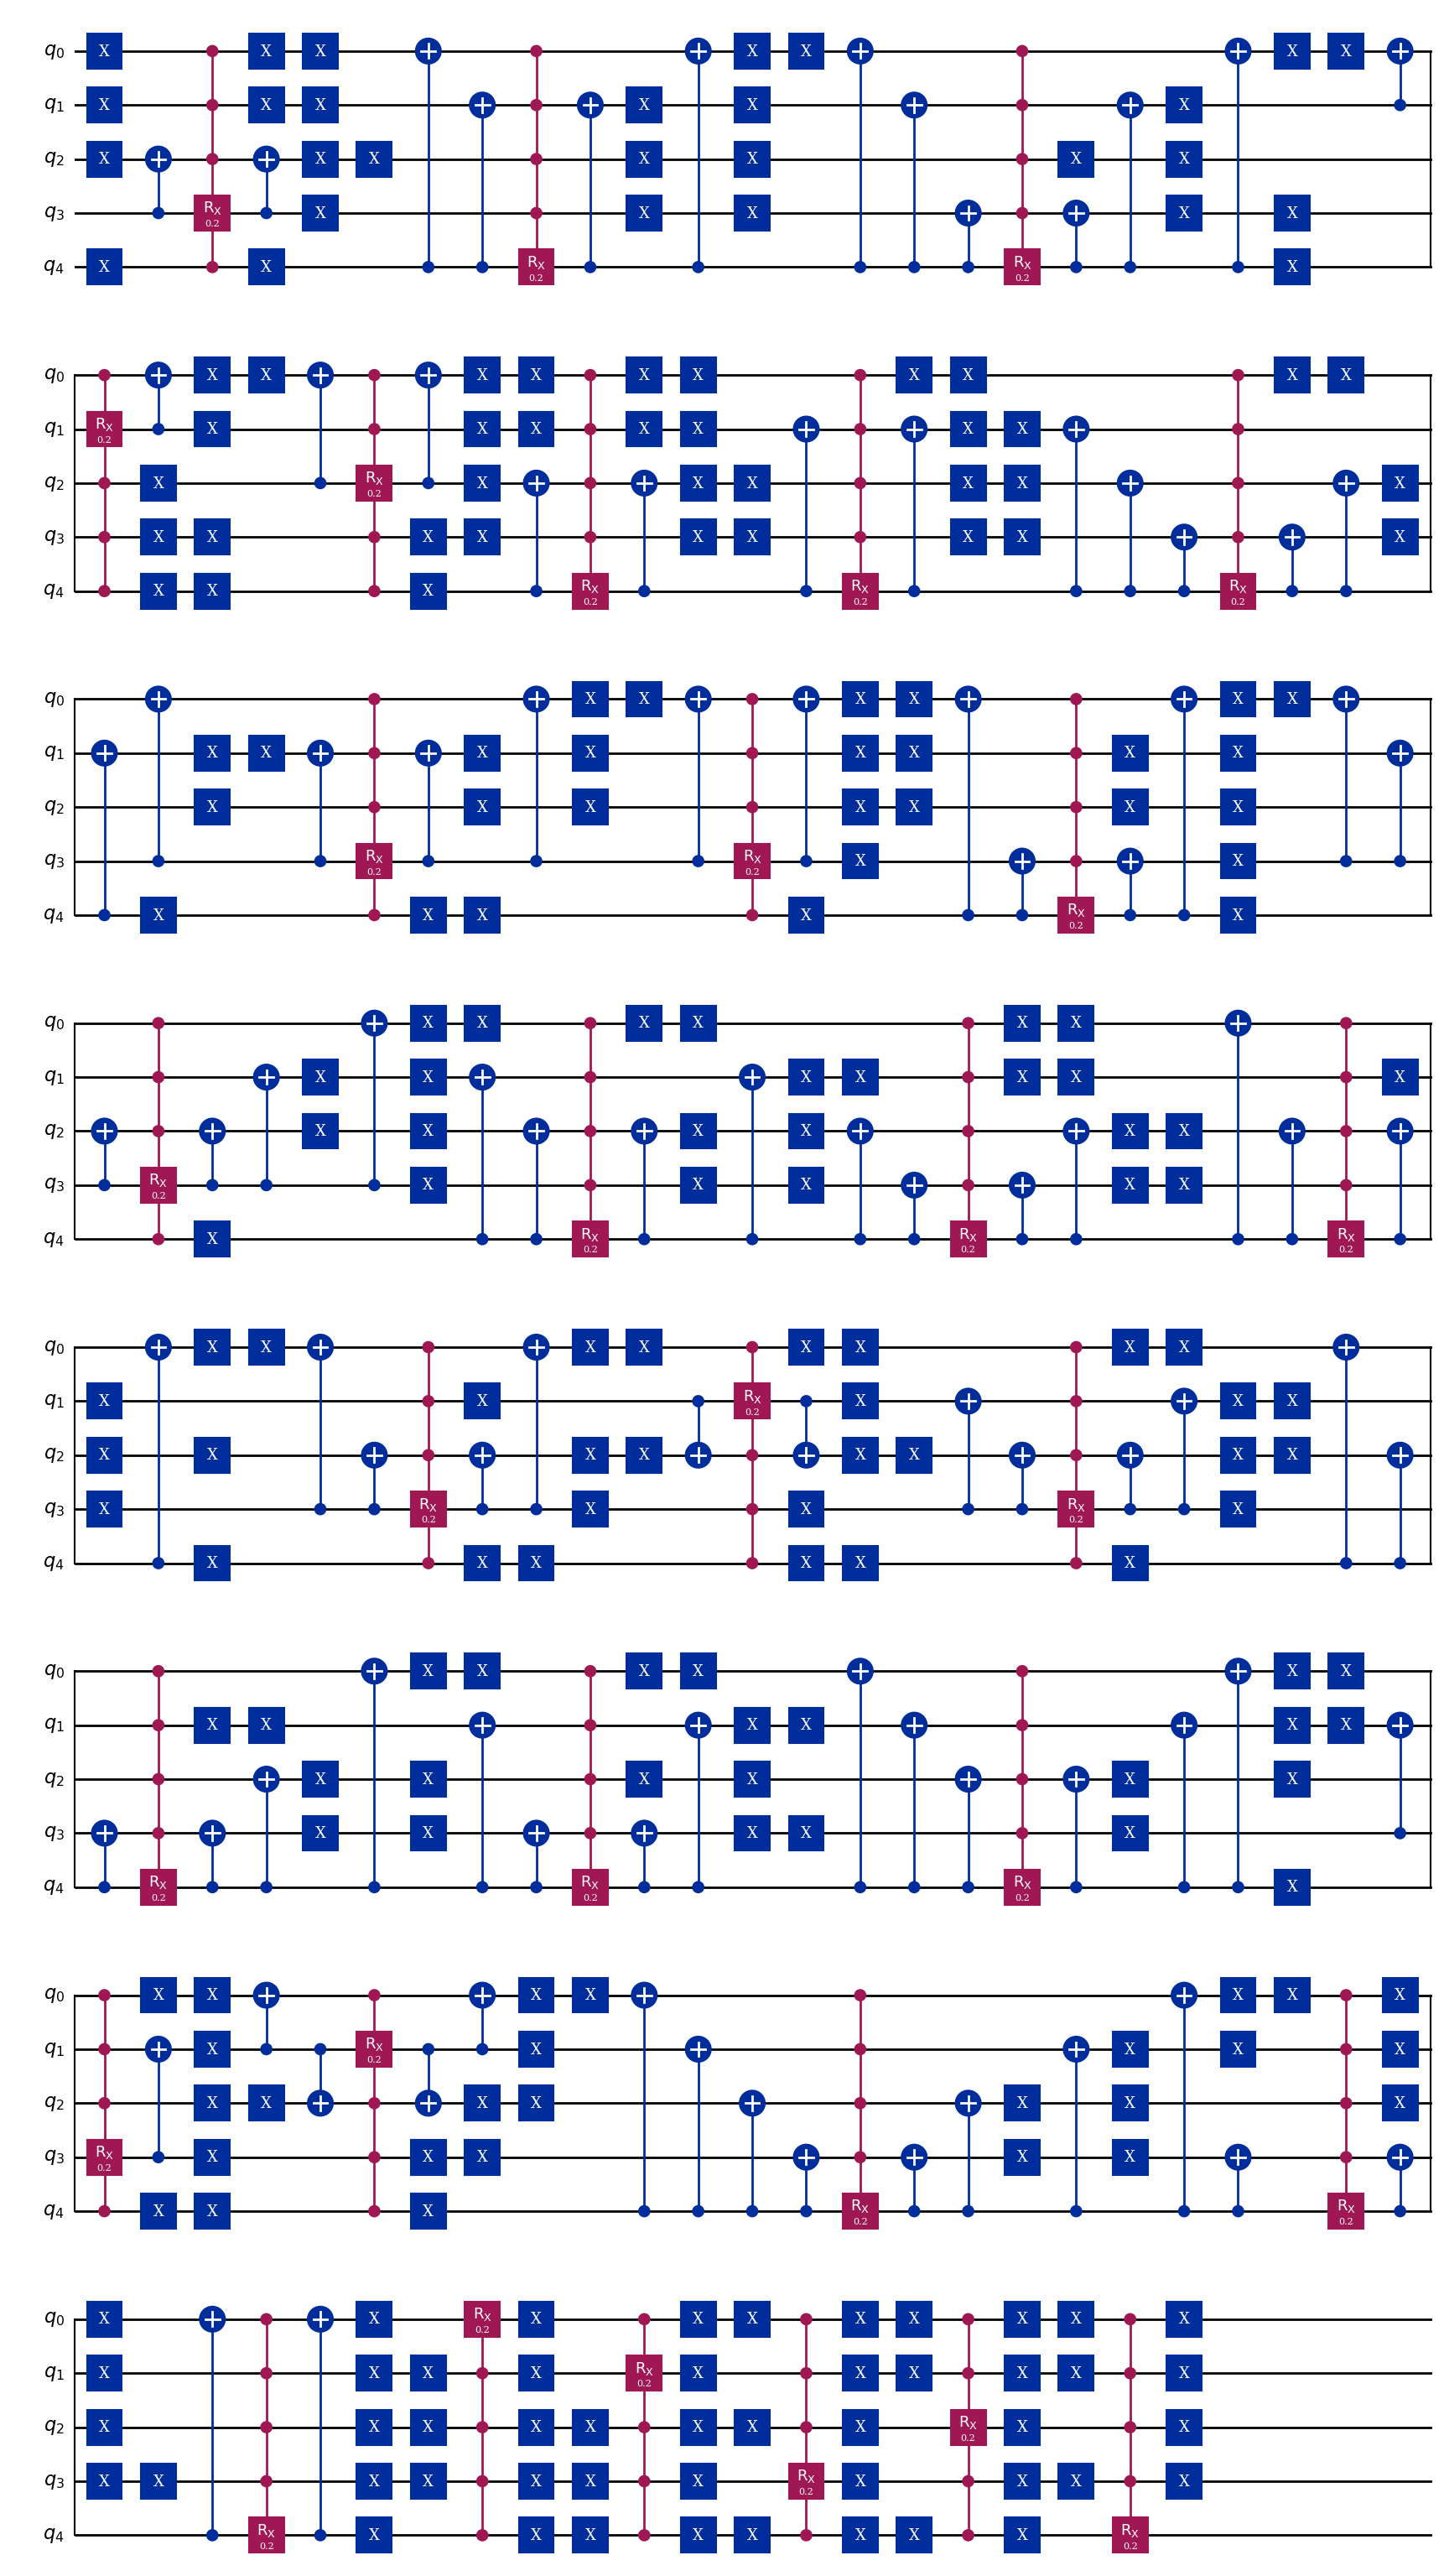


Gate Count Summary (U3/CX) for Star S32:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt)  Pauli (Opt)
       1       1550/842     832/822      3046/2768     1057/624
       2      3100/1684   1658/1642      6092/5536    2125/1248
       5      7750/4210   4136/4102    15230/13840    5296/3120
      10     15500/8420   8266/8202    30460/27680   10531/6240
      20    31000/16840 16526/16402    60920/55360  21301/12480
      50    77500/42100 41306/41002  152300/138400  52651/31200
     100   155000/84200 82606/82002  304600/276800 105301/62400

Hamming cost/edge: 2.581
Error plot saved as: trotterization_plots/star_s32_error_analysis.pdf


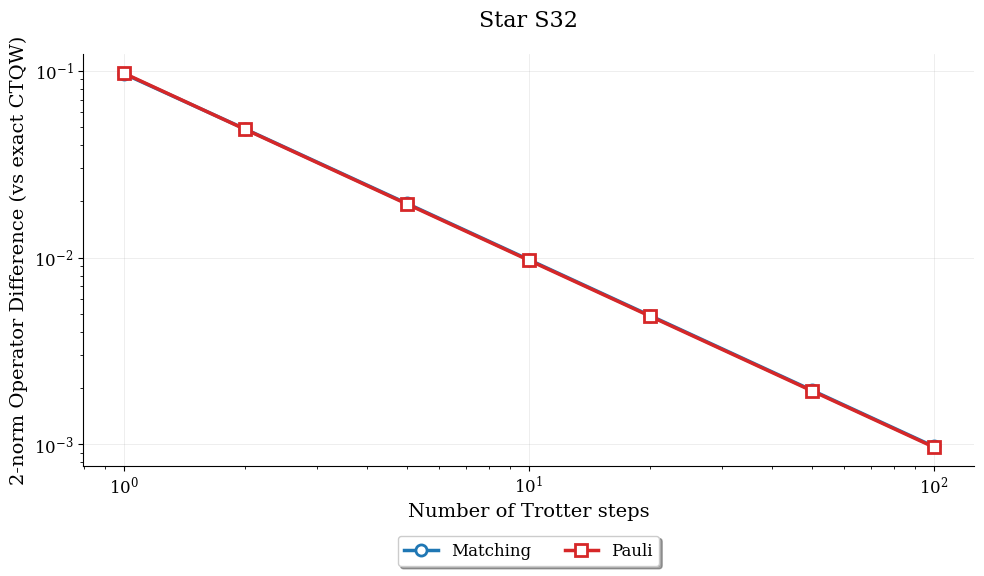

In [26]:
# 5 qubits: Star graph (node 0 connected to all others)
star_edges = set()
node_0 = '00000'
for i in range(1, 32):
    node_i = format(i, '05b')
    star_edges.add((node_0, node_i))

analyze_and_plot(star_edges, "Star S32")


Bipartite K16,16
Original edges: {('00111', '10111'), ('01100', '11000'), ('01101', '11110'), ('01111', '10010'), ('01111', '11110'), ('00001', '10100'), ('00010', '11011'), ('00011', '11010'), ('01101', '11001'), ('01110', '10111'), ('00110', '10110'), ('00100', '11101'), ('01000', '10111'), ('01101', '11100'), ('01111', '11100'), ('00100', '10000'), ('00101', '11101'), ('01111', '10110'), ('00001', '10010'), ('00010', '10100'), ('00000', '10100'), ('00001', '11110'), ('00011', '11111'), ('00101', '10000'), ('00101', '11010'), ('01001', '11001'), ('01111', '10101'), ('00001', '11001'), ('00100', '11000'), ('00011', '10011'), ('01101', '10111'), ('00101', '11000'), ('00001', '11100'), ('00000', '10010'), ('00010', '11110'), ('00000', '11110'), ('01100', '10010'), ('01010', '10000'), ('00001', '10101'), ('00010', '11001'), ('01010', '10001'), ('00110', '10001'), ('01001', '10111'), ('00010', '11100'), ('00000', '10110'), ('01100', '10110'), ('01011', '11101'), ('01001', '11111'), ('000

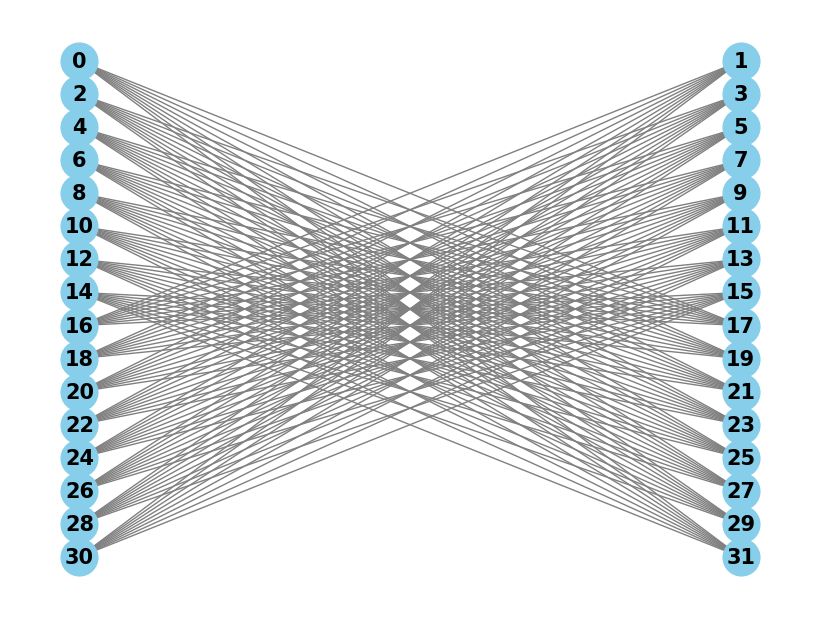

None


Matchings: 16
Matchings: [{('00111', '10111'), ('11010', '01010'), ('00001', '10001'), ('01111', '11111'), ('11110', '01110'), ('11011', '01011'), ('00101', '10101'), ('10010', '00010'), ('01101', '11101'), ('00011', '10011'), ('00110', '10110'), ('10000', '00000'), ('01100', '11100'), ('11001', '01001'), ('11000', '01000'), ('10100', '00100')}, {('00111', '10110'), ('10010', '00011'), ('10111', '00110'), ('01110', '11111'), ('00010', '10011'), ('01100', '11101'), ('11011', '01010'), ('11010', '01011'), ('10100', '00101'), ('00001', '10000'), ('11000', '01001'), ('11110', '01111'), ('01101', '11100'), ('11001', '01000'), ('00000', '10001'), ('00100', '10101')}, {('00011', '10001'), ('11000', '01010'), ('11001', '01011'), ('00111', '10101'), ('00010', '10000'), ('01101', '11111'), ('11011', '01001'), ('01111', '11101'), ('10010', '00000'), ('01110', '11100'), ('00001', '10011'), ('11010', '01000'), ('10110', '00100'), ('10100', '00110'), ('10111', '00101'), ('01100', '11110')}, {('0011

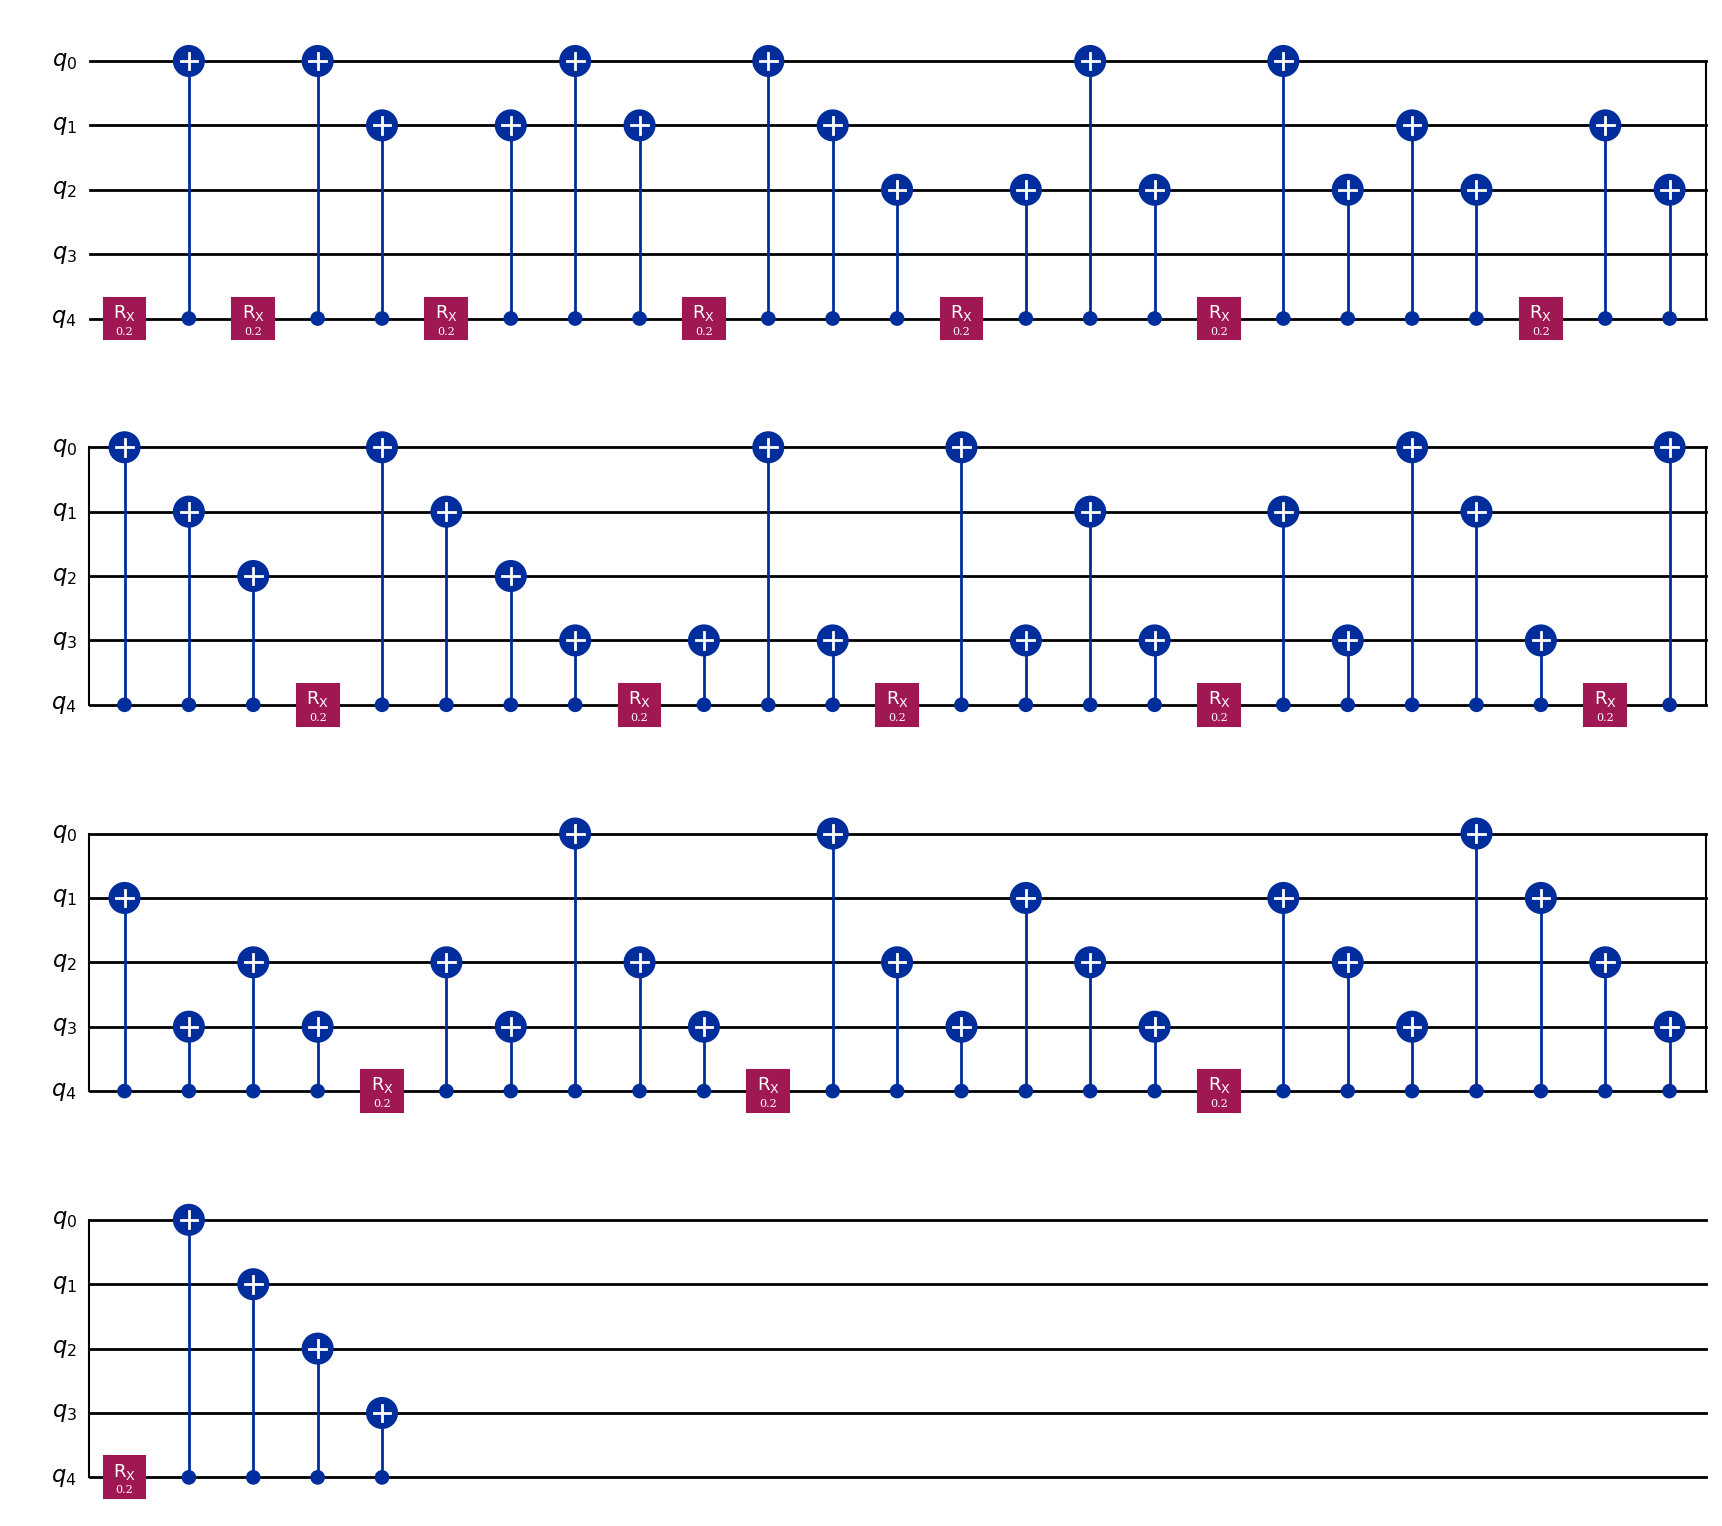


Gate Count Summary (U3/CX) for Bipartite K16,16:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          16/64       16/30         110/64       43/30
       2         32/128       32/60        220/128       77/60
       5         80/320      80/150        550/320     188/150
      10        160/640     160/300       1100/640     373/300
      20       320/1280     320/600      2200/1280     743/600
      50       800/3200    800/1500      5500/3200   1856/1500
     100      1600/6400   1600/3000     11000/6400   3706/3000

Hamming cost/edge: 3.000
Error plot saved as: trotterization_plots/bipartite_k16,16_error_analysis.pdf


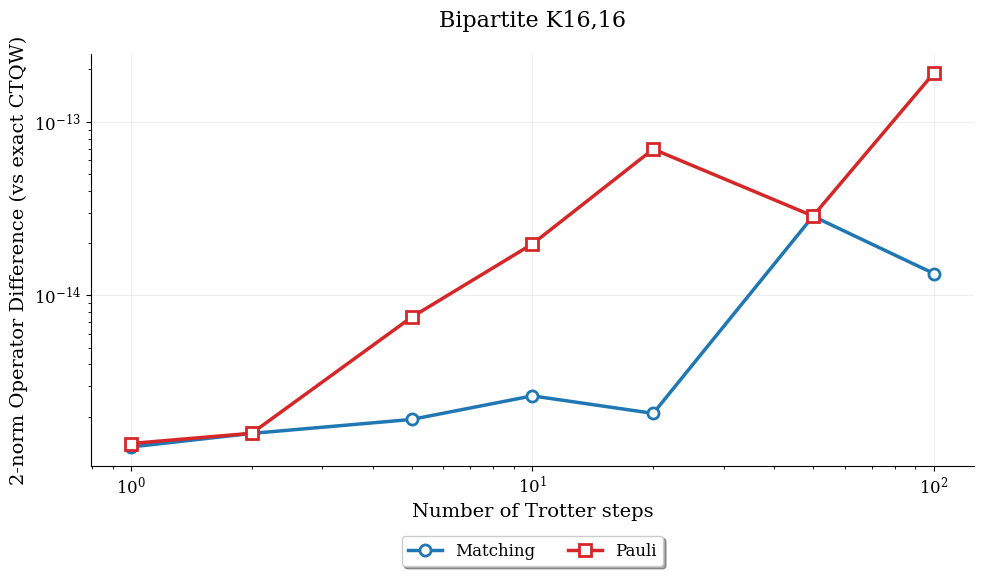

In [27]:
# 5 qubits: Complete bipartite K16,16
bipartite_edges = set()
# Connect all nodes with MSB=0 to all nodes with MSB=1
for i in range(16):
    node_i = format(i, '05b')  # MSB=0
    for j in range(16, 32):
        node_j = format(j, '05b')  # MSB=1
        bipartite_edges.add((node_i, node_j))

analyze_and_plot(bipartite_edges, "Bipartite K16,16")


Peterson Graph
Original edges: {('100', '001'), ('000', '001'), ('010', '111'), ('011', '100'), ('001', '010'), ('101', '111'), ('010', '011'), ('100', '000'), ('000', '101'), ('011', '000'), ('110', '000'), ('111', '001'), ('001', '110')}
Number of qubits: 3

Graph:


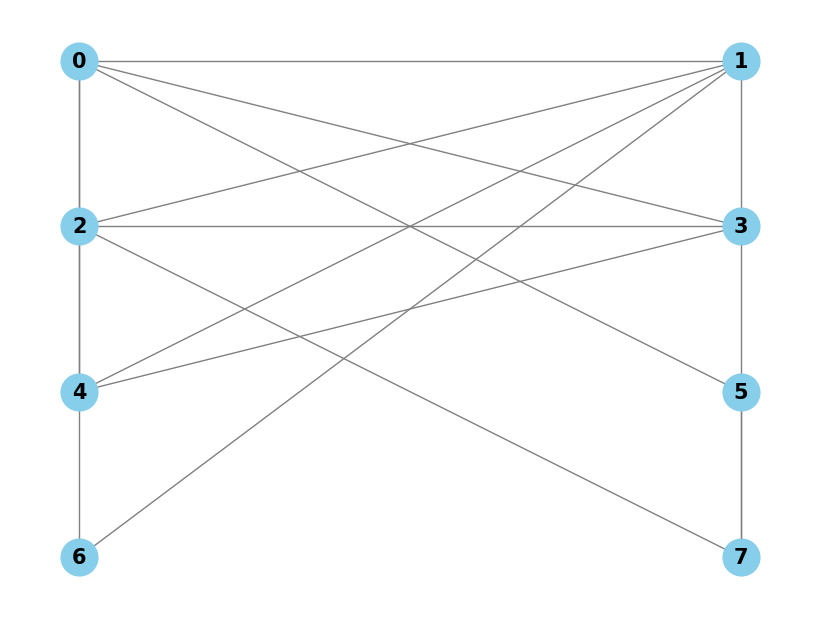

None


Matchings: 7
Matchings: [{('000', '101'), ('100', '001'), ('010', '111')}, {('110', '000'), ('011', '100'), ('001', '010')}, {('011', '000'), ('111', '001')}, {('001', '110')}, {('000', '001'), ('010', '011')}, {('101', '111')}, {('100', '000')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 24, Edges = 13, Per Edge = 1.846

Sample Circuit - Matching (n_steps=1):


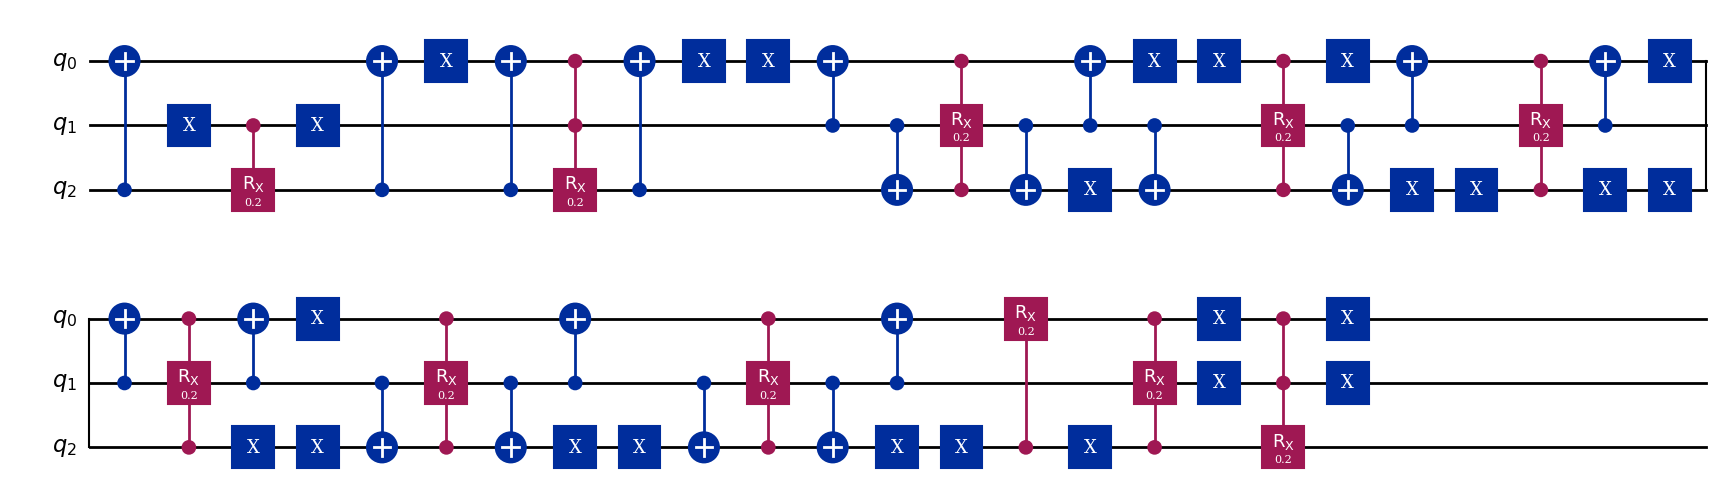


Gate Count Summary (U3/CX) for Peterson Graph:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         167/96       89/80          78/48       44/26
       2        334/192     179/159         156/96       86/52
       5        835/480     446/396        390/240     207/130
      10       1670/960     891/791        780/480     422/260
      20      3340/1920   1781/1581       1560/960     822/520
      50      8350/4800   4451/3951      3900/2400   2102/1300
     100     16700/9600   8901/7901      7800/4800   4102/2600

Hamming cost/edge: 1.846
Error plot saved as: trotterization_plots/peterson_graph_error_analysis.pdf


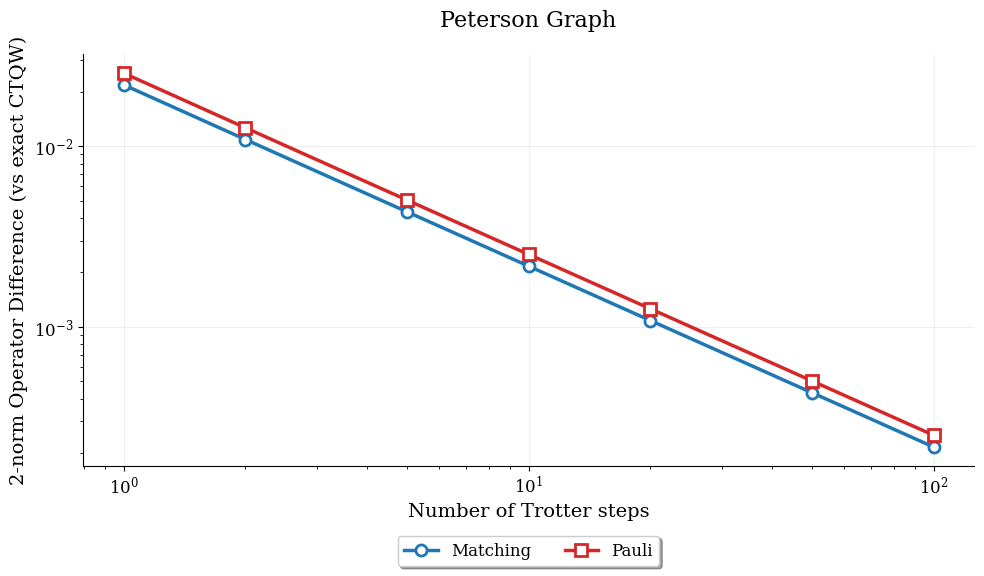

In [28]:
# Peterson graph (needs 10 nodes, we'll use first 10 of 3-qubit space)
# Outer pentagon: 0-1-2-3-4-0
# Inner pentagram: 5-7-9-6-8-5
# Connections: 0-5, 1-6, 2-7, 3-8, 4-9
peterson_edges = {
    # Outer pentagon (using 3-bit labels)
    ('000', '001'), ('001', '010'), ('010', '011'), ('011', '100'), ('100', '000'),
    # Inner pentagram
    ('101', '111'), ('111', '001'), ('001', '110'), ('110', '000'), ('000', '101'),
    # Spoke connections
    ('000', '101'), ('001', '110'), ('010', '111'), ('011', '000'), ('100', '001')
}

analyze_and_plot(peterson_edges, "Peterson Graph")